# 🏦 Prop Trading Interview Masterclass
## Complete Interview Preparation Guide — Institutional Grade

---

### 📋 Candidate Levels Covered
| Level | Focus |
|-------|-------|
| Graduate | Probability, Stats, Mental Math |
| Junior Trader | Options, Futures, Risk |
| Quant Trader | Derivatives, StatArb, Coding |
| Quant Researcher | ML, Time Series, Research |
| Trading Analyst | Micro-structure, Equities |
| Market Risk Analyst | VaR, Stress Testing |
| Electronic Trading | Microstructure, Order Books |
| Systematic Trading | Strategy Design, Backtesting |

---

## 📑 Table of Contents
1. [Mental Math & Trader Arithmetic](#section1)
2. [Probability & Statistics](#section2)
3. [Statistical Arbitrage](#section3)
4. [Fixed Income & Interest Rates](#section4)
5. [Forwards & Futures](#section5)
6. [Options Trading](#section6)
7. [Derivatives & Structured Products](#section7)
8. [Market Microstructure](#section8)
9. [Equities](#section9)
10. [Risk Management](#section10)
11. [Trading Strategy Design](#section11)
12. [Quantitative Brainteasers](#section12)
13. [Coding for Quant/Trading Interviews](#section13)
14. [Full Mock Interview](#section14)
15. [Master Formula Sheet](#section15)

---
> **How to use this notebook:** Work through each section sequentially. Every question is structured with *What is being tested*, *Common mistakes*, *Interview-quality answer*, and *Exceptional answer*. Code cells are runnable examples.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.optimize import brentq
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Libraries loaded successfully")
print("📊 Notebook ready for trading interview preparation")


✅ Libraries loaded successfully
📊 Notebook ready for trading interview preparation


---
<a id='section1'></a>
# Section 1: Mental Math & Trader Arithmetic 🧮

> **Why this matters:** Traders must compute quickly under pressure. Every trading floor interview includes mental math. Speed and accuracy signal competence.

---
## 1.1 Percentage Changes


### Q1 [Easy] — Basic Percentage Change
**Interviewer asks:** *"A stock moves from \$48 to \$54. What is the percentage change?"*

---
**What is being tested:** Basic arithmetic speed, ability to work under pressure.

**Common mistakes:** Using the wrong base (dividing by new price instead of old).

**Formula:** $\text{\% Change} = \frac{P_{new} - P_{old}}{P_{old}} \times 100$

**Mental shortcut:** $54 - 48 = 6$. Then $6/48 = 1/8 = 12.5\%$

**Interview answer:** "The stock gained \$6 on a base of \$48. $6/48 = 12.5\%$."

**Exceptional answer:** "12.5% — and note that a reversal from \$54 back to \$48 would be an 11.1% decline, illustrating asymmetry in percentage changes."


In [32]:
# Q1: Percentage Change
old, new = 48, 54
pct_change = (new - old) / old * 100
print(f"Price change: ${new - old}")
print(f"Percentage change: {pct_change:.2f}%")
print(f"Mental shortcut: 6/48 = 1/8 = {1/8*100:.2f}%")

# Asymmetry demonstration
reverse_pct = (old - new) / new * 100
print(f"\nAsymmetry: reversal back = {reverse_pct:.2f}% (not -12.5%!)")


Price change: $6
Percentage change: 12.50%
Mental shortcut: 6/48 = 1/8 = 12.50%

Asymmetry: reversal back = -11.11% (not -12.5%!)


### Q2 [Easy] — Sequential Percentage Changes
**Interviewer asks:** *"A stock rises 20% then falls 20%. Where does it end up?"*

---
**What is being tested:** Understanding of multiplicative (not additive) compounding.

**Common mistake:** Saying "back to the same price." This is wrong!

**Formula:** $P_{final} = P_0 \times 1.20 \times 0.80 = 0.96 \times P_0$

**Mental shortcut:** $1.2 \times 0.8 = (1 + 0.2)(1 - 0.2) = 1 - 0.04 = 0.96$

**Interview answer:** "It's down 4%, not flat. A 20% gain followed by a 20% loss always results in a net loss because the base for the decline is larger."

**Exceptional answer:** "Net result is -4% due to multiplicative compounding. This is why arithmetic mean overstates compound returns — the geometric mean of +20%/-20% is $\sqrt{1.2 \times 0.8} - 1 = -2\%$ per period."


Start: $100
After +20%: $120.00
After -20%: $96.00
Net change: -4.00%


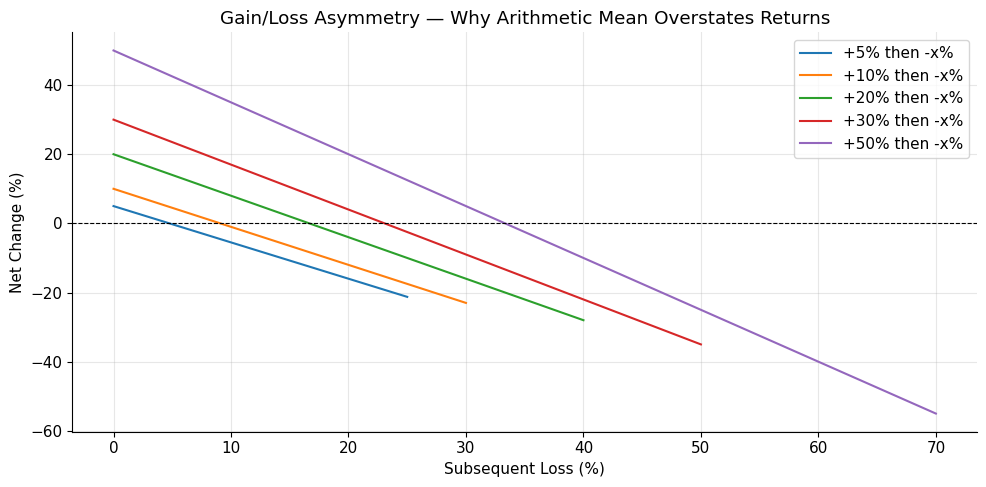

In [33]:
# Q2: Sequential Percentage Changes
P0 = 100
after_up = P0 * 1.20
after_down = after_up * 0.80
print(f"Start: ${P0}")
print(f"After +20%: ${after_up:.2f}")
print(f"After -20%: ${after_down:.2f}")
print(f"Net change: {(after_down/P0 - 1)*100:.2f}%")

# Visualize various gain/loss combinations
gains = [5, 10, 20, 30, 50]
fig, ax = plt.subplots(figsize=(10,5))
for g in gains:
    losses = np.linspace(0, g + 20, 100)
    net = (1 + g/100) * (1 - losses/100) - 1
    ax.plot(losses, net * 100, label=f'+{g}% then -x%')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Subsequent Loss (%)')
ax.set_ylabel('Net Change (%)')
ax.set_title('Gain/Loss Asymmetry — Why Arithmetic Mean Overstates Returns')
ax.legend()
plt.tight_layout()
plt.show()


### Q3 [Medium] — Compounding Returns
**Interviewer asks:** *"If you make 1% per day for 252 trading days, what is your annual return?"*

---
**What is being tested:** Compounding intuition, logarithm approximations.

**Formula:** $R_{annual} = (1.01)^{252} - 1$

**Mental shortcut:** Use $\ln(1+r) \approx r$ for small $r$. So $\ln(1.01^{252}) \approx 252 \times 0.01 = 2.52$, giving $e^{2.52} \approx 12.4$, so ~1140%.

**Interview answer:** "$(1.01)^{252} \approx e^{2.52} \approx 12.4$, so roughly 1140% annual return."

**Exceptional answer:** "About 1140% — though this illustrates why 1%/day is unrealistically high. At 252 Sharpe, even the best quant funds don't approach this. Real compounding edge comes from risk-adjusted consistency."


Annual return at 1%/day: 1127.4%
Log approximation: e^(252*0.01) = e^2.52 = 12.43x


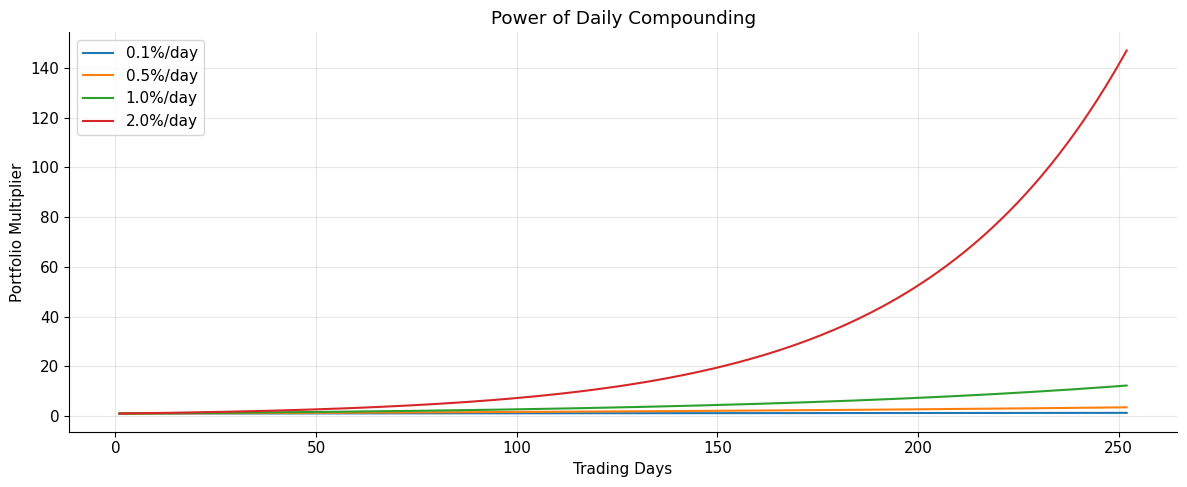

In [34]:
# Q3: Daily Compounding
daily_return = 0.01
trading_days = 252
annual_return = (1 + daily_return)**trading_days - 1
print(f"Annual return at 1%/day: {annual_return*100:.1f}%")
print(f"Log approximation: e^(252*0.01) = e^2.52 = {np.exp(2.52):.2f}x")

# Plot compounding curves
days = np.arange(1, 253)
daily_rates = [0.001, 0.005, 0.01, 0.02]
fig, ax = plt.subplots()
for r in daily_rates:
    growth = (1+r)**days
    ax.plot(days, growth, label=f'{r*100:.1f}%/day')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Portfolio Multiplier')
ax.set_title('Power of Daily Compounding')
ax.legend()
plt.tight_layout()
plt.show()


### Q4–Q10: Expected Value Questions

### Q4 [Easy] — Coin Flip Game
**Interviewer asks:** *"I flip a fair coin. Heads you win \$3, tails you lose \$1. Should you play? How much would you pay to play?"*

**EV formula:** $EV = \sum p_i \times x_i = 0.5 \times 3 + 0.5 \times (-1) = \$1$

**Answer:** "Expected value is +\$1, so yes. Maximum fair price to pay is \$1."

**Exceptional:** "EV = \$1. But I'd also consider variance — this bet has std dev $\sqrt{0.5(3-1)^2 + 0.5(-1-1)^2} = 2$. Kelly fraction = edge/odds = (EV)/variance * ... worth deeper sizing discussion."

### Q5 [Medium] — Loaded Dice
**Interviewer asks:** *"A die shows 1-5 each with probability 1/8 and 6 with probability 3/8. What's the expected value of one roll?"*

$EV = (1+2+3+4+5) \times \frac{1}{8} + 6 \times \frac{3}{8} = \frac{15}{8} + \frac{18}{8} = \frac{33}{8} = 4.125$

### Q6 [Medium] — Kelly Criterion
**Interviewer asks:** *"You have a 60% chance of winning 1:1. How much of your bankroll should you bet?"*

$f^* = \frac{bp - q}{b} = \frac{1 \times 0.6 - 0.4}{1} = 0.20 = 20\%$

### Q7 [Hard] — Two Envelope Problem
**Interviewer asks:** *"Two envelopes, one has twice the other. You open one and see \$100. Switch or stay?"*

**Answer:** This is the famous two-envelope paradox. With no prior on the distribution, the symmetry argument fails — you should be indifferent after opening.


=== Q4: Coin Flip ===
EV = 1.0, Std Dev = 2.00

=== Q5: Loaded Die ===
EV = 4.1250

=== Q6: Kelly Criterion ===
Kelly fraction = 20.00%


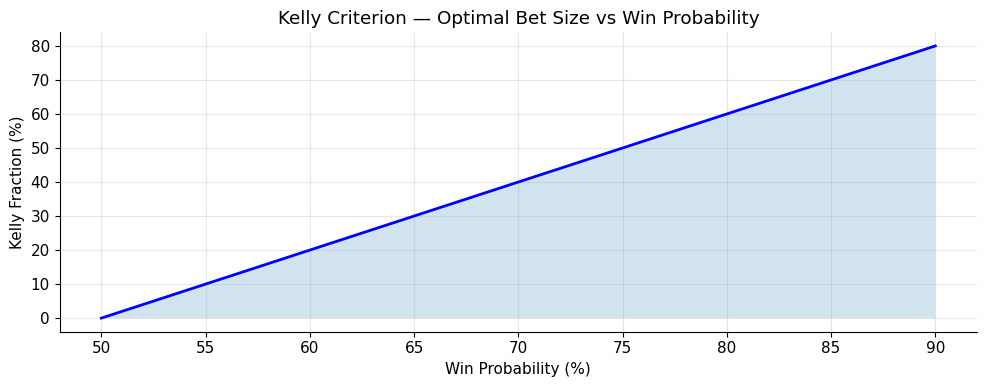

In [35]:
# Q4-Q7: Expected Value Calculations
print("=== Q4: Coin Flip ===")
ev_coin = 0.5 * 3 + 0.5 * (-1)
var_coin = 0.5*(3 - ev_coin)**2 + 0.5*(-1 - ev_coin)**2
print(f"EV = {ev_coin}, Std Dev = {var_coin**0.5:.2f}")

print("\n=== Q5: Loaded Die ===")
ev_die = sum(i * (1/8) for i in range(1,6)) + 6 * (3/8)
print(f"EV = {ev_die:.4f}")

print("\n=== Q6: Kelly Criterion ===")
p, q, b = 0.6, 0.4, 1.0
kelly = (b*p - q) / b
print(f"Kelly fraction = {kelly:.2%}")

# Kelly fraction sensitivity
probs = np.linspace(0.5, 0.9, 100)
kellys = (probs - (1-probs)) / 1.0
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(probs*100, kellys*100, 'b-', linewidth=2)
ax.fill_between(probs*100, kellys*100, alpha=0.2)
ax.set_xlabel('Win Probability (%)')
ax.set_ylabel('Kelly Fraction (%)')
ax.set_title('Kelly Criterion — Optimal Bet Size vs Win Probability')
plt.tight_layout()
plt.show()


### Q8–Q15: Probability Foundations

### Q8 [Easy] — Basic Probability
**Interviewer asks:** *"What is the probability of rolling at least one 6 in two dice rolls?"*

$P(\text{at least one 6}) = 1 - P(\text{no 6})^2 = 1 - (5/6)^2 = 1 - 25/36 = 11/36 \approx 30.6\%$

**Mental shortcut:** $1 - (5/6)^2 \approx 1 - 0.694 = 0.306$

### Q9 [Medium] — Bayes' Theorem
**Interviewer asks:** *"A test for a rare disease (1% prevalence) is 99% accurate. You test positive. What's the probability you have the disease?"*

$P(D|+) = \frac{P(+|D)P(D)}{P(+)} = \frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.01 \times 0.99} = \frac{0.0099}{0.0198} = 50\%$

**Trading application:** Bayesian updating of signal confidence — a strategy with 60% hit rate might still be worthless if signal-to-noise is poor.

### Q10–Q15: Log Approximations for Traders

**Key formulas:**
- $\ln(1+x) \approx x$ for small $x$
- $\ln(2) \approx 0.693$ (doubling time)
- Rule of 72: years to double ≈ $72/r\%$
- $e \approx 2.718$
- $\ln(0.9) \approx -0.105$, $\ln(1.1) \approx 0.095$


In [36]:
# Q8-Q10: Probability & Bayes
print("=== Q8: Dice Probability ===")
p_at_least_one_6 = 1 - (5/6)**2
print(f"P(at least one 6 in 2 rolls) = {p_at_least_one_6:.4f} = {p_at_least_one_6*36:.0f}/36")

print("\n=== Q9: Bayes Theorem ===")
prev = 0.01       # 1% disease prevalence
sensitivity = 0.99  # P(+|disease)
false_pos = 0.01   # P(+|no disease)
p_pos = sensitivity*prev + false_pos*(1-prev)
p_disease_given_pos = (sensitivity * prev) / p_pos
print(f"P(disease | positive test) = {p_disease_given_pos:.1%}")
print("Counterintuitive: only 50% despite 99% accurate test!")

print("\n=== Log Approximation Table ===")
values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
print(f"{'x':>8} {'ln(1+x)':>12} {'Approx x':>12} {'Error%':>10}")
for x in values:
    exact = np.log(1+x)
    print(f"{x:>8.2f} {exact:>12.4f} {x:>12.4f} {(x-exact)/exact*100:>9.1f}%")


=== Q8: Dice Probability ===
P(at least one 6 in 2 rolls) = 0.3056 = 11/36

=== Q9: Bayes Theorem ===
P(disease | positive test) = 50.0%
Counterintuitive: only 50% despite 99% accurate test!

=== Log Approximation Table ===
       x      ln(1+x)     Approx x     Error%
    0.01       0.0100       0.0100       0.5%
    0.05       0.0488       0.0500       2.5%
    0.10       0.0953       0.1000       4.9%
    0.20       0.1823       0.2000       9.7%
    0.50       0.4055       0.5000      23.3%
    1.00       0.6931       1.0000      44.3%
    2.00       1.0986       2.0000      82.0%


### Q16–Q25: Volatility & Sharpe Approximations

### Q16 [Medium] — Volatility Scaling
**Interviewer asks:** *"A stock has daily volatility of 1%. What is the annual volatility?"*

$\sigma_{annual} = \sigma_{daily} \times \sqrt{252} \approx 1\% \times 15.87 \approx 16\%$

**Mental shortcut:** $\sqrt{252} \approx \sqrt{256} = 16$

### Q17 [Medium] — Sharpe Ratio Estimation
**Interviewer asks:** *"A strategy returns 20% annually with 15% annualized vol. What is the Sharpe (rf=2%)?"*

$SR = \frac{R_p - R_f}{\sigma_p} = \frac{0.20 - 0.02}{0.15} = 1.2$

### Q18 [Hard] — Information Ratio from Win Rate
**Interviewer asks:** *"A trader wins 55% of trades. Each win is +\$1, each loss is -\$1. What is the Sharpe ratio of this strategy?"*

$\mu = 0.55 - 0.45 = 0.10$, $\sigma = \sqrt{0.55 \times 0.45 \times (1-(-1))^2} = \sqrt{4 \times 0.2475} = 0.995$

$SR_{per trade} = 0.10/0.995 \approx 0.10$. Annualized over $N$ trades: $SR_{annual} = 0.10 \times \sqrt{N}$


=== Q16: Volatility Scaling ===
Daily vol: 1.00%
Annual vol: 15.87%
Mental shortcut: sqrt(252) ≈ sqrt(256) = 16

=== Q17: Sharpe Ratio ===
Sharpe Ratio = 1.20

=== Q18: Sharpe from Win Rate ===
Edge per trade: 0.10
Std Dev per trade: 0.9950
SR per trade: 0.1005
SR annualized (252 trades/yr): 1.60


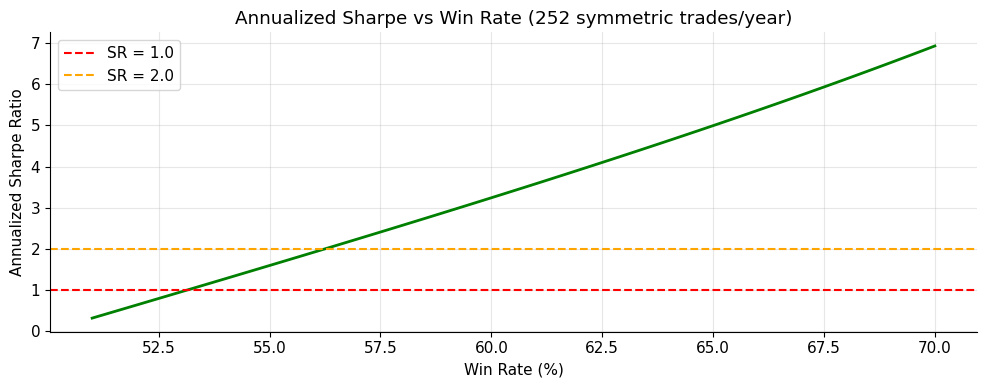

In [37]:
# Q16-Q18: Volatility and Sharpe
print("=== Q16: Volatility Scaling ===")
daily_vol = 0.01
annual_vol = daily_vol * np.sqrt(252)
print(f"Daily vol: {daily_vol*100:.2f}%")
print(f"Annual vol: {annual_vol*100:.2f}%")
print(f"Mental shortcut: sqrt(252) ≈ sqrt(256) = 16")

print("\n=== Q17: Sharpe Ratio ===")
ret, rf, vol = 0.20, 0.02, 0.15
sharpe = (ret - rf) / vol
print(f"Sharpe Ratio = {sharpe:.2f}")

print("\n=== Q18: Sharpe from Win Rate ===")
win_rate = 0.55
mu = win_rate - (1-win_rate)
sigma = np.sqrt(4 * win_rate * (1-win_rate))
sr_per_trade = mu / sigma
trades_per_year = 252
sr_annual = sr_per_trade * np.sqrt(trades_per_year)
print(f"Edge per trade: {mu:.2f}")
print(f"Std Dev per trade: {sigma:.4f}")
print(f"SR per trade: {sr_per_trade:.4f}")
print(f"SR annualized (252 trades/yr): {sr_annual:.2f}")

# Sharpe vs win rate chart
win_rates = np.linspace(0.51, 0.70, 100)
mus = 2*win_rates - 1
sigmas = np.sqrt(4*win_rates*(1-win_rates))
srs = mus/sigmas * np.sqrt(252)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(win_rates*100, srs, 'g-', linewidth=2)
ax.axhline(1.0, color='red', linestyle='--', label='SR = 1.0')
ax.axhline(2.0, color='orange', linestyle='--', label='SR = 2.0')
ax.set_xlabel('Win Rate (%)')
ax.set_ylabel('Annualized Sharpe Ratio')
ax.set_title('Annualized Sharpe vs Win Rate (252 symmetric trades/year)')
ax.legend()
plt.tight_layout()
plt.show()


### Q19–Q30: Advanced Mental Math

### Q19 — Weighted Average
*"You hold 3 positions: 40% in a stock up 10%, 35% in a stock down 5%, 25% in cash (0%). What is portfolio return?"*

$R_p = 0.4(10) + 0.35(-5) + 0.25(0) = 4 - 1.75 = 2.25\%$

### Q20 — Rule of 72
*"At 8% annual return, how many years to double?"*

Years $\approx 72/8 = 9$ years (exact: $\ln 2 / \ln 1.08 = 9.00$ years)

### Q21 — Present Value
*"\$1,000 in 5 years at 6% discount rate. What is PV?"*

$PV = 1000 / (1.06)^5 \approx 1000 / 1.338 \approx \$747$

**Mental shortcut:** $1.06^5 \approx 1 + 5(0.06) + 10(0.06)^2 = 1 + 0.30 + 0.036 = 1.336$

### Q22 — Implied Move from Options
*"A stock is at \$100 and 1-month straddle costs \$5. What implied move does that represent?"*

Implied daily move $\approx \frac{\text{straddle price}}{\text{spot} \times \sqrt{T \times 252}} \approx$ implied vol. 

For ATM straddle: price $\approx 0.8 \times S \times \sigma \times \sqrt{T}$

$5 = 0.8 \times 100 \times \sigma \times \sqrt{1/12}$, so $\sigma \approx 5/(80 \times 0.289) \approx 21.6\%$

### Q23-Q30 Summary Table
| Question | Type | Answer |
|----------|------|--------|
| What is 17 × 18? | Arithmetic | 306 (use 17×20-17×2) |
| $\sqrt{17}$? | Approximation | ≈4.12 (between 4 and 4.25) |
| $e^{0.5}$? | Log | ≈1.649 |
| $\ln(50)$? | Log | ≈3.912 |
| 1/7 as decimal? | Fraction | 0.1428... |
| 1/12 as decimal? | Fraction | 0.0833 |
| $(1.05)^{10}$? | Compound | ≈1.629 |
| $\sqrt{0.06/252}$? | Vol scaling | ≈0.0154 (daily vol) |


In [38]:
# Q19-Q23: Mental Math Demonstrations
print("=== Q19: Weighted Average Portfolio Return ===")
weights = [0.40, 0.35, 0.25]
returns = [10, -5, 0]
port_ret = sum(w*r for w,r in zip(weights, returns))
print(f"Portfolio return: {port_ret:.2f}%")

print("\n=== Q20: Rule of 72 ===")
for rate in [4, 6, 8, 10, 12]:
    exact = np.log(2) / np.log(1 + rate/100)
    approx = 72 / rate
    print(f"Rate {rate:2d}%: exact={exact:.2f}yr, Rule of 72={approx:.2f}yr")

print("\n=== Q21: Present Value ===")
fv, r, n = 1000, 0.06, 5
pv = fv / (1+r)**n
print(f"PV of ${fv} in {n} years at {r:.0%} = ${pv:.2f}")

print("\n=== Q22: Implied Vol from Straddle Price ===")
S, straddle_price, T_months = 100, 5, 1
T = T_months / 12
# ATM straddle ≈ 2*C ≈ 0.8*S*sigma*sqrt(T) (simplified)
impl_vol = straddle_price / (0.8 * S * np.sqrt(T))
print(f"Implied vol from ${straddle_price} straddle: {impl_vol:.1%}")


=== Q19: Weighted Average Portfolio Return ===
Portfolio return: 2.25%

=== Q20: Rule of 72 ===
Rate  4%: exact=17.67yr, Rule of 72=18.00yr
Rate  6%: exact=11.90yr, Rule of 72=12.00yr
Rate  8%: exact=9.01yr, Rule of 72=9.00yr
Rate 10%: exact=7.27yr, Rule of 72=7.20yr
Rate 12%: exact=6.12yr, Rule of 72=6.00yr

=== Q21: Present Value ===
PV of $1000 in 5 years at 6% = $747.26

=== Q22: Implied Vol from Straddle Price ===
Implied vol from $5 straddle: 21.7%


---
<a id='section2'></a>
# Section 2: Probability & Statistics 📊

> **Why this matters:** Probability is the language of trading. Every trade is a bet; every position has a distribution of outcomes. Mastery here separates systematic thinkers from gamblers.

---
## 2.1 Basic Probability


### Q1 [Easy] — Birthday Problem
**Interviewer asks:** *"How many people do you need in a room for there to be a >50% chance that two share a birthday?"*

**Intuition:** Far fewer than you think — only 23!

**Formula:**
$P(\text{at least one match}) = 1 - \frac{365!/(365-n)!}{365^n}$

**Trading application:** Coincidence vs. causation in backtests — spurious correlations rise rapidly with the number of assets.

### Q2 [Easy] — Card Probability
**Interviewer asks:** *"You draw 2 cards from a standard deck. What is the probability both are Aces?"*

$P = \frac{4}{52} \times \frac{3}{51} = \frac{12}{2652} = \frac{1}{221} \approx 0.45\%$

### Q3 [Medium] — Conditional Probability
**Interviewer asks:** *"You roll two dice. Given the sum is at least 10, what's the probability it's exactly 10?"*

Sample space sum≥10: {(4,6),(5,5),(6,4),(5,6),(6,5),(6,6)} = 6 outcomes  
Sum=10: {(4,6),(5,5),(6,4)} = 3 outcomes  
$P(10 | \geq 10) = 3/6 = 1/2$


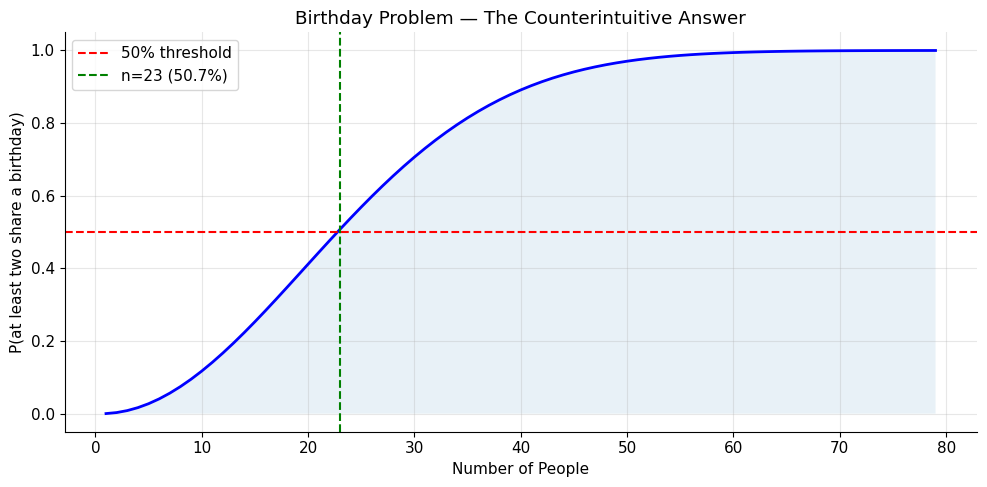

First n where P > 50%: n = 23, P = 50.73%

P(two aces) = 0.4525% ≈ 1/221


In [39]:
# Birthday Problem Simulation
def birthday_probability(n):
    p_no_match = 1.0
    for i in range(n):
        p_no_match *= (365 - i) / 365
    return 1 - p_no_match

ns = range(1, 80)
probs = [birthday_probability(n) for n in ns]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ns, probs, 'b-', linewidth=2)
ax.axhline(0.5, color='red', linestyle='--', label='50% threshold')
ax.axvline(23, color='green', linestyle='--', label='n=23 (50.7%)')
ax.fill_between(ns, probs, alpha=0.1)
ax.set_xlabel('Number of People')
ax.set_ylabel('P(at least two share a birthday)')
ax.set_title('Birthday Problem — The Counterintuitive Answer')
ax.legend()
plt.tight_layout()
plt.show()

n_50 = next(n for n, p in zip(ns, probs) if p >= 0.5)
print(f"First n where P > 50%: n = {n_50}, P = {birthday_probability(n_50):.2%}")

# Q2: Card probability
p_two_aces = (4/52) * (3/51)
print(f"\nP(two aces) = {p_two_aces:.4%} ≈ 1/221")


## 2.2 Distributions

### Q4 [Medium] — Binomial Distribution
**Interviewer asks:** *"A trader makes 10 independent trades, each with a 60% win rate. What is the probability of winning at least 7?"*

$P(X \geq 7) = \sum_{k=7}^{10} \binom{10}{k} (0.6)^k (0.4)^{10-k}$

**Trading application:** Assessing whether a track record is statistically significant.

### Q5 [Medium] — Poisson Distribution
**Interviewer asks:** *"On average, 3 large trades arrive per minute. What is the probability of exactly 5 in a given minute?"*

$P(X=5) = \frac{e^{-3} \cdot 3^5}{5!} = \frac{0.0498 \times 243}{120} = 0.1008 \approx 10.1\%$

**Trading application:** Modeling order arrival, jump processes, trade counts.

### Q6 [Hard] — Normal Distribution
**Interviewer asks:** *"A stock has daily return μ=0%, σ=1%. What is the probability of a -3% or worse day?"*

$P(X \leq -3\%) = P\left(Z \leq \frac{-3-0}{1}\right) = P(Z \leq -3) = \Phi(-3) \approx 0.135\%$

**Key memory points:** 68-95-99.7 rule (1σ, 2σ, 3σ)


=== Q4: Binomial ===
P(winning ≥7 of 10 trades at 60%): 38.23%

=== Q5: Poisson ===
P(exactly 5 large trades | λ=3): 0.1008

=== Q6: Normal ===
P(return ≤ -3%) = 0.1350%


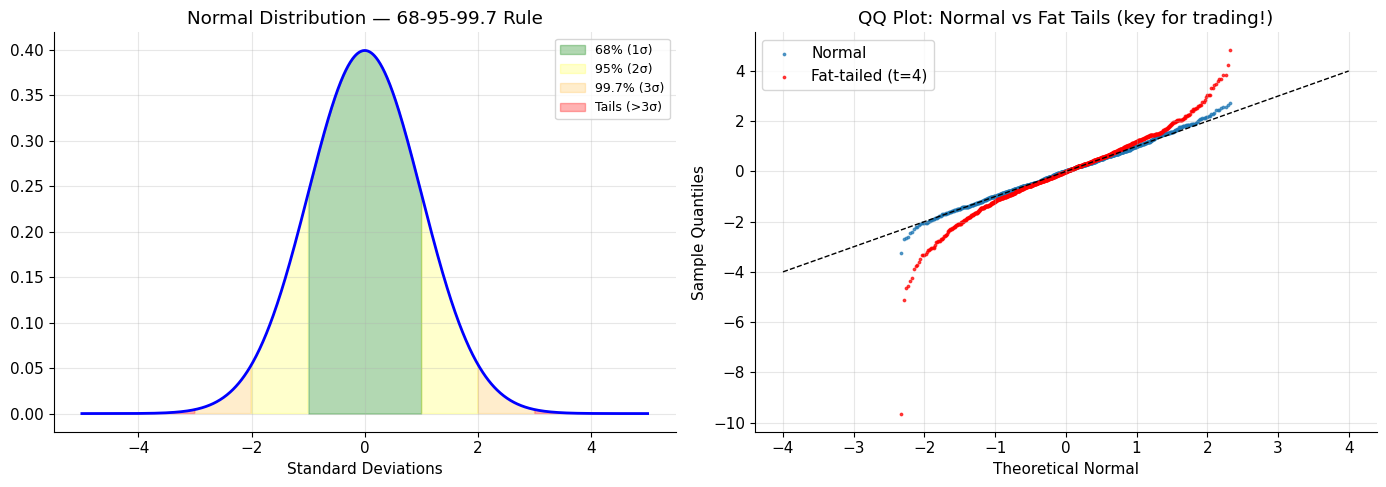

In [40]:
from scipy.stats import binom, poisson, norm

# Q4: Binomial - Win Rate
n_trades, win_prob = 10, 0.6
p_7_or_more = 1 - binom.cdf(6, n_trades, win_prob)
print(f"=== Q4: Binomial ===")
print(f"P(winning ≥7 of 10 trades at 60%): {p_7_or_more:.2%}")

# Q5: Poisson
lam = 3
p_exactly_5 = poisson.pmf(5, lam)
print(f"\n=== Q5: Poisson ===")
print(f"P(exactly 5 large trades | λ=3): {p_exactly_5:.4f}")

# Q6: Normal Distribution
mu, sigma = 0, 1  # daily returns in %
p_minus_3 = norm.cdf(-3, mu, sigma)
print(f"\n=== Q6: Normal ===")
print(f"P(return ≤ -3%) = {p_minus_3:.4%}")

# Normal distribution visualization
x = np.linspace(-5, 5, 1000)
y = norm.pdf(x)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x, y, 'b-', linewidth=2)
ax.fill_between(x, y, where=(x >= -1) & (x <= 1), alpha=0.3, color='green', label='68% (1σ)')
ax.fill_between(x, y, where=((x >= -2) & (x < -1)) | ((x > 1) & (x <= 2)), alpha=0.2, color='yellow', label='95% (2σ)')
ax.fill_between(x, y, where=((x >= -3) & (x < -2)) | ((x > 2) & (x <= 3)), alpha=0.2, color='orange', label='99.7% (3σ)')
ax.fill_between(x, y, where=(x < -3) | (x > 3), alpha=0.3, color='red', label='Tails (>3σ)')
ax.set_title('Normal Distribution — 68-95-99.7 Rule')
ax.set_xlabel('Standard Deviations')
ax.legend(fontsize=9)

# Q-Q plot concept for fat tails
ax2 = axes[1]
np.random.seed(42)
normal_sim = np.random.normal(0, 1, 1000)
t_sim = np.random.standard_t(4, 1000)  # fat-tailed
theoretical = np.sort(norm.ppf(np.linspace(0.01, 0.99, 998)))
ax2.scatter(theoretical, np.sort(normal_sim)[:998], s=3, label='Normal', alpha=0.7)
ax2.scatter(theoretical, np.sort(t_sim)[:998], s=3, label='Fat-tailed (t=4)', alpha=0.7, color='red')
ax2.plot([-4,4], [-4,4], 'k--', linewidth=1)
ax2.set_title('QQ Plot: Normal vs Fat Tails (key for trading!)')
ax2.set_xlabel('Theoretical Normal')
ax2.set_ylabel('Sample Quantiles')
ax2.legend()
plt.tight_layout()
plt.show()


## 2.3 Statistical Concepts

### Q7 [Medium] — Covariance and Correlation
**Interviewer asks:** *"What is the difference between covariance and correlation? Why does this matter in portfolio construction?"*

---
**Covariance:** $\text{Cov}(X,Y) = E[(X-\mu_X)(Y-\mu_Y)]$

**Correlation:** $\rho = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}$ — dimensionless, bounded $[-1, 1]$

**Why it matters:** Portfolio variance depends on correlations, not just covariances:

$$\sigma_p^2 = w_1^2\sigma_1^2 + w_2^2\sigma_2^2 + 2w_1w_2\rho_{12}\sigma_1\sigma_2$$

**Interview answer:** "Covariance is scale-dependent — it changes if you measure a stock in dollars vs cents. Correlation normalizes this, making it comparable across different securities. In portfolio construction, low-correlation assets provide diversification benefits even with similar individual volatilities."

### Q8 [Hard] — Variance of a Sum
**Interviewer asks:** *"Two assets each have 20% volatility and are 30% correlated. Equal weight portfolio vol?"*

$\sigma_p^2 = (0.5)^2(0.2)^2 + (0.5)^2(0.2)^2 + 2(0.5)(0.5)(0.3)(0.2)(0.2)$

$= 0.01 + 0.01 + 0.006 = 0.026$

$\sigma_p = \sqrt{0.026} = 16.1\%$ (vs 20% individual)

**Key insight:** Diversification benefit = $20\% - 16.1\% = 3.9\%$ vol reduction


=== Q7: Covariance & Correlation ===
Cov(r1, r2) = 0.0096
Corr(r1, r2) = 0.2501

=== Q8: Portfolio Variance ===
Individual vol: 20%
Portfolio vol: 16.1%
Diversification benefit: 19.4% reduction


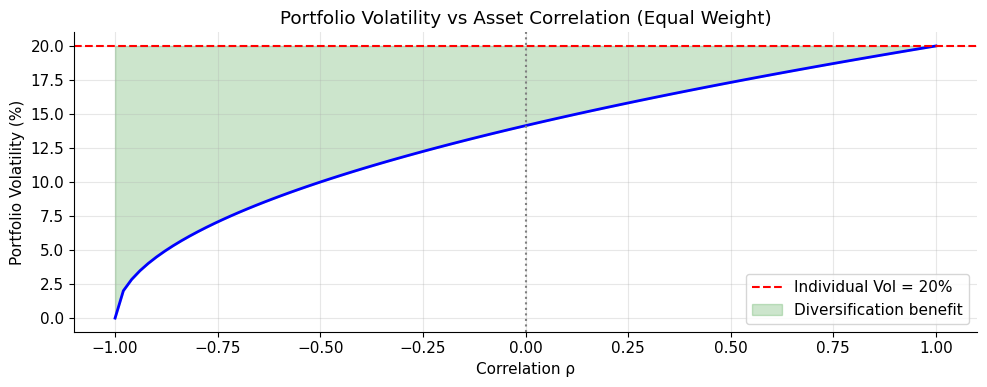

In [41]:
# Q7-Q8: Covariance, Correlation, Portfolio Variance
np.random.seed(42)

# Simulate two correlated assets
n = 1000
cov_matrix = np.array([[0.04, 0.012], [0.012, 0.04]])  # 20% vol, 30% corr
returns = np.random.multivariate_normal([0, 0], cov_matrix, n)

r1, r2 = returns[:,0], returns[:,1]
print("=== Q7: Covariance & Correlation ===")
print(f"Cov(r1, r2) = {np.cov(r1, r2)[0,1]:.4f}")
print(f"Corr(r1, r2) = {np.corrcoef(r1, r2)[0,1]:.4f}")

print("\n=== Q8: Portfolio Variance ===")
w = 0.5
s1, s2, rho = 0.20, 0.20, 0.30
port_var = w**2*s1**2 + w**2*s2**2 + 2*w*w*rho*s1*s2
port_vol = np.sqrt(port_var)
print(f"Individual vol: {s1:.0%}")
print(f"Portfolio vol: {port_vol:.1%}")
print(f"Diversification benefit: {(s1-port_vol)/s1*100:.1f}% reduction")

# Diversification benefit vs correlation
corrs = np.linspace(-1, 1, 100)
port_vols = np.sqrt(0.5*(s1**2 + s2**2) + corrs*s1*s2) * np.ones(100)
# Correct formula: sqrt(0.25*s1^2 + 0.25*s2^2 + 2*0.25*rho*s1*s2)
port_vols = np.sqrt(0.25*s1**2 + 0.25*s2**2 + 0.5*corrs*s1*s2)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(corrs, port_vols*100, 'b-', linewidth=2)
ax.axhline(s1*100, color='red', linestyle='--', label=f'Individual Vol = {s1*100:.0f}%')
ax.axvline(0, color='gray', linestyle=':')
ax.fill_between(corrs, port_vols*100, s1*100, alpha=0.2, color='green', label='Diversification benefit')
ax.set_xlabel('Correlation ρ')
ax.set_ylabel('Portfolio Volatility (%)')
ax.set_title('Portfolio Volatility vs Asset Correlation (Equal Weight)')
ax.legend()
plt.tight_layout()
plt.show()


## 2.4 Hypothesis Testing

### Q9 [Medium] — P-values
**Interviewer asks:** *"A strategy shows a Sharpe ratio of 1.5 over 3 years of monthly data. Is it statistically significant?"*

---
**Setup:** $T = 36$ monthly observations, $\hat{SR} = 1.5/\sqrt{12} = 0.433$ monthly

**Test statistic:** $t = \hat{SR} \times \sqrt{T} = 0.433 \times \sqrt{36} = 2.6$

**p-value:** $p = 2 \times (1 - \Phi(2.6)) \approx 0.9\%$

**Conclusion:** At 5% significance, this is statistically significant. But beware of **multiple testing bias** — if you tested 100 strategies, you'd expect 5 to pass by chance.

### Q10 [Hard] — Type I vs Type II Errors

| | H₀ True | H₀ False |
|---|---|---|
| **Reject H₀** | Type I Error (α) | Correct (Power) |
| **Fail to Reject** | Correct | Type II Error (β) |

**Trading application:** 
- Type I: Deploying a strategy that has no real edge (false positive → capital loss)
- Type II: Rejecting a valid strategy (false negative → missed opportunity)

**Key insight:** In quant trading with many strategies, multiple comparisons inflate Type I error rate dramatically → use Bonferroni correction or FDR control.

### Q11 [Hard] — Central Limit Theorem
**Interviewer asks:** *"Why does the CLT matter in trading?"*

**Answer:** The CLT states that for large $n$, $\bar{X} \sim N(\mu, \sigma^2/n)$ regardless of the underlying distribution.

**Trading applications:**
1. Portfolio returns approximate normality even with non-normal individual returns
2. Justifies using normal approximation for option Greeks
3. Explains why diversification works
4. PnL aggregation across many positions


=== Q9: Sharpe Significance ===
Annual SR: 1.5
Monthly SR: 0.4330
t-statistic: 2.60
p-value: 0.0094 (0.94%)
Significant at 5%: True


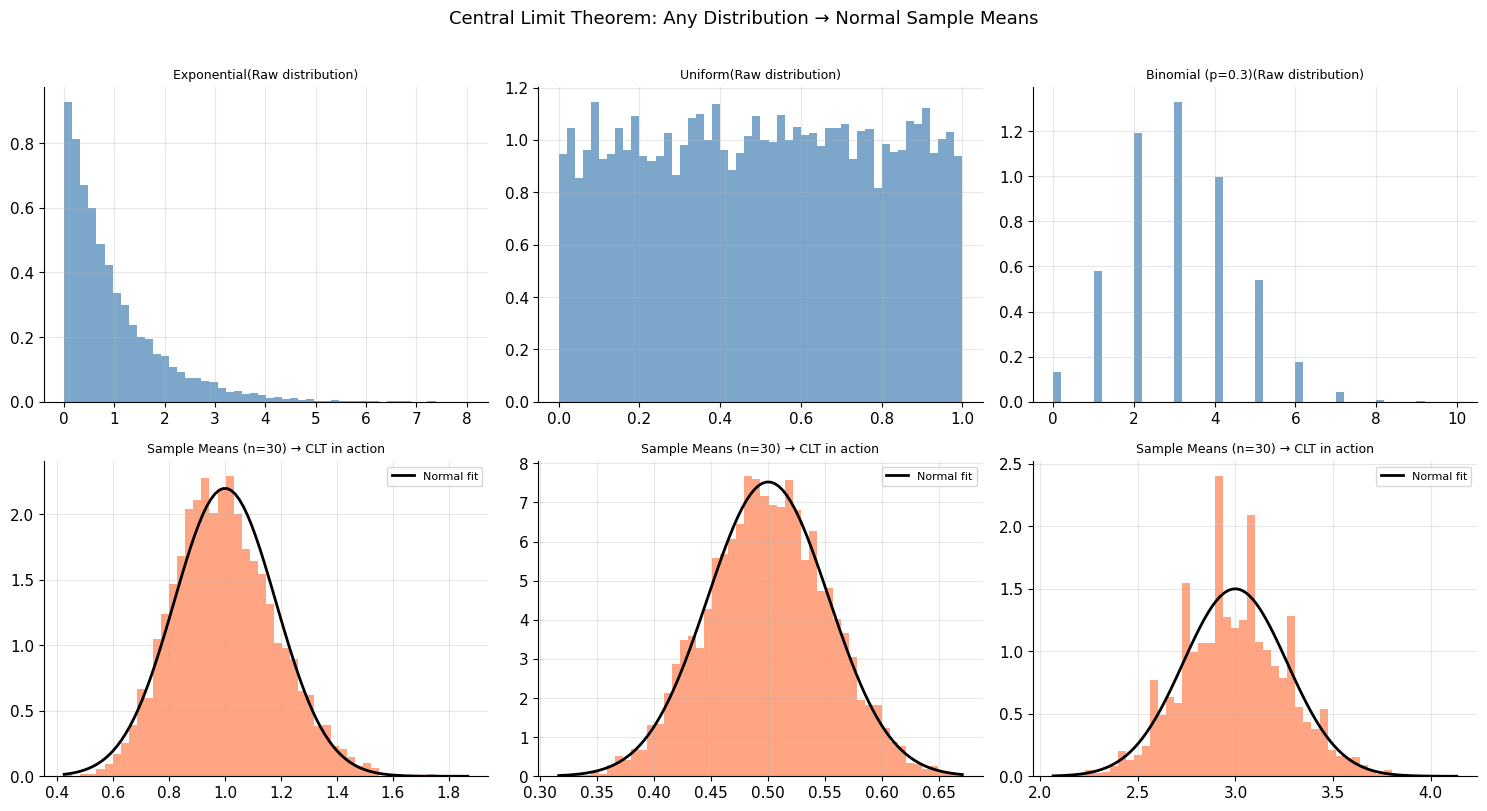

In [42]:
# Q9: Sharpe Ratio Significance Test
annual_sr = 1.5
monthly_sr = annual_sr / np.sqrt(12)
n_months = 36
t_stat = monthly_sr * np.sqrt(n_months)
p_value = 2 * (1 - norm.cdf(t_stat))
print("=== Q9: Sharpe Significance ===")
print(f"Annual SR: {annual_sr}")
print(f"Monthly SR: {monthly_sr:.4f}")
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.4f} ({p_value*100:.2f}%)")
print(f"Significant at 5%: {p_value < 0.05}")

# Q11: Central Limit Theorem Demonstration
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
distributions = {
    'Exponential': np.random.exponential,
    'Uniform': np.random.uniform,
    'Binomial (p=0.3)': lambda size: np.random.binomial(10, 0.3, size)
}

for idx, (name, dist) in enumerate(distributions.items()):
    ax_raw = axes[0, idx]
    ax_clt = axes[1, idx]
    
    raw = dist(size=10000)
    ax_raw.hist(raw, bins=50, density=True, alpha=0.7, color='steelblue')
    ax_raw.set_title(f'{name}(Raw distribution)', fontsize=9)
    
    sample_means = [np.mean(dist(size=30)) for _ in range(5000)]
    ax_clt.hist(sample_means, bins=50, density=True, alpha=0.7, color='coral')
    x_range = np.linspace(min(sample_means), max(sample_means), 100)
    ax_clt.plot(x_range, norm.pdf(x_range, np.mean(sample_means), np.std(sample_means)), 
                'k-', linewidth=2, label='Normal fit')
    ax_clt.set_title(f'Sample Means (n=30) → CLT in action', fontsize=9)
    ax_clt.legend(fontsize=8)

fig.suptitle('Central Limit Theorem: Any Distribution → Normal Sample Means', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2.5 Advanced Topics: MLE, Bayesian Inference

### Q12 [Quant Level] — Maximum Likelihood Estimation
**Interviewer asks:** *"You observe daily returns: +2%, -1%, +3%, -2%, +1%. Assuming normal returns, what are the MLE estimates of μ and σ?"*

For Normal distribution, MLE gives:
$$\hat{\mu}_{MLE} = \bar{x} = \frac{1}{n}\sum x_i$$
$$\hat{\sigma}^2_{MLE} = \frac{1}{n}\sum(x_i - \bar{x})^2$$

*Note: MLE uses $n$ not $n-1$ in denominator (biased but consistent)*

### Q13 [Quant Level] — Bayesian vs Frequentist
**Interviewer asks:** *"A strategy has 3 wins and 2 losses. What is the probability the true win rate > 50%?"*

**Frequentist:** Point estimate = 60%. No probability statement about true parameter.

**Bayesian (uniform prior):** Posterior = Beta(4, 3).
$P(p > 0.5) = 1 - F_{Beta(4,3)}(0.5) \approx 72\%$

**Trading application:** Bayesian updating is natural for strategy evaluation — incorporate prior knowledge about typical hedge fund win rates.


=== Q12: MLE ===
Returns: [ 2. -1.  3. -2.  1.]
μ_MLE = 0.60%
σ_MLE (biased) = 1.855%
σ sample (unbiased) = 2.074%

=== Q13: Bayesian Win Rate ===
Observed: 3 wins, 2 losses
MLE win rate: 60%
P(true win rate > 50%): 65.6%


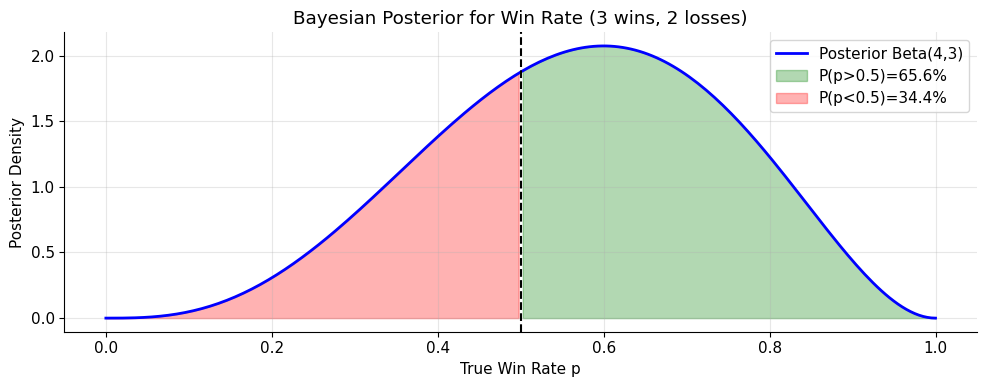

In [43]:
from scipy.stats import beta as beta_dist

# Q12: MLE
returns_obs = np.array([2, -1, 3, -2, 1]) / 100
mu_mle = np.mean(returns_obs)
sigma_mle = np.sqrt(np.mean((returns_obs - mu_mle)**2))
sigma_unbiased = np.std(returns_obs, ddof=1)
print("=== Q12: MLE ===")
print(f"Returns: {returns_obs*100}")
print(f"μ_MLE = {mu_mle*100:.2f}%")
print(f"σ_MLE (biased) = {sigma_mle*100:.3f}%")
print(f"σ sample (unbiased) = {sigma_unbiased*100:.3f}%")

# Q13: Bayesian Win Rate
wins, losses = 3, 2
alpha_post = wins + 1  # posterior alpha (uniform prior)
beta_post = losses + 1  # posterior beta
p_above_50 = 1 - beta_dist.cdf(0.5, alpha_post, beta_post)
print(f"\n=== Q13: Bayesian Win Rate ===")
print(f"Observed: {wins} wins, {losses} losses")
print(f"MLE win rate: {wins/(wins+losses):.0%}")
print(f"P(true win rate > 50%): {p_above_50:.1%}")

# Plot posterior
p_range = np.linspace(0, 1, 200)
posterior = beta_dist.pdf(p_range, alpha_post, beta_post)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(p_range, posterior, 'b-', linewidth=2, label='Posterior Beta(4,3)')
ax.fill_between(p_range, posterior, where=p_range >= 0.5, alpha=0.3, color='green', label=f'P(p>0.5)={p_above_50:.1%}')
ax.fill_between(p_range, posterior, where=p_range < 0.5, alpha=0.3, color='red', label=f'P(p<0.5)={1-p_above_50:.1%}')
ax.axvline(0.5, color='black', linestyle='--')
ax.set_title('Bayesian Posterior for Win Rate (3 wins, 2 losses)')
ax.set_xlabel('True Win Rate p')
ax.set_ylabel('Posterior Density')
ax.legend()
plt.tight_layout()
plt.show()


---
<a id='section3'></a>
# Section 3: Statistical Arbitrage 📈

> **Why this matters:** StatArb is the foundation of quantitative equity trading. Understanding cointegration, pairs trading, and mean reversion is essential for any systematic equity role.

---
## 3.1 Pairs Trading Fundamentals

### Q1 — Correlation vs Cointegration
**Interviewer asks:** *"What is the difference between correlation and cointegration? Why does this matter for pairs trading?"*

---
**Testing:** Deep understanding of time series theory vs superficial memorization.

**Intuition:**
- **Correlation** measures linear co-movement at a point in time
- **Cointegration** means two non-stationary series share a long-run equilibrium

**Formal definitions:**
- Correlation: $\rho_{XY} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$
- Cointegration: $X_t$ and $Y_t$ are cointegrated if $\exists \beta$ such that $Z_t = X_t - \beta Y_t$ is **stationary** (I(0))

**Interview answer:** "Correlation measures contemporaneous co-movement but says nothing about long-term stability. Two random walks can have high correlation over a sample period purely by chance. Cointegration is stronger — it implies the spread between the two series is mean-reverting and won't drift arbitrarily far apart. For pairs trading, cointegration is what you actually need."

**Exceptional answer:** "Two I(1) series that share a common stochastic trend are cointegrated. The key is the Granger Representation Theorem: if two series are cointegrated, there exists an error correction mechanism pulling them together. Correlation can be spurious — a classic example is the correlation between UK butter production and Bengali stock returns over some historical period. Cointegration requires shared economic fundamentals."


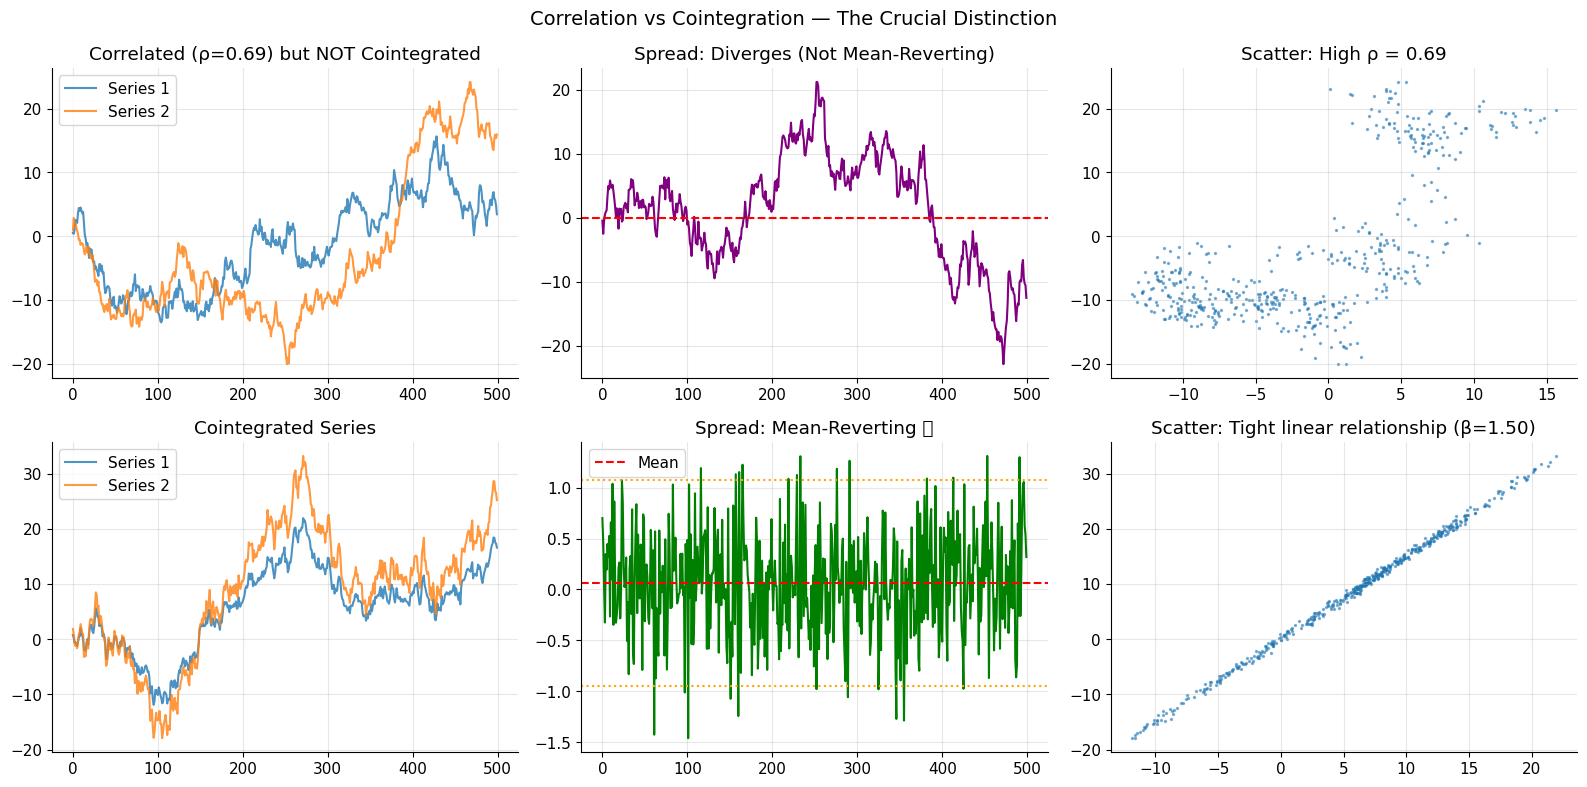

=== ADF Test on Spreads ===
Non-cointegrated spread: ADF stat=-1.566, p=0.501 → NON-STATIONARY
Cointegrated spread:     ADF stat=-22.848, p=0.0000 → STATIONARY


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

np.random.seed(42)

# Simulate: correlated but NOT cointegrated
n = 500
w1 = np.cumsum(np.random.randn(n))  # Random walk 1
w2 = np.cumsum(np.random.randn(n))  # Random walk 2 (independent)
corr_spurious = np.corrcoef(w1, w2)[0,1]

# Simulate: COINTEGRATED series
beta_true = 1.5
spread_noise = np.random.randn(n) * 0.5  # stationary noise
y1 = np.cumsum(np.random.randn(n))  # Non-stationary
y2 = beta_true * y1 + spread_noise   # Cointegrated with y1

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Correlated but not cointegrated
axes[0,0].plot(w1, label='Series 1', alpha=0.8)
axes[0,0].plot(w2, label='Series 2', alpha=0.8)
axes[0,0].set_title(f'Correlated (ρ={corr_spurious:.2f}) but NOT Cointegrated')
axes[0,0].legend()

# Their spread diverges
spread_non_coint = w1 - w2
axes[0,1].plot(spread_non_coint, color='purple')
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_title('Spread: Diverges (Not Mean-Reverting)')

axes[0,2].scatter(w1, w2, s=2, alpha=0.5)
axes[0,2].set_title(f'Scatter: High ρ = {corr_spurious:.2f}')

# Cointegrated series
axes[1,0].plot(y1, label='Series 1', alpha=0.8)
axes[1,0].plot(y2, label='Series 2', alpha=0.8)
axes[1,0].set_title('Cointegrated Series')
axes[1,0].legend()

# Their spread is stationary
hedge_ratio = OLS(y2, add_constant(y1)).fit().params[1]
spread_coint = y2 - hedge_ratio * y1
axes[1,1].plot(spread_coint, color='green')
axes[1,1].axhline(np.mean(spread_coint), color='red', linestyle='--', label='Mean')
axes[1,1].axhline(np.mean(spread_coint)+2*np.std(spread_coint), color='orange', linestyle=':')
axes[1,1].axhline(np.mean(spread_coint)-2*np.std(spread_coint), color='orange', linestyle=':')
axes[1,1].set_title('Spread: Mean-Reverting ✅')
axes[1,1].legend()

axes[1,2].scatter(y1, y2, s=2, alpha=0.5)
axes[1,2].set_title(f'Scatter: Tight linear relationship (β={hedge_ratio:.2f})')

plt.suptitle('Correlation vs Cointegration — The Crucial Distinction', fontsize=14)
plt.tight_layout()
plt.show()

# ADF tests
adf_non_coint = adfuller(spread_non_coint)
adf_coint = adfuller(spread_coint)
print("=== ADF Test on Spreads ===")
print(f"Non-cointegrated spread: ADF stat={adf_non_coint[0]:.3f}, p={adf_non_coint[1]:.3f} → {'STATIONARY' if adf_non_coint[1]<0.05 else 'NON-STATIONARY'}")
print(f"Cointegrated spread:     ADF stat={adf_coint[0]:.3f}, p={adf_coint[1]:.4f} → {'STATIONARY' if adf_coint[1]<0.05 else 'NON-STATIONARY'}")


### Q2 — Why Correlated Stocks Make Poor Pairs

**Interviewer asks:** *"Why can two highly correlated stocks still produce a poor pairs trade?"*

---
**Key reasons:**
1. **Correlation is not constant** — it breaks down during regime changes
2. **No error correction mechanism** — spread can drift indefinitely
3. **Hedge ratio instability** — the β that makes the spread stationary changes over time
4. **Different risk factors** — high correlation may come from market beta, not genuine pair relationship
5. **Liquidity mismatch** — asymmetric transaction costs erode the edge

**Exceptional answer:** "Correlation captures co-movement but not level — two stocks with ρ=0.9 driven entirely by market beta will converge only if the market mean-reverts. The right test is Engle-Granger or Johansen cointegration, which tests whether the *spread* is I(0). Even with cointegration confirmed, the hedge ratio may be time-varying, requiring rolling OLS or Kalman filter estimation."

### Q3 — Hedge Ratio Calculation

**Interviewer asks:** *"How do you calculate the hedge ratio for a pairs trade?"*

**Method 1 — OLS Regression:**
$$Y_t = \alpha + \beta X_t + \epsilon_t$$
Hedge ratio $\beta = \frac{Cov(Y,X)}{Var(X)}$

**Method 2 — Total Least Squares (Orthogonal):**
Minimizes perpendicular distance, better when both series have measurement error

**Method 3 — Johansen (Preferred):**
Uses eigenvectors of cointegration matrix — properly accounts for multivariate dynamics

**Key:** Regress $Y$ on $X$ (not the other way around!) — the direction matters for which series you're hedging.


### Q4 — Entry/Exit Thresholds & Z-Score

**Interviewer asks:** *"How do you determine entry and exit thresholds for a pairs trade?"*

---
**Z-Score:**
$$z_t = \frac{S_t - \mu_S}{\sigma_S}$$

where $S_t = Y_t - \hat{\beta} X_t$ is the spread, $\mu_S$ and $\sigma_S$ estimated on a rolling window.

**Typical thresholds:**
| Signal | Threshold | Action |
|--------|-----------|--------|
| Short spread | $z > +2$ | Sell Y, Buy X |
| Long spread | $z < -2$ | Buy Y, Sell X |
| Exit | $|z| < 0.5$ | Close position |
| Stop loss | $|z| > 3$ | Cut loss |

**What determines optimal thresholds?**
- Trade-off: higher threshold → fewer trades but higher edge per trade
- Half-life of mean reversion (determines how long you'll hold)
- Transaction costs (determine minimum required spread)
- Sharpe optimization via simulation


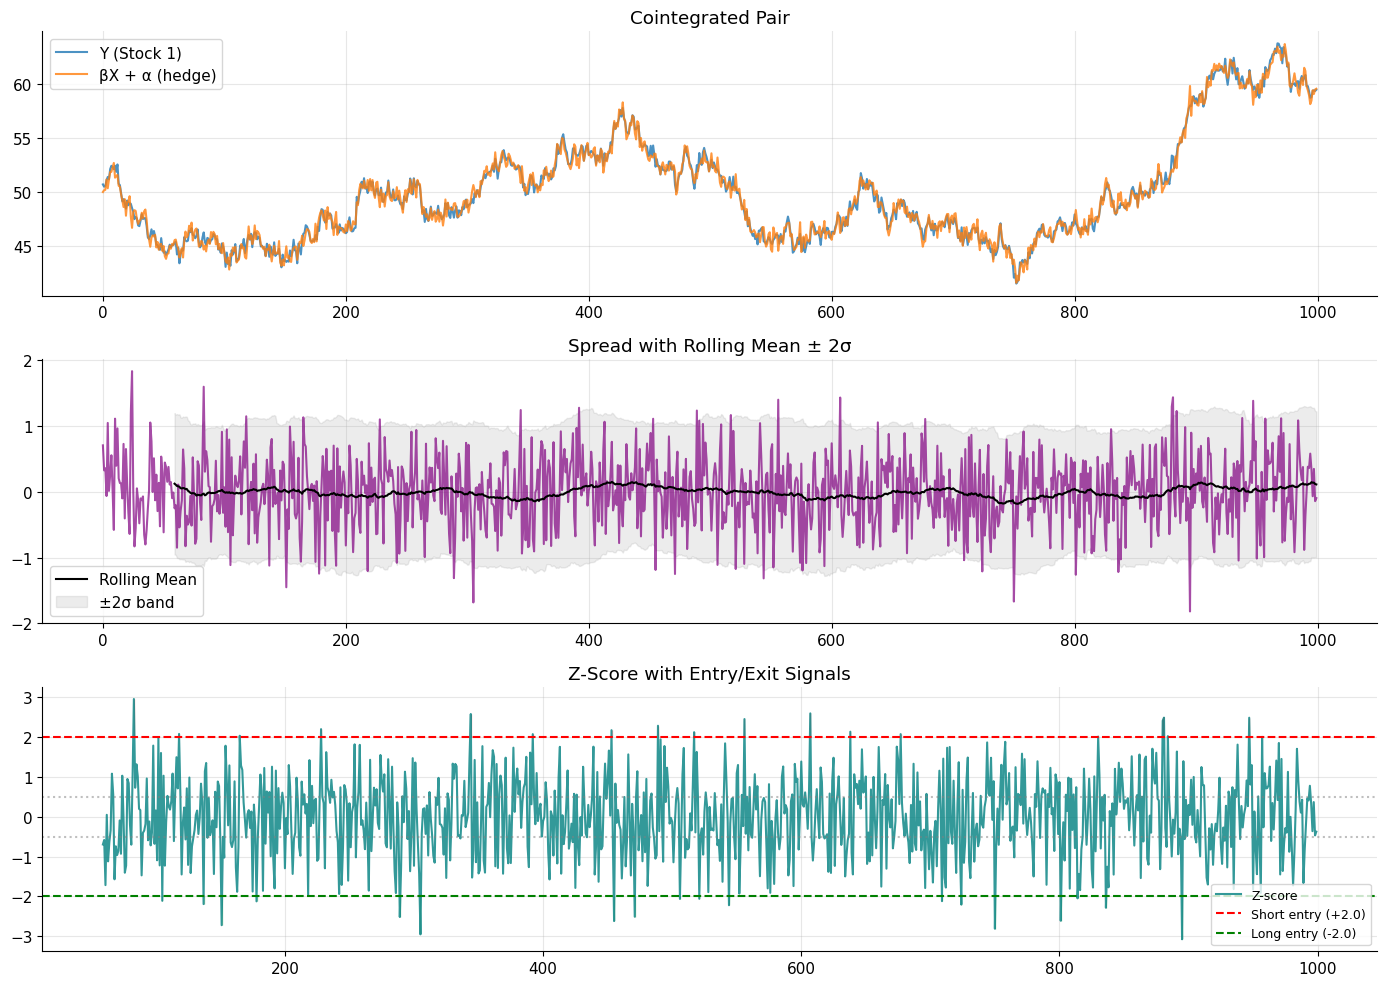

Hedge ratio β = 1.4883
Intercept α = 5.3680
Spread mean = 0.0000, std = 0.5354
Long signals: 18, Short signals: 19


In [45]:
# Q4-Q7: Full Pairs Trading Implementation
np.random.seed(42)

# Simulate cointegrated pair (like GLD/GDX)
n = 1000
beta_true = 1.5
common_factor = np.cumsum(np.random.randn(n) * 0.5)
noise1 = np.random.randn(n) * 0.3
noise2 = np.random.randn(n) * 0.3
y = 50 + common_factor + noise1
x = 30 + common_factor / beta_true + noise2

# Calculate hedge ratio via OLS
model = OLS(y, add_constant(x)).fit()
beta_hat = model.params[1]
alpha_hat = model.params[0]
spread = y - beta_hat * x - alpha_hat

# Rolling z-score
window = 60
spread_s = pd.Series(spread)
roll_mean = spread_s.rolling(window).mean()
roll_std = spread_s.rolling(window).std()
z_score = (spread_s - roll_mean) / roll_std

# Trading signals
entry_threshold = 2.0
exit_threshold = 0.5
long_spread = z_score < -entry_threshold
short_spread = z_score > entry_threshold
exit_signal = z_score.abs() < exit_threshold

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(y, label='Y (Stock 1)', alpha=0.8)
axes[0].plot(x * beta_hat + alpha_hat, label='βX + α (hedge)', alpha=0.8)
axes[0].set_title('Cointegrated Pair')
axes[0].legend()

axes[1].plot(spread, color='purple', alpha=0.7)
axes[1].plot(roll_mean, color='black', linewidth=1.5, label='Rolling Mean')
axes[1].fill_between(range(n),
    (roll_mean + 2*roll_std).values, 
    (roll_mean - 2*roll_std).values,
    alpha=0.15, color='gray', label='±2σ band')
axes[1].set_title('Spread with Rolling Mean ± 2σ')
axes[1].legend()

axes[2].plot(z_score, color='teal', alpha=0.8, label='Z-score')
axes[2].axhline(entry_threshold, color='red', linestyle='--', label=f'Short entry (+{entry_threshold})')
axes[2].axhline(-entry_threshold, color='green', linestyle='--', label=f'Long entry (-{entry_threshold})')
axes[2].axhline(exit_threshold, color='gray', linestyle=':', alpha=0.5)
axes[2].axhline(-exit_threshold, color='gray', linestyle=':', alpha=0.5)

# Color entry/exit regions
axes[2].fill_between(range(n), z_score, entry_threshold, 
                     where=z_score > entry_threshold, alpha=0.3, color='red')
axes[2].fill_between(range(n), -entry_threshold, z_score,
                     where=z_score < -entry_threshold, alpha=0.3, color='green')
axes[2].set_title('Z-Score with Entry/Exit Signals')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Hedge ratio β = {beta_hat:.4f}")
print(f"Intercept α = {alpha_hat:.4f}")
print(f"Spread mean = {spread.mean():.4f}, std = {spread.std():.4f}")
print(f"Long signals: {(z_score < -2).sum()}, Short signals: {(z_score > 2).sum()}")


### Q5 — Stationarity Tests

**Interviewer asks:** *"How do you test stationarity? What are the ADF and KPSS tests?"*

---
**Augmented Dickey-Fuller (ADF) Test:**
- H₀: Unit root (non-stationary)
- H₁: Stationary
- Reject H₀ → stationary if p < 0.05

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^p \delta_i \Delta y_{t-i} + \epsilon_t$$

Test: $\gamma = 0$ (unit root)

**KPSS Test:**
- H₀: **Stationary** (opposite of ADF!)
- H₁: Unit root

**Best practice:** Use both — if ADF rejects and KPSS fails to reject, confident in stationarity.

### Q6 — Half-Life of Mean Reversion

**Interviewer asks:** *"What is the half-life of mean reversion and why does it matter?"*

For an **Ornstein-Uhlenbeck process**:
$$dS_t = \kappa(\mu - S_t)dt + \sigma dW_t$$

The half-life is: $t_{1/2} = \frac{\ln 2}{\kappa}$

**Estimation:** Regress $\Delta S_t = a + b S_{t-1} + \epsilon$, then $\kappa = -b$ and $t_{1/2} = -\ln(2)/b$

**Why it matters:**
- Half-life 1 day → intraday strategy
- Half-life 1 week → weekly rebalancing
- Half-life 1 month → monthly holding
- Too long → too much capital tied up, bad risk-adjusted return


=== ADF and KPSS Tests ===
Random Walk              : ADF p=0.2366 (NON-STATIONARY ) KPSS p=0.010
Stationary AR(1)         : ADF p=0.0000 (STATIONARY     ) KPSS p=0.100
Cointegrated Spread      : ADF p=0.0000 (STATIONARY     ) KPSS p=0.100

=== Half-Life Estimation ===
Regression coefficient b = -0.9840
Mean reversion speed κ = 0.9840
Half-life = 0.7 periods


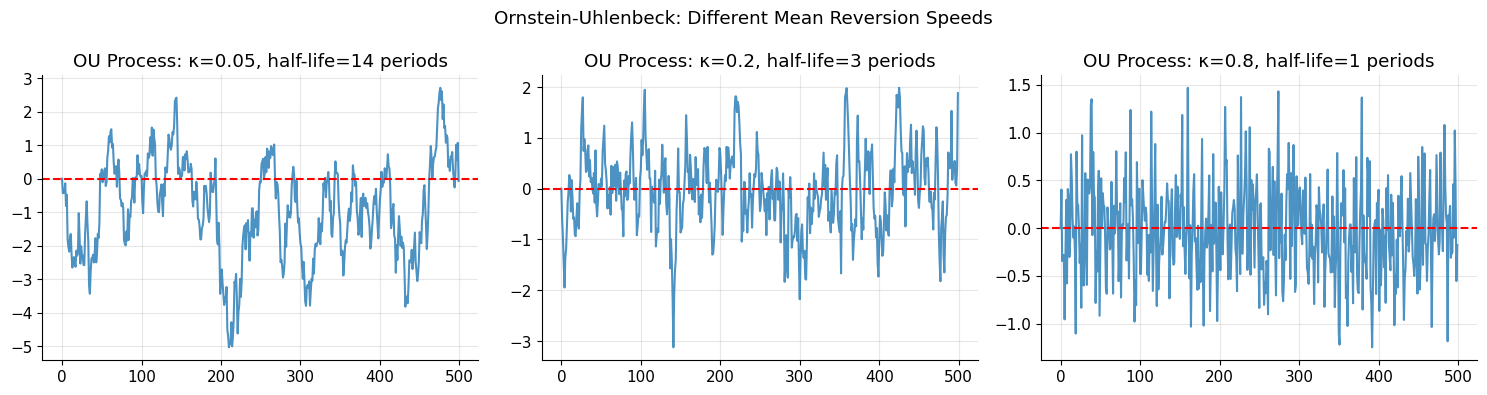

In [46]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

# Stationarity Tests
print("=== ADF and KPSS Tests ===")
series_tests = {
    'Random Walk': np.cumsum(np.random.randn(500)),
    'Stationary AR(1)': np.zeros(500),
    'Cointegrated Spread': spread
}

# Fill stationary AR(1)
phi = 0.8
e = np.random.randn(500)
for t in range(1, 500):
    series_tests['Stationary AR(1)'][t] = phi * series_tests['Stationary AR(1)'][t-1] + e[t]

for name, series in series_tests.items():
    adf_res = adfuller(series, autolag='AIC')
    try:
        kpss_res = kpss(series, regression='c', nlags='auto')
        kpss_p = kpss_res[1]
        kpss_stat = kpss_res[0]
    except:
        kpss_p, kpss_stat = 0.1, 0.1
    
    stationary = adf_res[1] < 0.05
    print(f"{name:25s}: ADF p={adf_res[1]:.4f} ({'STATIONARY' if stationary else 'NON-STATIONARY':15s}) KPSS p={kpss_p:.3f}")

# Half-Life of Mean Reversion
print("\n=== Half-Life Estimation ===")
S = spread
delta_S = np.diff(S)
S_lagged = S[:-1]
S_lagged_dm = S_lagged - np.mean(S_lagged)

# OLS regression
b = np.cov(delta_S, S_lagged)[0,1] / np.var(S_lagged)
half_life = -np.log(2) / b
print(f"Regression coefficient b = {b:.4f}")
print(f"Mean reversion speed κ = {-b:.4f}")
print(f"Half-life = {half_life:.1f} periods")

# Ornstein-Uhlenbeck simulation
def simulate_ou(kappa, mu, sigma, T, dt=1, S0=0):
    n = int(T/dt)
    S = np.zeros(n)
    S[0] = S0
    for t in range(1, n):
        dW = np.random.randn() * np.sqrt(dt)
        S[t] = S[t-1] + kappa*(mu - S[t-1])*dt + sigma*dW
    return S

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, kappa in enumerate([0.05, 0.2, 0.8]):
    hl = np.log(2)/kappa
    ou = simulate_ou(kappa, 0, 0.5, 500)
    axes[idx].plot(ou, alpha=0.8)
    axes[idx].axhline(0, color='red', linestyle='--')
    axes[idx].set_title(f'OU Process: κ={kappa}, half-life={hl:.0f} periods')

plt.suptitle('Ornstein-Uhlenbeck: Different Mean Reversion Speeds')
plt.tight_layout()
plt.show()


### Q7 — Hurst Exponent

**Interviewer asks:** *"What is the Hurst exponent and how do you use it to classify time series?"*

---
The Hurst exponent $H$ characterizes long-range dependence:

| H value | Regime | Trading Implication |
|---------|--------|---------------------|
| $H < 0.5$ | **Mean-reverting** | Pairs trading, stat arb |
| $H = 0.5$ | **Random walk** | Efficient market, no edge |
| $H > 0.5$ | **Trending** | Momentum strategies |

**Estimation (R/S method):**
$$E\left[\frac{R(n)}{S(n)}\right] = C \cdot n^H$$

Regress $\log(R/S)$ vs $\log(n)$ to get $H$.

**Exceptional answer:** "The Hurst exponent quantifies long-memory. A spread with H < 0.5 has anti-persistent returns — momentum reverses — perfect for statistical arbitrage. I'd compute H on rolling windows to detect regime changes. When H approaches 0.5, the spread is losing its mean-reversion property and I'd reduce position or exit."


=== Hurst Exponent Results ===
Random Walk:    H = 1.019 (expected ~0.5)
Mean-Reverting: H = 0.807 (expected <0.5)
Trending:       H = 0.993 (expected >0.5)


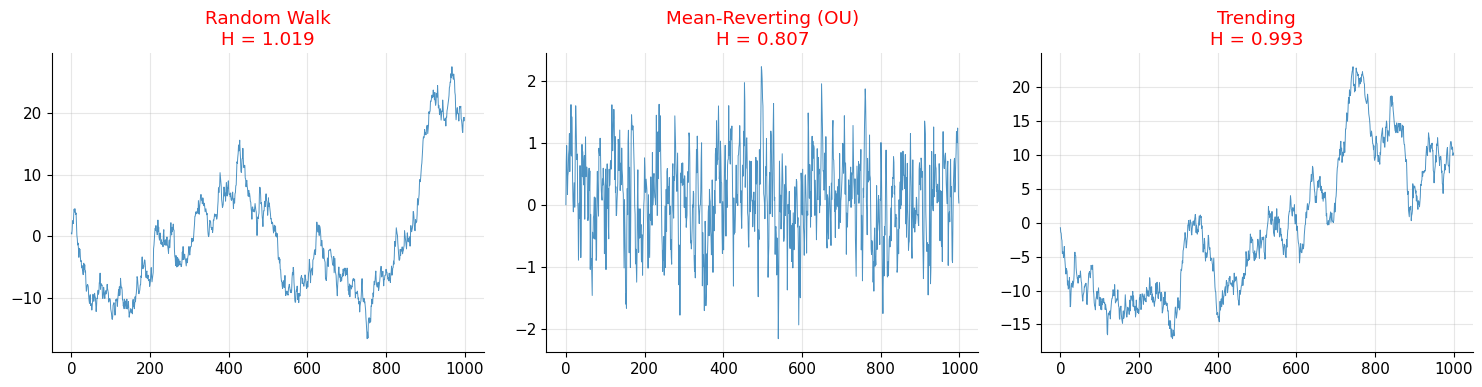

In [47]:
# Hurst Exponent Calculation
def hurst_exponent(ts, lags=range(2, 100)):
    '''Compute Hurst exponent using R/S analysis'''
    ts = np.array(ts)
    rs_values = []
    lag_values = []
    
    for lag in lags:
        if lag >= len(ts)//2:
            break
        subseries = [ts[i:i+lag] for i in range(0, len(ts)-lag, lag)]
        if len(subseries) < 2:
            continue
        rs_list = []
        for sub in subseries:
            if len(sub) < 2:
                continue
            mean_sub = np.mean(sub)
            deviations = np.cumsum(sub - mean_sub)
            R = np.max(deviations) - np.min(deviations)
            S = np.std(sub, ddof=1)
            if S > 0:
                rs_list.append(R/S)
        if rs_list:
            rs_values.append(np.mean(rs_list))
            lag_values.append(lag)
    
    if len(lag_values) < 2:
        return 0.5
    
    log_lags = np.log(lag_values)
    log_rs = np.log(rs_values)
    H = np.polyfit(log_lags, log_rs, 1)[0]
    return H

# Test on different series
np.random.seed(42)
random_walk = np.cumsum(np.random.randn(1000))
ou_series = simulate_ou(0.3, 0, 0.5, 1000)
trend_series = np.cumsum(np.random.randn(1000)) + np.linspace(0, 5, 1000)

h_rw = hurst_exponent(random_walk)
h_ou = hurst_exponent(ou_series)
h_tr = hurst_exponent(trend_series)

print("=== Hurst Exponent Results ===")
print(f"Random Walk:    H = {h_rw:.3f} (expected ~0.5)")
print(f"Mean-Reverting: H = {h_ou:.3f} (expected <0.5)")
print(f"Trending:       H = {h_tr:.3f} (expected >0.5)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, series, name, H in zip(axes, 
    [random_walk, ou_series, trend_series],
    ['Random Walk', 'Mean-Reverting (OU)', 'Trending'],
    [h_rw, h_ou, h_tr]):
    ax.plot(series, alpha=0.8, linewidth=0.7)
    color = 'orange' if abs(H-0.5) < 0.05 else ('green' if H < 0.5 else 'red')
    ax.set_title(f'{name}\nH = {H:.3f}', color=color)
plt.tight_layout()
plt.show()


---
<a id='section4'></a>
# Section 4: Fixed Income & Interest Rates 💰

> **Why this matters:** Fixed income is the largest asset class globally. Understanding rates is essential for every trading role — even equity traders need to understand discount rates, credit spreads, and rate sensitivity.

---
## 4.1 Interest Rate Fundamentals

### Q1 [Easy] — Compounding Conventions
**Interviewer asks:** *"What is the difference between simple, compound, and continuous compounding?"*

| Convention | Formula | Example (10%, 1yr) |
|------------|---------|-------------------|
| Simple | $A = P(1 + rt)$ | $1.10 |
| Compound (annual) | $A = P(1+r)^t$ | $1.10 |
| Compound (semi) | $A = P(1+r/2)^{2t}$ | $1.1025 |
| Continuous | $A = Pe^{rt}$ | $1.1052 |

**Key insight:** Continuous compounding = limit of $n$-period compounding as $n → ∞$

**Trading application:** Fixed income conventions vary by market — US bonds use semi-annual compounding; money markets use simple interest; derivatives often use continuous compounding.

### Q2 [Medium] — Yield Curve Shapes
**Interviewer asks:** *"Describe the yield curve shapes and what each implies about the economy."*

| Shape | Implication | Example Period |
|-------|------------|---------------|
| Normal (upward sloping) | Economic expansion expected | Most of 2010s |
| Inverted | Recession expected | 2022-2023, 2006-2007 |
| Flat | Transition / uncertainty | |
| Humped | Near-term tightening followed by easing | |

**Exceptional answer:** "The yield curve encodes expectations under the Expectations Hypothesis — long rates are geometric averages of expected short rates. But there are also term premia — compensation for duration risk. An inverted curve means markets expect future short rates to be lower than today's — historically a reliable recession predictor with a 12-18 month lag."


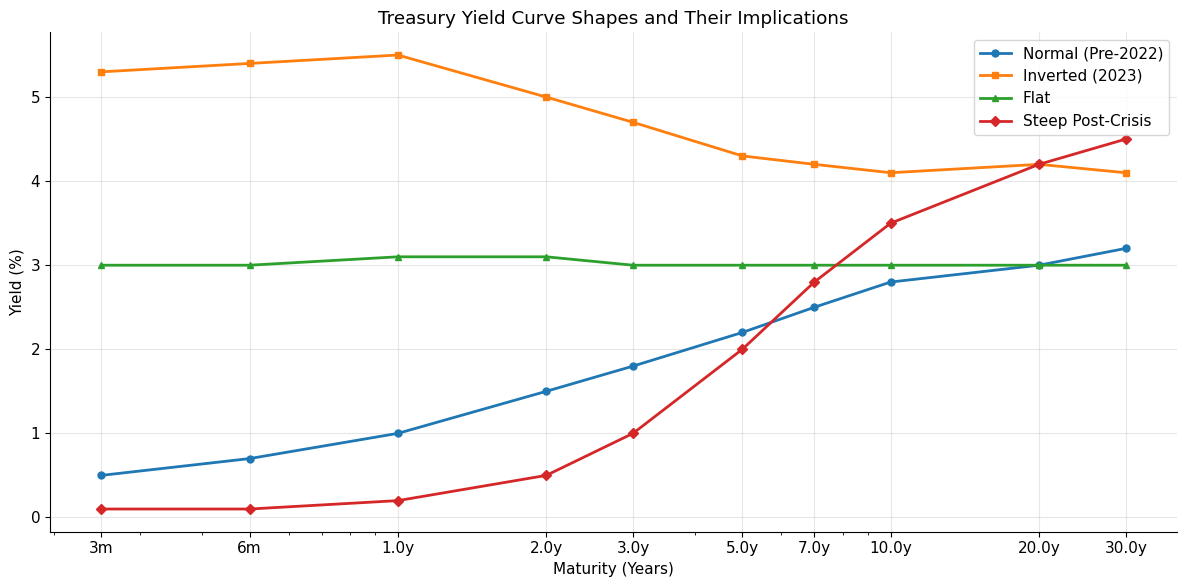

In [48]:
# Yield Curve Visualization
maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])

yield_curves = {
    'Normal (Pre-2022)': np.array([0.5, 0.7, 1.0, 1.5, 1.8, 2.2, 2.5, 2.8, 3.0, 3.2]),
    'Inverted (2023)': np.array([5.3, 5.4, 5.5, 5.0, 4.7, 4.3, 4.2, 4.1, 4.2, 4.1]),
    'Flat': np.array([3.0, 3.0, 3.1, 3.1, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]),
    'Steep Post-Crisis': np.array([0.1, 0.1, 0.2, 0.5, 1.0, 2.0, 2.8, 3.5, 4.2, 4.5]),
}

fig, ax = plt.subplots(figsize=(12, 6))
styles = ['-o', '-s', '-^', '-D']
for (name, curve), style in zip(yield_curves.items(), styles):
    ax.plot(maturities, curve, style, label=name, linewidth=2, markersize=5)

ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Treasury Yield Curve Shapes and Their Implications')
ax.legend()
ax.set_xscale('log')
ax.set_xticks(maturities)
ax.set_xticklabels([f'{m}y' if m >= 1 else f'{int(m*12)}m' for m in maturities])
plt.tight_layout()
plt.show()


## 4.2 Bond Mathematics

### Q3 [Medium] — Bond Pricing
**Interviewer asks:** *"How do you price a bond?"*

**Formula:**
$$P = \sum_{t=1}^{T} \frac{C}{(1+y/2)^t} + \frac{F}{(1+y/2)^{2T}}$$

Where:
- $C$ = semi-annual coupon payment = (coupon rate × face value) / 2
- $y$ = yield to maturity (annual)  
- $T$ = years to maturity
- $F$ = face value (typically 100 or 1000)

**Key relationship:** Bond price and yield move **inversely**.

### Q4 [Medium] — DV01
**Interviewer asks:** *"What is DV01 and how do you calculate it?"*

**DV01** (Dollar Value of 1 basis point) = sensitivity of bond price to 1bp change in yield

$$DV01 = -\frac{\Delta P}{\Delta y} \times 0.0001$$

**Approximation via Modified Duration:**
$$DV01 \approx P \times D_{mod} \times 0.0001$$

### Q5 [Hard] — Macaulay Duration
**Interviewer asks:** *"Derive Macaulay Duration from first principles."*

$$D_{mac} = \frac{\sum_{t=1}^T t \cdot PV(CF_t)}{P} = \frac{\sum_{t=1}^T t \cdot \frac{CF_t}{(1+y)^t}}{P}$$

**Modified Duration:** $D_{mod} = \frac{D_{mac}}{1 + y/m}$ (m = coupons per year)

**Price sensitivity:** $\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y$

### Q6 [Hard] — Convexity

$$C = \frac{1}{P} \sum_{t=1}^T \frac{t(t+1) \cdot CF_t}{(1+y)^{t+2}}$$

**Full price change:**
$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2$$

**Why convexity is valuable:** All else equal, higher convexity bonds outperform in both rallies and sell-offs → convexity has positive value.


=== Bond Analytics ===
Face: $1000, Coupon: 5%, YTM: 4%, Maturity: 10yr
Price: $1081.76 (premium)
Macaulay Duration: 8.0809 years
Modified Duration: 7.9225
Convexity: 301.8899
DV01: $0.8570 per $1000 face


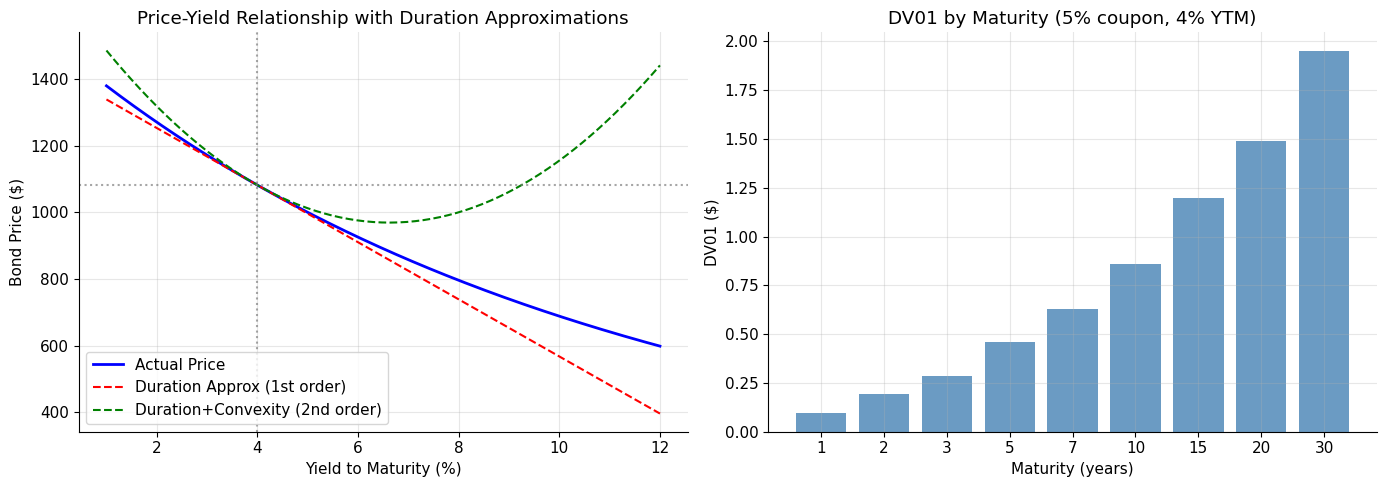

In [49]:
# Bond Pricing, Duration, Convexity
def bond_price(face, coupon_rate, ytm, years, freq=2):
    '''Calculate bond price'''
    c = face * coupon_rate / freq  # coupon payment
    n = years * freq               # number of periods
    y = ytm / freq                 # yield per period
    
    # PV of coupons + PV of face
    t = np.arange(1, n+1)
    pv_coupons = np.sum(c / (1+y)**t)
    pv_face = face / (1+y)**n
    return pv_coupons + pv_face

def macaulay_duration(face, coupon_rate, ytm, years, freq=2):
    c = face * coupon_rate / freq
    n = int(years * freq)
    y = ytm / freq
    price = bond_price(face, coupon_rate, ytm, years, freq)
    
    weighted_times = sum(t/freq * c/(1+y)**t for t in range(1, n+1))
    weighted_times += years * face/(1+y)**n
    return weighted_times / price

def modified_duration(face, coupon_rate, ytm, years, freq=2):
    mac = macaulay_duration(face, coupon_rate, ytm, years, freq)
    return mac / (1 + ytm/freq)

def convexity(face, coupon_rate, ytm, years, freq=2):
    c = face * coupon_rate / freq
    n = int(years * freq)
    y = ytm / freq
    price = bond_price(face, coupon_rate, ytm, years, freq)
    
    conv_sum = sum(t*(t+1)*c/(1+y)**(t+2) for t in range(1, n+1))
    conv_sum += n*(n+1)*face/(1+y)**(n+2)
    return conv_sum / price

def dv01(face, coupon_rate, ytm, years, freq=2):
    p_up = bond_price(face, coupon_rate, ytm + 0.0001, years, freq)
    p_dn = bond_price(face, coupon_rate, ytm - 0.0001, years, freq)
    return (p_dn - p_up) / 2

# Example: 5% coupon, 10-year, $1000 face, 4% YTM
face, coupon, ytm, years = 1000, 0.05, 0.04, 10
P = bond_price(face, coupon, ytm, years)
mac_dur = macaulay_duration(face, coupon, ytm, years)
mod_dur = modified_duration(face, coupon, ytm, years)
conv = convexity(face, coupon, ytm, years)
DV01 = dv01(face, coupon, ytm, years)

print(f"=== Bond Analytics ===")
print(f"Face: ${face}, Coupon: {coupon:.0%}, YTM: {ytm:.0%}, Maturity: {years}yr")
print(f"Price: ${P:.2f} ({'premium' if P > face else 'discount'})")
print(f"Macaulay Duration: {mac_dur:.4f} years")
print(f"Modified Duration: {mod_dur:.4f}")
print(f"Convexity: {conv:.4f}")
print(f"DV01: ${DV01:.4f} per $1000 face")

# Price-Yield relationship
ytms = np.linspace(0.01, 0.12, 200)
prices = [bond_price(face, coupon, y, years) for y in ytms]

# Duration approximation
P0 = bond_price(face, coupon, ytm, years)
prices_approx_dur = [P0 * (1 - mod_dur * (y - ytm)) for y in ytms]
prices_approx_conv = [P0 * (1 - mod_dur*(y-ytm) + 0.5*conv*(y-ytm)**2) for y in ytms]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(ytms*100, prices, 'b-', linewidth=2, label='Actual Price')
ax.plot(ytms*100, prices_approx_dur, 'r--', linewidth=1.5, label='Duration Approx (1st order)')
ax.plot(ytms*100, prices_approx_conv, 'g--', linewidth=1.5, label='Duration+Convexity (2nd order)')
ax.axvline(ytm*100, color='gray', linestyle=':', alpha=0.7)
ax.axhline(P0, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Yield to Maturity (%)')
ax.set_ylabel('Bond Price ($)')
ax.set_title('Price-Yield Relationship with Duration Approximations')
ax.legend()

# DV01 by maturity
mats = [1, 2, 3, 5, 7, 10, 15, 20, 30]
dv01s = [dv01(face, coupon, ytm, m) for m in mats]
axes[1].bar([str(m) for m in mats], dv01s, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Maturity (years)')
axes[1].set_ylabel('DV01 ($)')
axes[1].set_title(f'DV01 by Maturity ({coupon:.0%} coupon, {ytm:.0%} YTM)')
plt.tight_layout()
plt.show()


## 4.3 Forward Rates and Spot Rates

### Q7 [Hard] — Bootstrap the Spot Curve
**Interviewer asks:** *"How do you derive spot rates from par yields? Walk me through the bootstrap method."*

**Bootstrap algorithm:**
1. 1-year par yield = 1-year spot rate (trivially)
2. For 2-year par bond: solve for $s_2$ knowing $s_1$:

$$P = \frac{c}{1+s_1} + \frac{c + 100}{(1+s_2)^2} = 100$$

3. Continue iteratively for each maturity.

### Q8 [Hard] — Forward Rate Formula
*"Calculate the 1-year forward rate, 2 years from now (1y2y) given spot rates."*

**No-arbitrage:** $(1+s_3)^3 = (1+s_2)^2 \cdot (1+f_{2,3})$

$$f_{2,3} = \frac{(1+s_3)^3}{(1+s_2)^2} - 1$$

**Trading application:** If actual forward rate < market forward rate → steepening trade opportunity.


=== Bootstrapped Spot Rates ===
  Maturity    Par Yield    Spot Rate       Spread
         1y       4.500%       4.500%        0.0bp
         2y       4.800%       4.807%        0.7bp
         3y       5.000%       5.015%        1.5bp
         5y       5.200%       4.161%     -103.9bp
         7y       5.300%       3.782%     -151.8bp
        10y       5.400%       3.232%     -216.8bp

=== Implied Forward Rates ===
1y2y forward rate: 5.115%
2y3y forward rate: 5.433%
3y5y forward rate: 2.893%
5y7y forward rate: 2.840%
7y10y forward rate: 1.959%


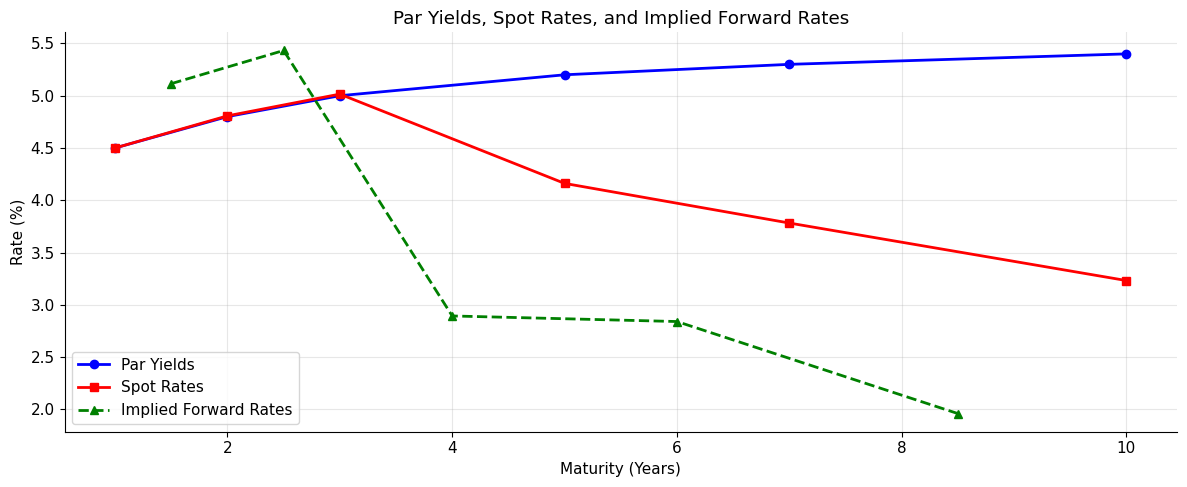

In [50]:
# Spot Rate Bootstrap & Forward Rates
# Example par yields
maturities = [1, 2, 3, 5, 7, 10]
par_yields = np.array([4.5, 4.8, 5.0, 5.2, 5.3, 5.4]) / 100

# Bootstrap spot rates
spot_rates = np.zeros(len(par_yields))
spot_rates[0] = par_yields[0]  # 1-year spot = par yield

for i in range(1, len(par_yields)):
    T = maturities[i]
    c = par_yields[i]
    # Sum of discounted coupons at known spots
    pv_coupons = sum(c / (1 + spot_rates[j])**(maturities[j]) for j in range(i))
    # Solve for spot_rates[i]: c/(1+s)^T + 1/(1+s)^T = 1 - pv_coupons
    # (1+c)/(1+s)^T = 1 - pv_coupons
    # s = ((1+c)/(1-pv_coupons))^(1/T) - 1
    spot_rates[i] = ((1 + c) / (1 - pv_coupons))**(1/T) - 1

print("=== Bootstrapped Spot Rates ===")
print(f"{'Maturity':>10} {'Par Yield':>12} {'Spot Rate':>12} {'Spread':>12}")
for i, (m, par, spot) in enumerate(zip(maturities, par_yields, spot_rates)):
    print(f"{m:>10}y {par*100:>11.3f}% {spot*100:>11.3f}% {(spot-par)*10000:>10.1f}bp")

# Forward rates
print("\n=== Implied Forward Rates ===")
for i in range(1, len(spot_rates)):
    T1, T2 = maturities[i-1], maturities[i]
    s1, s2 = spot_rates[i-1], spot_rates[i]
    fwd = ((1+s2)**T2 / (1+s1)**T1)**(1/(T2-T1)) - 1
    print(f"{T1}y{T2}y forward rate: {fwd*100:.3f}%")

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(maturities, par_yields*100, 'b-o', label='Par Yields', linewidth=2)
ax.plot(maturities, spot_rates*100, 'r-s', label='Spot Rates', linewidth=2)

# Add forward rates
fwd_mids = []
fwd_vals = []
for i in range(1, len(spot_rates)):
    T1, T2 = maturities[i-1], maturities[i]
    s1, s2 = spot_rates[i-1], spot_rates[i]
    fwd = ((1+s2)**T2 / (1+s1)**T1)**(1/(T2-T1)) - 1
    fwd_mids.append((T1+T2)/2)
    fwd_vals.append(fwd*100)

ax.plot(fwd_mids, fwd_vals, 'g-^', label='Implied Forward Rates', linewidth=2, linestyle='--')
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Rate (%)')
ax.set_title('Par Yields, Spot Rates, and Implied Forward Rates')
ax.legend()
plt.tight_layout()
plt.show()


---
<a id='section5'></a>
# Section 5: Forwards & Futures Contracts 📦

> **Why this matters:** Futures are the primary instrument for directional trading, hedging, and speculation across all asset classes. Every prop trader must understand fair value, basis, and arbitrage.

---

### Q1 [Easy] — Forward Price Formula
**Interviewer asks:** *"What is the fair forward price for a non-dividend paying stock?"*

**Cost of Carry Model:**
$$F_0 = S_0 \cdot e^{rT}$$

or discrete: $F_0 = S_0 (1 + r)^T$

**Intuition:** If you want to buy a stock in 1 year, you can:
1. Buy now → pay $S_0$ today, tie up capital at rate $r$
2. Enter forward → pay nothing now, pay $F_0$ in 1 year

No arbitrage requires: $F_0 = S_0 e^{rT}$

### Q2 [Medium] — Dividends in Forward Pricing
$$F_0 = (S_0 - PV(D)) \cdot e^{rT}$$

For continuous dividend yield $q$: $F_0 = S_0 \cdot e^{(r-q)T}$

### Q3 [Hard] — Commodity Futures with Storage & Convenience Yield
$$F_0 = S_0 \cdot e^{(r + u - y)T}$$

Where:
- $r$ = risk-free rate
- $u$ = storage cost rate
- $y$ = convenience yield

**Backwardation ($F_0 < S_0$):** High convenience yield dominates  
**Contango ($F_0 > S_0$):** Storage costs + interest dominate

### Q4 [Hard] — Cash-and-Carry Arbitrage
**If $F_0 > S_0 e^{rT}$:**
1. Borrow $S_0$ at rate $r$
2. Buy spot at $S_0$  
3. Sell forward at $F_0$
4. At expiry: deliver asset, receive $F_0$, repay $S_0 e^{rT}$
5. **Profit = $F_0 - S_0 e^{rT} > 0$** ✓

**If $F_0 < S_0 e^{rT}$:** Reverse cash-and-carry (short spot, lend proceeds, buy forward)


=== Q1: Forward Pricing ===
Spot: $100, Rate: 5%, Time: 1.0yr
Fair Forward: $105.13

=== Q2: Forward with Dividend ===
With dividend yield q=2%: F = $103.05

=== Q3: Commodity Futures ===
With storage u=3%, convenience y=1%: F = $107.25
Market structure: Contango


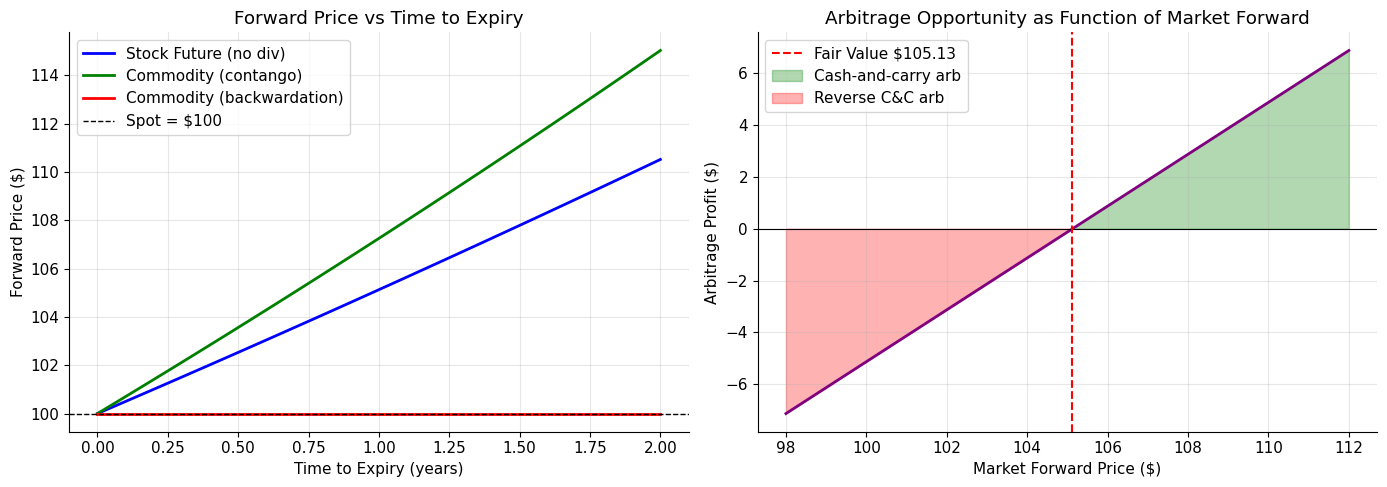


=== Q4: Cash-and-Carry Arbitrage ===
Fair forward: $105.13
Market forward: $108.00
Arbitrage profit: $2.87
Strategy: Borrow $100 → Buy spot → Sell forward at $108 → Profit $2.87


In [51]:
# Futures Pricing and Arbitrage
print("=== Q1: Forward Pricing ===")
S0, r, T = 100, 0.05, 1.0
F_fair = S0 * np.exp(r * T)
print(f"Spot: ${S0}, Rate: {r:.0%}, Time: {T}yr")
print(f"Fair Forward: ${F_fair:.2f}")

print("\n=== Q2: Forward with Dividend ===")
q = 0.02  # 2% continuous dividend yield
F_div = S0 * np.exp((r - q) * T)
print(f"With dividend yield q={q:.0%}: F = ${F_div:.2f}")

print("\n=== Q3: Commodity Futures ===")
u = 0.03  # storage cost
y_conv = 0.01  # convenience yield
F_commodity = S0 * np.exp((r + u - y_conv) * T)
print(f"With storage u={u:.0%}, convenience y={y_conv:.0%}: F = ${F_commodity:.2f}")
contango = F_commodity > S0
print(f"Market structure: {'Contango' if contango else 'Backwardation'}")

# Basis over time
T_range = np.linspace(0, 2, 100)
F_values = S0 * np.exp(r * T_range)
F_commodity_range = S0 * np.exp((r + u - y_conv) * T_range)
F_backwardation = S0 * np.exp((r + u - 0.08) * T_range)  # high convenience yield

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_range, F_values, 'b-', label='Stock Future (no div)', linewidth=2)
ax.plot(T_range, F_commodity_range, 'g-', label='Commodity (contango)', linewidth=2)
ax.plot(T_range, F_backwardation, 'r-', label='Commodity (backwardation)', linewidth=2)
ax.axhline(S0, color='black', linestyle='--', linewidth=1, label=f'Spot = ${S0}')
ax.set_xlabel('Time to Expiry (years)')
ax.set_ylabel('Forward Price ($)')
ax.set_title('Forward Price vs Time to Expiry')
ax.legend()

# Arbitrage profit sensitivity
F_market_range = np.linspace(98, 112, 100)
arbitrage_profit = F_market_range - F_fair
ax2 = axes[1]
ax2.plot(F_market_range, arbitrage_profit, 'purple', linewidth=2)
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax2.axvline(F_fair, color='red', linestyle='--', label=f'Fair Value ${F_fair:.2f}')
ax2.fill_between(F_market_range, arbitrage_profit, 0,
                 where=arbitrage_profit > 0, alpha=0.3, color='green', label='Cash-and-carry arb')
ax2.fill_between(F_market_range, arbitrage_profit, 0,
                 where=arbitrage_profit < 0, alpha=0.3, color='red', label='Reverse C&C arb')
ax2.set_xlabel('Market Forward Price ($)')
ax2.set_ylabel('Arbitrage Profit ($)')
ax2.set_title('Arbitrage Opportunity as Function of Market Forward')
ax2.legend()
plt.tight_layout()
plt.show()

print("\n=== Q4: Cash-and-Carry Arbitrage ===")
F_market = 108  # overpriced
arb_profit = F_market - F_fair
print(f"Fair forward: ${F_fair:.2f}")
print(f"Market forward: ${F_market:.2f}")
print(f"Arbitrage profit: ${arb_profit:.2f}")
print("Strategy: Borrow $100 → Buy spot → Sell forward at $108 → Profit $2.87")


---
<a id='section6'></a>
# Section 6: Options Trading 🎯

> **Why this matters:** Options are the most intellectually rich area in finance. Understanding payoffs, Greeks, and volatility is essential for derivatives roles and increasingly important for all trading positions.

---
## 6.1 Option Fundamentals

### Q1 [Easy] — Option Payoffs
**Interviewer asks:** *"What are the payoffs at expiry for a call and put option?"*

| Option | Long Payoff | Short Payoff |
|--------|-------------|--------------|
| Call | $\max(S_T - K, 0)$ | $-\max(S_T - K, 0)$ |
| Put | $\max(K - S_T, 0)$ | $-\max(K - S_T, 0)$ |

**PnL (long position):** Payoff minus premium paid
- Long call PnL = $\max(S_T - K, 0) - C$
- Long put PnL = $\max(K - S_T, 0) - P$

### Q2 [Medium] — Put-Call Parity
**Interviewer asks:** *"State and derive put-call parity."*

$$C - P = S_0 - K e^{-rT}$$

**Derivation (no-arbitrage):**
- Portfolio A: Long call + $Ke^{-rT}$ in cash
- Portfolio B: Long put + Long stock

At expiry $S_T > K$: A = $S_T - K + K = S_T$, B = $0 + S_T = S_T$ ✓  
At expiry $S_T < K$: A = $0 + K = K$, B = $K - S_T + S_T = K$ ✓

Both portfolios have same payoff → same price today!

**Trading application:** If parity breaks → arbitrage via synthetic positions.


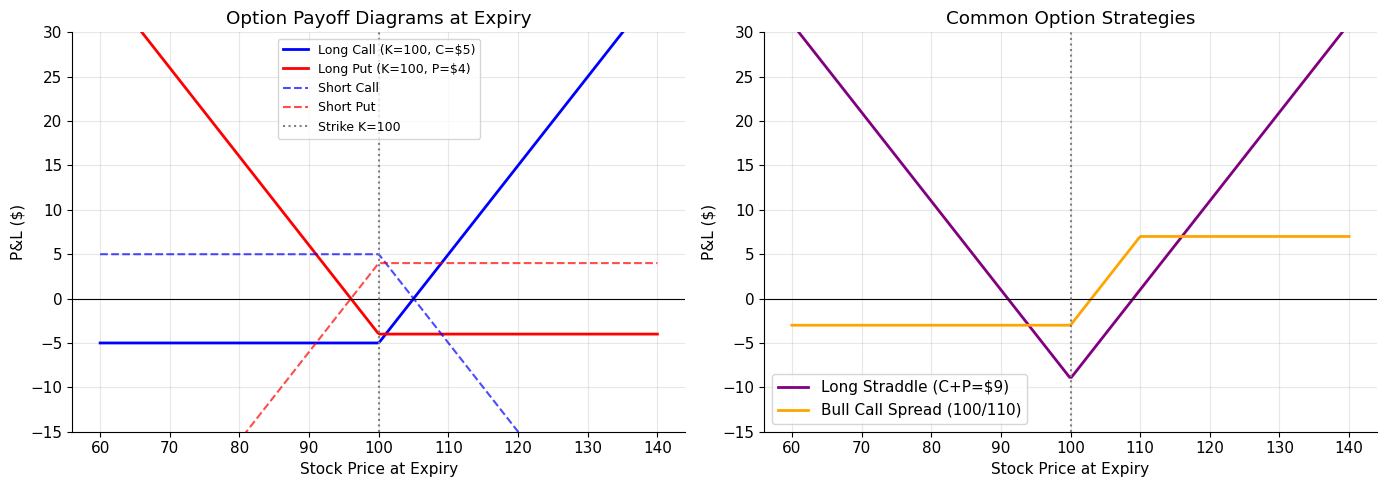

In [52]:
# Option Payoffs and Put-Call Parity
S_range = np.linspace(60, 140, 300)
K, C_prem, P_prem = 100, 5, 4

# Payoffs
payoff_long_call = np.maximum(S_range - K, 0) - C_prem
payoff_long_put = np.maximum(K - S_range, 0) - P_prem
payoff_short_call = -np.maximum(S_range - K, 0) + C_prem
payoff_short_put = -np.maximum(K - S_range, 0) + P_prem

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(S_range, payoff_long_call, 'b-', label=f'Long Call (K={K}, C=${C_prem})', linewidth=2)
ax.plot(S_range, payoff_long_put, 'r-', label=f'Long Put (K={K}, P=${P_prem})', linewidth=2)
ax.plot(S_range, payoff_short_call, 'b--', label='Short Call', linewidth=1.5, alpha=0.7)
ax.plot(S_range, payoff_short_put, 'r--', label='Short Put', linewidth=1.5, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(K, color='gray', linestyle=':', label=f'Strike K={K}')
ax.set_xlabel('Stock Price at Expiry')
ax.set_ylabel('P&L ($)')
ax.set_title('Option Payoff Diagrams at Expiry')
ax.legend(fontsize=9)
ax.set_ylim(-15, 30)

# Common strategies
long_straddle = payoff_long_call + (np.maximum(K - S_range, 0) - P_prem)
bull_spread = payoff_long_call - (np.maximum(S_range - 110, 0) - 2)
ax2 = axes[1]
ax2.plot(S_range, long_straddle, 'purple', label=f'Long Straddle (C+P=${C_prem+P_prem})', linewidth=2)
ax2.plot(S_range, bull_spread, 'orange', label='Bull Call Spread (100/110)', linewidth=2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(K, color='gray', linestyle=':')
ax2.set_xlabel('Stock Price at Expiry')
ax2.set_ylabel('P&L ($)')
ax2.set_title('Common Option Strategies')
ax2.legend()
ax2.set_ylim(-15, 30)
plt.tight_layout()
plt.show()


## 6.2 Black-Scholes Model

### Q3 [Hard] — Black-Scholes Derivation Intuition
**Interviewer asks:** *"Can you explain the intuition behind Black-Scholes?"*

---
**Key assumptions:**
- Stock follows geometric Brownian motion: $dS = \mu S dt + \sigma S dW$
- No arbitrage, continuous trading, frictionless markets
- Constant volatility, no dividends

**The PDE:**
$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0$$

**Intuition:** Delta-hedge to eliminate risk → risk-free position must earn risk-free rate → derive PDE → solve analytically.

**BS Formula:**
$$C = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T}$$

**Interpretation:**
- $\Phi(d_2)$ = risk-neutral probability option expires in the money
- $\Phi(d_1)$ = delta of the option
- $S_0\Phi(d_1)$ = expected cost of acquiring stock if exercised
- $Ke^{-rT}\Phi(d_2)$ = PV of strike payment if exercised


In [53]:
# Black-Scholes Implementation
def black_scholes(S, K, T, r, sigma, option_type='call'):
    '''Black-Scholes option pricing'''
    if T <= 0:
        if option_type == 'call':
            return max(S - K, 0)
        else:
            return max(K - S, 0)
    
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    if option_type == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    
    return price

def bs_greeks(S, K, T, r, sigma):
    '''Calculate all Greeks'''
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    delta_call = norm.cdf(d1)
    delta_put = delta_call - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100  # per 1% vol change
    theta_call = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
    theta_put = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
    rho_call = K*T*np.exp(-r*T)*norm.cdf(d2) / 100
    rho_put = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100
    
    return {
        'delta_call': delta_call, 'delta_put': delta_put,
        'gamma': gamma, 'vega': vega,
        'theta_call': theta_call, 'theta_put': theta_put,
        'rho_call': rho_call, 'rho_put': rho_put,
        'd1': d1, 'd2': d2
    }

# Example
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
C = black_scholes(S, K, T, r, sigma, 'call')
P = black_scholes(S, K, T, r, sigma, 'put')
greeks = bs_greeks(S, K, T, r, sigma)

print("=== Black-Scholes Pricing ===")
print(f"Parameters: S={S}, K={K}, T={T}yr, r={r:.0%}, σ={sigma:.0%}")
print(f"Call Price: ${C:.4f}")
print(f"Put Price:  ${P:.4f}")
print(f"Put-Call Parity check: C-P={C-P:.4f}, S-Ke^(-rT)={S-K*np.exp(-r*T):.4f}")
print(f"\n=== Greeks ===")
print(f"Delta (call): {greeks['delta_call']:.4f}")
print(f"Delta (put):  {greeks['delta_put']:.4f}")
print(f"Gamma:  {greeks['gamma']:.6f}")
print(f"Vega:   ${greeks['vega']:.4f} per 1% vol")
print(f"Theta:  ${greeks['theta_call']:.4f}/day")
print(f"Rho:    ${greeks['rho_call']:.4f} per 1% rate")


=== Black-Scholes Pricing ===
Parameters: S=100, K=100, T=1.0yr, r=5%, σ=20%
Call Price: $10.4506
Put Price:  $5.5735
Put-Call Parity check: C-P=4.8771, S-Ke^(-rT)=4.8771

=== Greeks ===
Delta (call): 0.6368
Delta (put):  -0.3632
Gamma:  0.018762
Vega:   $0.3752 per 1% vol
Theta:  $-0.0176/day
Rho:    $0.5323 per 1% rate


## 6.3 The Greeks in Detail

### Q4 — Delta
**Interviewer asks:** *"What is delta and how does it change?"*

$\Delta = \frac{\partial V}{\partial S} = \Phi(d_1)$ for calls

Key properties:
- Call delta: 0 to 1; Put delta: -1 to 0
- ATM options: delta ≈ 0.5 (call) or -0.5 (put)
- Deep ITM: delta → 1 (call) or -1 (put)
- Deep OTM: delta → 0

### Q5 — Gamma
**Interviewer asks:** *"What is gamma and why does a market maker care about it?"*

$\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\phi(d_1)}{S\sigma\sqrt{T}}$

- Gamma is highest for ATM options near expiry
- **Long gamma** = long volatility realized vs implied → gamma scalping
- **Short gamma** = collecting theta, exposed to large moves
- Market makers: gamma tells how often to rebalance hedge

### Q6 — Vega
**Interviewer asks:** *"Explain vega and how you'd trade it."*

$\mathcal{V} = S\phi(d_1)\sqrt{T}$

- All long options have positive vega (benefit from vol increase)
- Vega highest for ATM, long-dated options
- Volatility trading: buy vega when implied vol < realized; sell when expensive

### Q7 — Theta
**Interviewer asks:** *"What is the relationship between theta and gamma?"*

**Key relationship:**
$$\Theta + \frac{1}{2}\sigma^2 S^2 \Gamma + rS\Delta - rV = 0$$

$\Rightarrow \Theta \approx -\frac{1}{2}\sigma^2 S^2 \Gamma$

**Intuition:** Long gamma → short theta (pay for convexity). Short gamma → long theta (earn carry, bear risk).

"Long gamma is like insurance: you pay daily premium (theta) for protection against large moves."


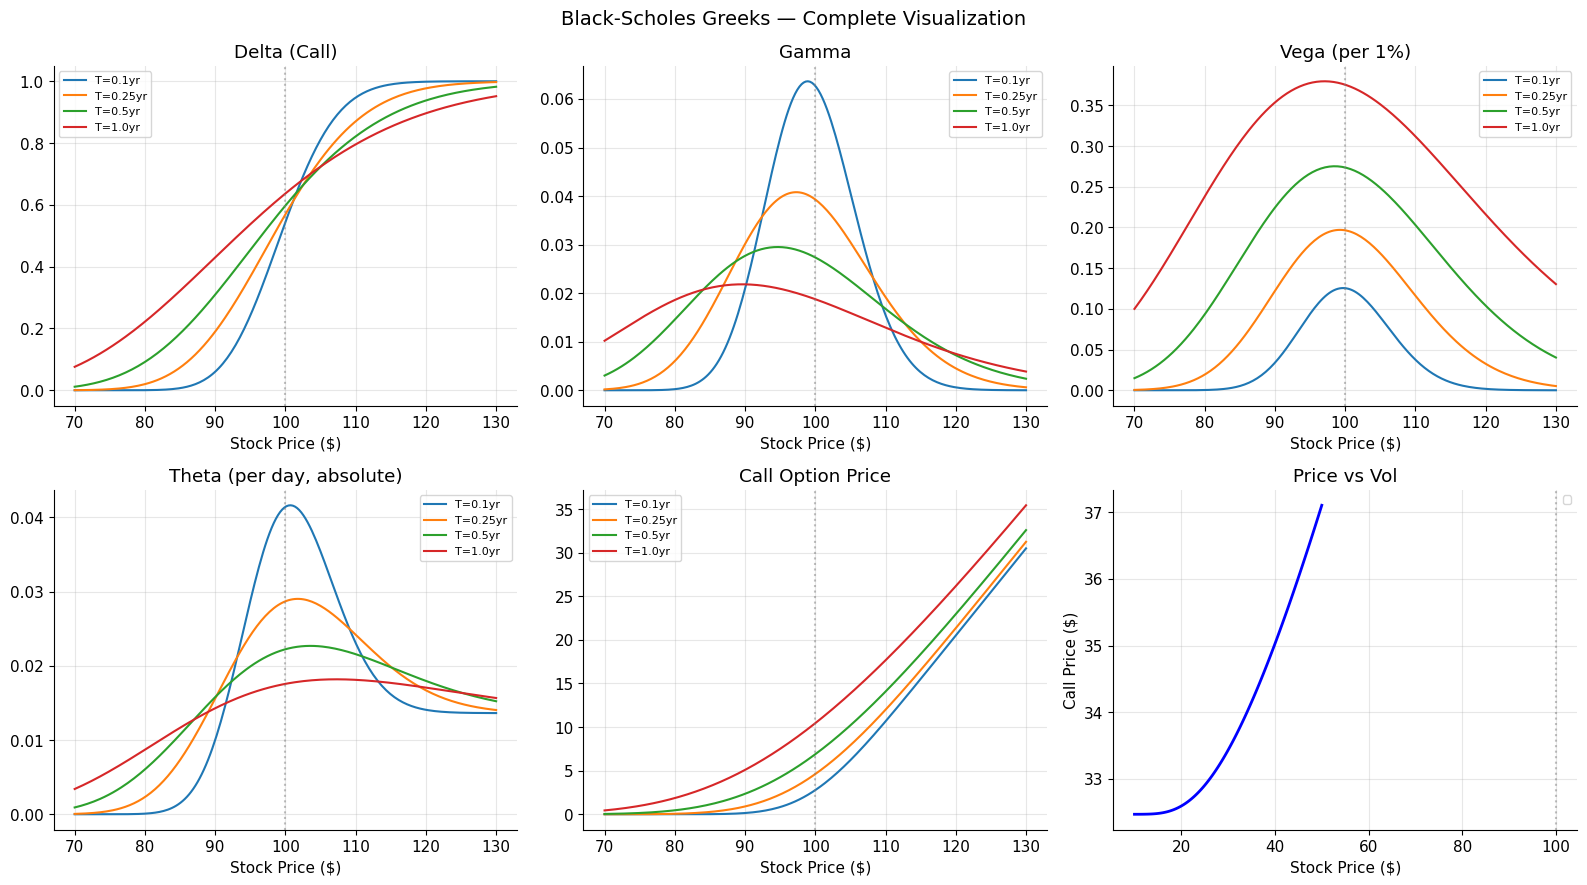

In [54]:
# Greeks Visualization
S_range = np.linspace(70, 130, 200)
T_values = [0.1, 0.25, 0.5, 1.0]
K, r, sigma = 100, 0.05, 0.20

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for T_val in T_values:
    deltas, gammas, vegas, thetas = [], [], [], []
    for S in S_range:
        g = bs_greeks(S, K, T_val, r, sigma)
        deltas.append(g['delta_call'])
        gammas.append(g['gamma'])
        vegas.append(g['vega'])
        thetas.append(-g['theta_call'])

    lbl = f'T={T_val}yr'
    axes[0,0].plot(S_range, deltas, label=lbl)
    axes[0,1].plot(S_range, gammas, label=lbl)
    axes[0,2].plot(S_range, vegas, label=lbl)
    axes[1,0].plot(S_range, thetas, label=lbl)

# Call prices
for T_val in T_values:
    prices = [black_scholes(S, K, T_val, r, sigma, 'call') for S in S_range]
    axes[1,1].plot(S_range, prices, label=f'T={T_val}yr')

# Implied vol surface (schematic)
sigma_range = np.linspace(0.10, 0.50, 100)
prices_vs_vol = [black_scholes(S, K, 0.5, r, sv, 'call') for sv in sigma_range]
axes[1,2].plot(sigma_range*100, prices_vs_vol, 'b-', linewidth=2)
axes[1,2].set_title('Call Price vs Implied Volatility')
axes[1,2].set_xlabel('Implied Volatility (%)')
axes[1,2].set_ylabel('Call Price ($)')

titles = ['Delta (Call)', 'Gamma', 'Vega (per 1%)', 'Theta (per day, absolute)', 
          'Call Option Price', 'Price vs Vol']
for ax, title in zip(axes.flat, titles):
    ax.axvline(K, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Stock Price ($)')
    ax.legend(fontsize=8)

plt.suptitle('Black-Scholes Greeks — Complete Visualization', fontsize=14)
plt.tight_layout()
plt.show()


## 6.4 Implied Volatility and Vol Surface

### Q8 [Hard] — Implied Volatility
**Interviewer asks:** *"What is implied volatility? How do you calculate it?"*

**Definition:** The volatility $\sigma$ that, when input into BS, gives the observed market price.

**Calculation:** Numerical root-finding (no closed form):
$$C_{market} = BS(S, K, T, r, \sigma_{imp})$$
Solve for $\sigma_{imp}$ using Newton-Raphson or bisection.

**Newton-Raphson update:** $\sigma_{n+1} = \sigma_n - \frac{C_{BS}(\sigma_n) - C_{market}}{\mathcal{V}(\sigma_n)}$

### Q9 [Hard] — Volatility Smile and Skew
**Interviewer asks:** *"What is the volatility smile and why does it exist?"*

**Empirical observation:** If BS were correct, IV would be flat across strikes. In reality:
- **Equity skew:** Lower strikes have higher IV (downside puts expensive)  
- **FX smile:** Both OTM puts and calls have higher IV than ATM
- **Commodity smile:** Various shapes depending on commodity

**Reasons for skew:**
1. **Crash risk / jump fear** — investors pay up for downside protection
2. **Leverage effect** — falling prices → rising vol in equities
3. **Supply/demand** — hedgers systematically buy downside puts
4. **Fat tails** — returns have heavier tails than normal

**Trading implication:** IV ≠ realized vol for all strikes → opportunities in overpriced/underpriced wings.


Market call price: $7.5
Implied volatility: 22.23%
Verification: BS price = $7.5000


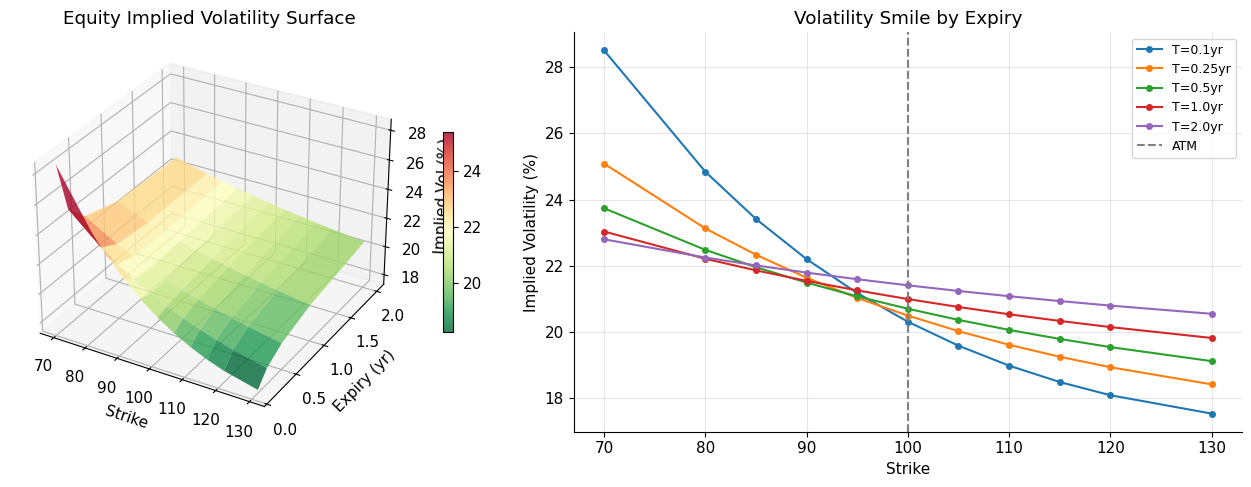

In [55]:
# Implied Volatility Calculation
def implied_vol(market_price, S, K, T, r, option_type='call', 
                tol=1e-6, max_iter=100):
    '''Newton-Raphson implied volatility solver'''
    sigma = 0.20  # initial guess
    for _ in range(max_iter):
        price = black_scholes(S, K, T, r, sigma, option_type)
        vega = bs_greeks(S, K, T, r, sigma)['vega'] * 100  # back to per unit vol
        
        if vega < 1e-10:
            break
        
        diff = price - market_price
        if abs(diff) < tol:
            return sigma
        sigma = sigma - diff / vega
        sigma = max(0.001, min(sigma, 10.0))  # bounds
    return sigma

# Test
market_call = 7.5  # observed market price
iv = implied_vol(market_call, S=100, K=100, T=0.5, r=0.05)
print(f"Market call price: ${market_call}")
print(f"Implied volatility: {iv:.2%}")
print(f"Verification: BS price = ${black_scholes(100, 100, 0.5, 0.05, iv):.4f}")

# Volatility Surface Simulation
strikes = np.array([70, 80, 85, 90, 95, 100, 105, 110, 115, 120, 130])
expiries = np.array([0.1, 0.25, 0.5, 1.0, 2.0])

# Simulate realistic equity vol surface (negative skew + term structure)
def vol_surface(K, T, S=100, atm_vol=0.20):
    moneyness = np.log(K/S) / np.sqrt(T)
    skew = -0.05 * moneyness       # negative skew
    smile = 0.02 * moneyness**2    # smile
    term = 0.01 * np.sqrt(T)       # upward term structure
    return atm_vol + skew + smile + term

K_grid, T_grid = np.meshgrid(strikes, expiries)
vol_grid = vol_surface(K_grid, T_grid)

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(K_grid, T_grid, vol_grid*100, cmap='RdYlGn_r', alpha=0.8)
ax1.set_xlabel('Strike')
ax1.set_ylabel('Expiry (yr)')
ax1.set_zlabel('Implied Vol (%)')
ax1.set_title('Equity Implied Volatility Surface')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# 2D smile per expiry
ax2 = fig.add_subplot(122)
for T_val in expiries:
    vols = [vol_surface(k, T_val)*100 for k in strikes]
    ax2.plot(strikes, vols, '-o', label=f'T={T_val}yr', markersize=4)
ax2.axvline(100, color='gray', linestyle='--', label='ATM')
ax2.set_xlabel('Strike')
ax2.set_ylabel('Implied Volatility (%)')
ax2.set_title('Volatility Smile by Expiry')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 6.5 Gamma Scalping & Volatility Trading

### Q10 [Senior Level] — Gamma Scalping
**Interviewer asks:** *"Explain gamma scalping. Under what conditions is it profitable?"*

---
**Setup:** Buy ATM straddle (long gamma, long vega, short theta)

**Daily hedge:** Delta-hedge by trading the underlying to stay delta-neutral

**P&L decomposition:**
$$dV \approx \Delta \cdot dS + \frac{1}{2}\Gamma (dS)^2 + \Theta \cdot dt$$

After delta-hedging ($\Delta \cdot dS$ term removed):
$$\text{Daily PnL} \approx \frac{1}{2}\Gamma S^2 \left[(\sigma_{realized})^2 - (\sigma_{implied})^2\right] dt$$

**Profitable when:** Realized vol > Implied vol (you bought cheap options)

**Break-even volatility:** The realized vol needed to break even equals implied vol

**Key insight:** Gamma scalping is essentially a bet on realized vol vs implied vol (variance spread trade).


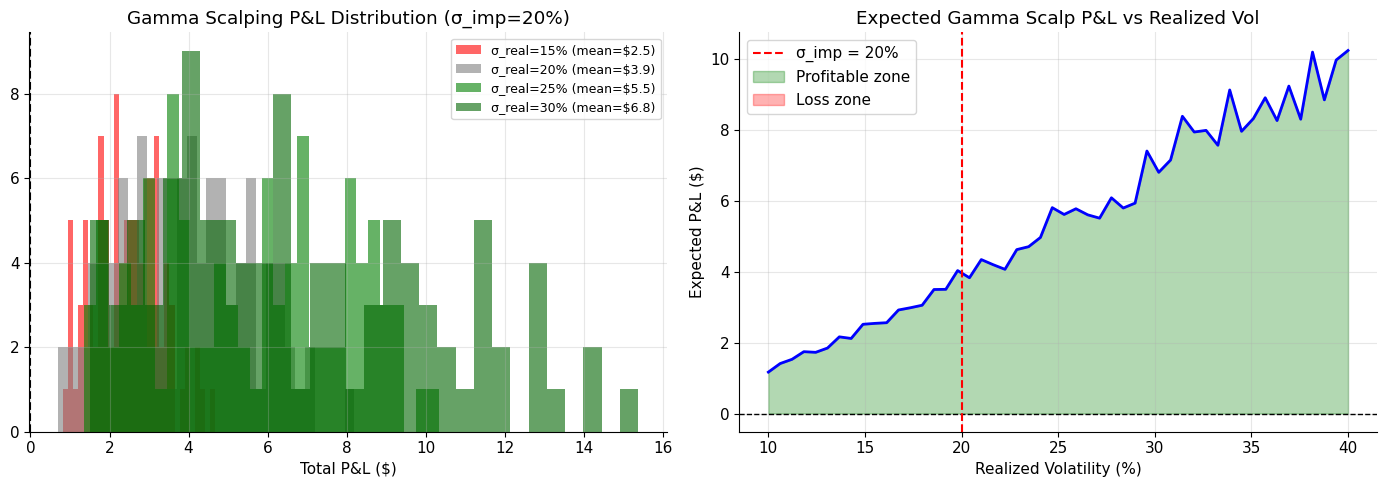

In [56]:
# Gamma Scalping Simulation
np.random.seed(42)

def simulate_gamma_scalp(S0, K, T, r, sigma_imp, sigma_realized, n_days=252):
    '''Simulate gamma scalping P&L'''
    dt = T / n_days
    S = S0
    C = black_scholes(S0, K, T, r, sigma_imp, 'call')
    pnl_daily = []
    
    for t in range(n_days):
        T_remaining = T - t*dt
        if T_remaining <= 0:
            break
        
        # Current delta and gamma
        g = bs_greeks(S, K, T_remaining, r, sigma_imp)
        delta = g['delta_call']
        gamma = g['gamma']
        theta = g['theta_call']
        
        # Stock move
        dS = S * (r*dt + sigma_realized * np.sqrt(dt) * np.random.randn())
        
        # Gamma P&L
        gamma_pnl = 0.5 * gamma * dS**2
        # Theta cost
        theta_cost = theta * dt
        
        daily_pnl = gamma_pnl + theta_cost
        pnl_daily.append(daily_pnl)
        
        S += dS
    
    return np.array(pnl_daily), S

# Test: realized vol = 25%, implied = 20% (favorable)
S0, K = 100, 100
T, r = 1.0, 0.05
sigma_imp = 0.20

n_sim = 100
results = {}
for sig_real in [0.15, 0.20, 0.25, 0.30]:
    total_pnls = []
    for _ in range(n_sim):
        pnl, _ = simulate_gamma_scalp(S0, K, T, r, sigma_imp, sig_real)
        total_pnls.append(sum(pnl))
    results[sig_real] = total_pnls

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['red', 'gray', 'green', 'darkgreen']
for (sig_real, pnls), color in zip(results.items(), colors):
    ax.hist(pnls, bins=30, alpha=0.6, color=color, 
            label=f'σ_real={sig_real:.0%} (mean=${np.mean(pnls):.1f})')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Total P&L ($)')
ax.set_title(f'Gamma Scalping P&L Distribution (σ_imp={sigma_imp:.0%})')
ax.legend(fontsize=9)

ax2 = axes[1]
sig_reals = np.linspace(0.10, 0.40, 50)
mean_pnls = [np.mean([sum(simulate_gamma_scalp(S0, K, T, r, sigma_imp, s)[0]) for _ in range(50)]) 
             for s in sig_reals]
ax2.plot(sig_reals*100, mean_pnls, 'b-', linewidth=2)
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.axvline(sigma_imp*100, color='red', linestyle='--', label=f'σ_imp = {sigma_imp:.0%}')
ax2.fill_between(sig_reals*100, mean_pnls, 0,
                 where=np.array(mean_pnls) > 0, alpha=0.3, color='green', label='Profitable zone')
ax2.fill_between(sig_reals*100, mean_pnls, 0,
                 where=np.array(mean_pnls) < 0, alpha=0.3, color='red', label='Loss zone')
ax2.set_xlabel('Realized Volatility (%)')
ax2.set_ylabel('Expected P&L ($)')
ax2.set_title('Expected Gamma Scalp P&L vs Realized Vol')
ax2.legend()
plt.tight_layout()
plt.show()


---
<a id='section7'></a>
# Section 7: Derivatives & Structured Products 🔧

## 7.1 Interest Rate Swaps

### Q1 — Swap Pricing
**Interviewer asks:** *"How does an interest rate swap work? How do you price it?"*

**Structure:** Party A pays fixed rate $c$; Party B pays floating (SOFR/LIBOR + spread)

**Pricing:** Value to fixed-rate payer:
$$V_{swap} = B_{float} - B_{fixed}$$

At inception, set $c$ so $V_{swap} = 0$:
$$c = \frac{1 - P(0,T)}{\sum_{i=1}^T P(0,t_i)}$$

where $P(0,t)$ are discount factors (zero coupon bond prices).

### Q2 — Credit Default Swap (CDS)
**Interviewer asks:** *"Explain how a CDS works and how you'd use it."*

**Structure:**
- Protection buyer: pays periodic spread $s$ (CDS spread)
- Protection seller: pays face value upon default

**CDS spread:** $s \approx (1-R) \times \lambda$ where $R$ = recovery rate, $\lambda$ = default intensity

**Uses:**
1. Hedge credit exposure in bond portfolio
2. Speculate on credit quality
3. Create synthetic bond positions

### Q3 — Variance Swaps
**Interviewer asks:** *"What is a variance swap? How does it differ from a vol swap?"*

**Variance swap payoff:** $N \times (\sigma^2_{realized} - K_{var})$

**Key:** Variance swap can be replicated with a portfolio of options (log contract)

**Variance vs Vol swap:**
- Variance swap: payoff on $\sigma^2$ (convex in vol → positive value)
- Vol swap: payoff on $\sigma$ (linear in vol → no convexity adjustment needed)

**VIX:** $VIX^2 \approx E^Q[\sigma^2_{realized}]$ = fair strike of variance swap


=== 5-Year IRS Fair Rate ===
Par swap rate: 5.525%


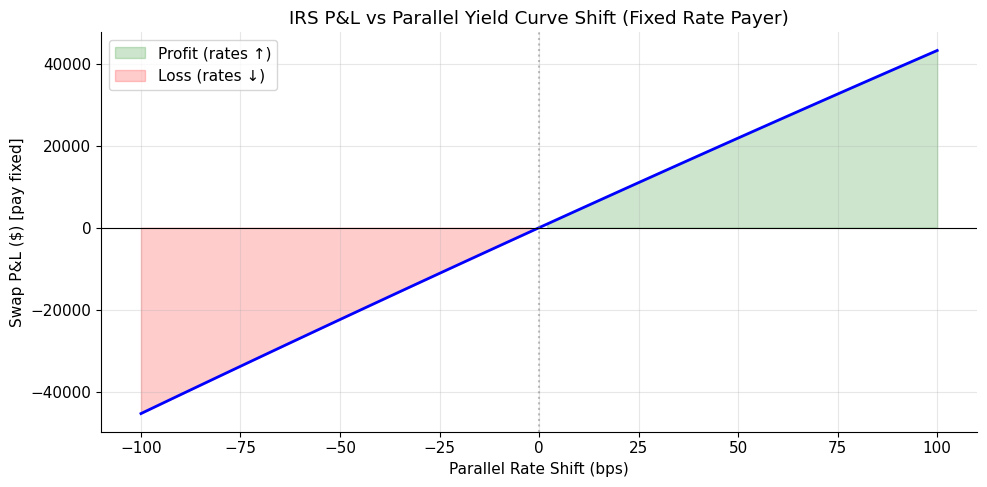

In [57]:
# Interest Rate Swap Pricing
def swap_fair_rate(discount_factors, payment_times):
    '''Calculate fair fixed rate for IRS'''
    # Numerator: 1 - last discount factor
    # Denominator: sum of discount factors * payment intervals
    dt = np.diff([0] + list(payment_times))
    fair_rate = (1 - discount_factors[-1]) / np.sum(discount_factors * dt)
    return fair_rate

# Example: 5-year semi-annual IRS
spot_rates = np.array([0.04, 0.044, 0.047, 0.049, 0.050,
                        0.051, 0.052, 0.053, 0.054, 0.055])  # 6m rates
payment_times = np.arange(0.5, 5.5, 0.5)
discount_factors = np.exp(-spot_rates * payment_times)

fair_rate = swap_fair_rate(discount_factors, payment_times)
print(f"=== 5-Year IRS Fair Rate ===")
print(f"Par swap rate: {fair_rate*100:.3f}%")

# Swap value if rates move
def swap_value(spot_rates_new, fixed_rate, payment_times, notional=1000000):
    disc = np.exp(-spot_rates_new * payment_times)
    float_val = notional * (1 - disc[-1])  # approx floating leg
    dt = np.diff([0] + list(payment_times))
    fixed_val = notional * fixed_rate * np.sum(disc * dt)
    return float_val - fixed_val  # value to fixed payer

# Swap P&L if parallel shift
shifts_bp = np.linspace(-100, 100, 50)
pnl_swap = [swap_value(spot_rates + s/10000, fair_rate, payment_times) 
            for s in shifts_bp]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(shifts_bp, pnl_swap, 'b-', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Parallel Rate Shift (bps)')
ax.set_ylabel('Swap P&L ($) [pay fixed]')
ax.set_title('IRS P&L vs Parallel Yield Curve Shift (Fixed Rate Payer)')
ax.fill_between(shifts_bp, pnl_swap, 0, where=np.array(pnl_swap)>0, 
                alpha=0.2, color='green', label='Profit (rates ↑)')
ax.fill_between(shifts_bp, pnl_swap, 0, where=np.array(pnl_swap)<0, 
                alpha=0.2, color='red', label='Loss (rates ↓)')
ax.legend()
plt.tight_layout()
plt.show()


---
<a id='section8'></a>
# Section 8: Market Microstructure 🏛️

> **Why this matters:** Understanding how markets function at the microstructure level is essential for execution, HFT, and prop trading. Spreads, order flow, and adverse selection are core concepts.

---

### Q1 — Bid-Ask Spread Components
**Interviewer asks:** *"What determines the bid-ask spread? Break it down into components."*

---
**Glosten-Milgrom decomposition:**
$$Spread = \text{Adverse Selection} + \text{Inventory} + \text{Order Processing}$$

1. **Adverse selection (information component):** Market maker loses to informed traders who know more about true value
2. **Inventory cost:** Market maker bears risk from holding net positions  
3. **Order processing:** Fixed costs of running a market-making operation

**Trading implication:** Wider spreads on:
- High information asymmetry assets (earnings, biotech)
- Illiquid assets (high inventory cost)
- Volatile periods

### Q2 — Order Book Dynamics
**Interviewer asks:** *"How does an order book work? What is market impact?"*

**Order types:**
| Type | Description | Tradeoff |
|------|-------------|---------|
| Market order | Execute immediately at best price | Certainty of execution, uncertain price |
| Limit order | Specify max/min price | Certain price, uncertain fill |
| IOC | Immediate or cancel | Partial fills ok |
| FOK | Fill or kill | All-or-nothing |

**Market impact:** Price movement caused by trading

$\Delta P \approx \sigma \sqrt{\frac{Q}{V_{daily}}}$ (square-root law)

### Q3 — Adverse Selection
**Interviewer asks:** *"What is adverse selection in market making? How do you quantify it?"*

**Intuition:** If you're the slowest trader, you're the sucker. Informed traders pick off your quotes.

**VPIN (Volume-synchronized PIN):**
$$VPIN = \frac{|V_{buy} - V_{sell}|}{V_{total}}$$

High VPIN → toxic flow → widen spread or stop quoting

### Q4 — Market Making Strategy
**Interviewer asks:** *"How does a market maker make money?"*

**Revenue:** Earn the spread on every round-trip trade
**Risk:** Adverse selection + inventory accumulation

**Avellaneda-Stoikov model:**
Optimal quotes depend on:
1. Current inventory $q$
2. Risk aversion $\gamma$  
3. Market volatility $\sigma$
4. Reference spread $s_0$

$$p^{ask} = p^{mid} + \frac{s}{2} + \gamma \sigma^2 (q + \frac{1}{2})$$
$$p^{bid} = p^{mid} - \frac{s}{2} + \gamma \sigma^2 (q - \frac{1}{2})$$


=== Order Book Snapshot ===
ASK Side:
  $100.05:   221 shares
  $100.04:   120 shares
  $100.03:   171 shares
  $100.02:   370 shares
  $100.01:   535 shares
  --- BID-ASK SPREAD: 2.000000000001023bps ---
BID Side:
  $99.99:   202 shares
  $99.98:   960 shares
  $99.97:   206 shares
  $99.96:   800 shares
  $99.95:   714 shares

=== Square Root Market Impact ===
Trade   1,000 shares: impact ≈ 0.040%
Trade   5,000 shares: impact ≈ 0.089%
Trade  10,000 shares: impact ≈ 0.126%
Trade  50,000 shares: impact ≈ 0.282%
Trade 100,000 shares: impact ≈ 0.398%
Trade 200,000 shares: impact ≈ 0.563%


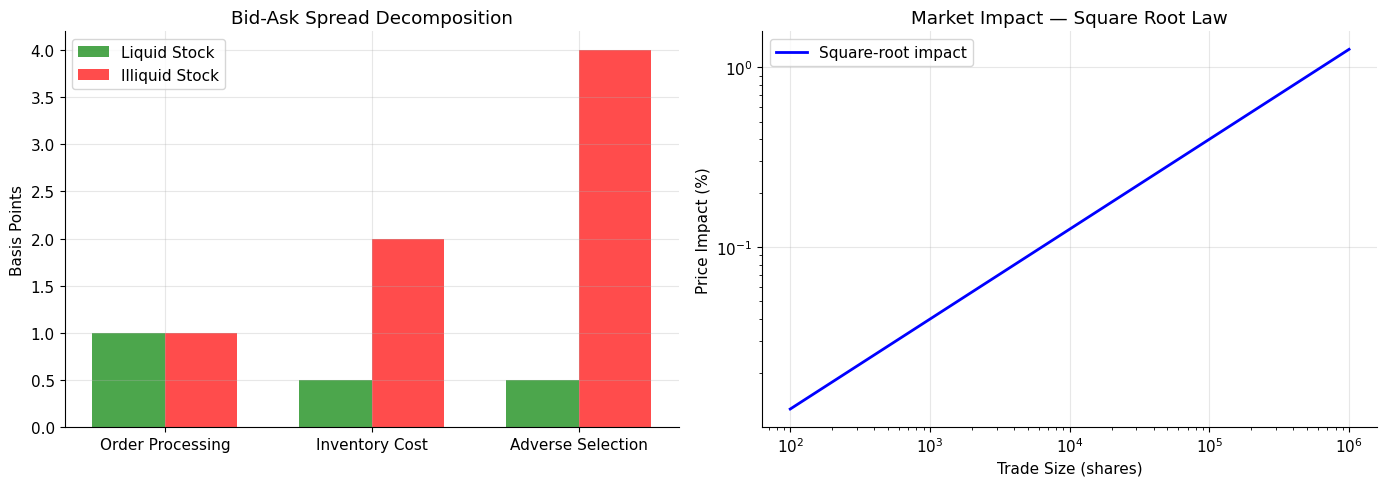

In [58]:
# Market Microstructure Simulations
np.random.seed(42)

# Order Book Simulation
class OrderBook:
    def __init__(self):
        self.bids = {}  # price: quantity
        self.asks = {}
    
    def add_limit_order(self, side, price, qty):
        if side == 'bid':
            self.bids[price] = self.bids.get(price, 0) + qty
        else:
            self.asks[price] = self.asks.get(price, 0) + qty
    
    def best_bid(self):
        return max(self.bids.keys()) if self.bids else None
    
    def best_ask(self):
        return min(self.asks.keys()) if self.asks else None
    
    def spread(self):
        bb = self.best_bid()
        ba = self.best_ask()
        if bb and ba:
            return ba - bb
        return None

# Build a sample order book
ob = OrderBook()
mid = 100.00
for i in range(1, 6):
    ob.add_limit_order('bid', mid - i*0.01, np.random.randint(100, 1000))
    ob.add_limit_order('ask', mid + i*0.01, np.random.randint(100, 1000))

print("=== Order Book Snapshot ===")
print("ASK Side:")
for price in sorted(ob.asks.keys(), reverse=True):
    print(f"  ${price:.2f}: {ob.asks[price]:5d} shares")
print(f"  {'--- BID-ASK SPREAD: ' + str(ob.spread()*100) + 'bps ---':^35}")
print("BID Side:")
for price in sorted(ob.bids.keys(), reverse=True):
    print(f"  ${price:.2f}: {ob.bids[price]:5d} shares")

# Market Impact Simulation
print("\n=== Square Root Market Impact ===")
daily_vol = 1_000_000  # shares
trade_sizes = [1000, 5000, 10000, 50000, 100000, 200000]
stock_vol = 0.20 / np.sqrt(252)  # daily vol

for size in trade_sizes:
    impact_pct = stock_vol * np.sqrt(size / daily_vol) * 100
    print(f"Trade {size:7,} shares: impact ≈ {impact_pct:.3f}%")

# Visualize spread vs volume (adverse selection)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spread components
categories = ['Order Processing', 'Inventory Cost', 'Adverse Selection']
liquid = [1, 0.5, 0.5]
illiquid = [1, 2, 4]
x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, liquid, width, label='Liquid Stock', color='green', alpha=0.7)
axes[0].bar(x + width/2, illiquid, width, label='Illiquid Stock', color='red', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Basis Points')
axes[0].set_title('Bid-Ask Spread Decomposition')
axes[0].legend()

# Market impact: square root law
sizes = np.logspace(2, 6, 100)
impacts = stock_vol * np.sqrt(sizes / daily_vol) * 100
axes[1].loglog(sizes, impacts, 'b-', linewidth=2, label='Square-root impact')
axes[1].set_xlabel('Trade Size (shares)')
axes[1].set_ylabel('Price Impact (%)')
axes[1].set_title('Market Impact — Square Root Law')
axes[1].legend()
plt.tight_layout()
plt.show()


---
<a id='section9'></a>
# Section 9: Equities 📈

### Q1 — Equity Valuation Multiples
**Interviewer asks:** *"Walk me through the main equity valuation metrics and their uses."*

| Metric | Formula | What it measures | Limitation |
|--------|---------|-----------------|-----------|
| P/E | Price / EPS | Earnings multiple | Ignores capital structure |
| EV/EBITDA | Enterprise Value / EBITDA | Operations | Ignores capex, D&A |
| P/B | Price / Book Value | Asset value | Irrelevant for asset-light |
| EV/FCF | EV / Free Cash Flow | Cash generation | FCF can be manipulated |

### Q2 — DCF Intuition
**Interviewer asks:** *"Walk me through a DCF."*

$$V = \sum_{t=1}^T \frac{FCF_t}{(1+WACC)^t} + \frac{TV}{(1+WACC)^T}$$

Terminal value: $TV = \frac{FCF_T(1+g)}{WACC - g}$

**Key insight:** Most of the value is in the terminal value (often 60-80%!) → highly sensitive to WACC and growth assumptions.

### Q3 — Share Buybacks vs Dividends
**Interview question:** *"When should a company buy back stock vs pay dividends?"*

**Buybacks are preferred when:**
1. Management believes stock is undervalued
2. More tax-efficient in some jurisdictions
3. Flexible (can be cancelled)
4. Accretive if P/E < EPS growth funded

**Dividends preferred when:**
1. Signaling stable, mature cash flows
2. Investor base expects income
3. Reduces agency problem (forces capital discipline)


=== DCF Valuation ($M) ===
Year 1 FCF PV: $104.5M
Year 2 FCF PV: $109.3M
Year 3 FCF PV: $114.3M
Year 4 FCF PV: $119.5M
Year 5 FCF PV: $124.9M
Terminal Value PV: $1837.7M (76% of EV)
Enterprise Value: $2410.1M
Equity Value: $2260.1M


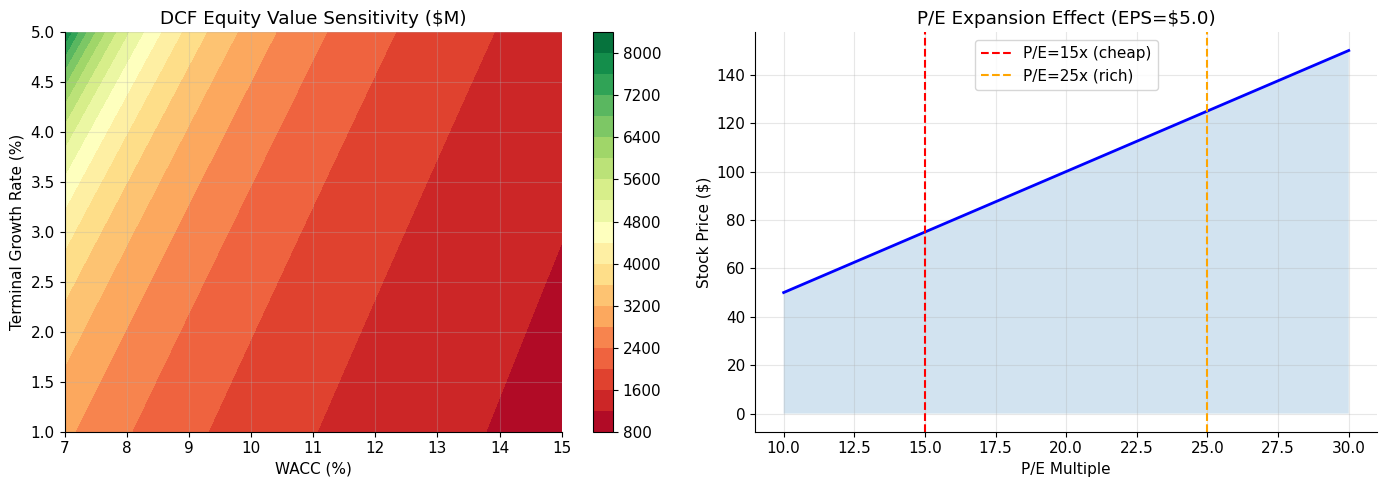

In [59]:
# DCF Valuation
def dcf_value(fcf_base, growth_rate_high, growth_years, 
              growth_rate_terminal, wacc, debt, cash):
    '''
    DCF valuation model
    Returns: Equity Value, breakdown
    '''
    fcfs = []
    for t in range(1, growth_years + 1):
        fcf = fcf_base * (1 + growth_rate_high)**t
        fcfs.append(fcf)
    
    # Terminal value
    tv = fcfs[-1] * (1 + growth_rate_terminal) / (wacc - growth_rate_terminal)
    
    # Discount all cash flows
    discount_factors = [(1+wacc)**(-t) for t in range(1, growth_years+1)]
    pv_fcfs = [fcf * df for fcf, df in zip(fcfs, discount_factors)]
    pv_tv = tv * (1+wacc)**(-growth_years)
    
    enterprise_value = sum(pv_fcfs) + pv_tv
    equity_value = enterprise_value - debt + cash
    
    return {
        'pv_fcfs': pv_fcfs, 'pv_tv': pv_tv,
        'enterprise_value': enterprise_value,
        'equity_value': equity_value,
        'tv_pct': pv_tv/enterprise_value*100
    }

result = dcf_value(
    fcf_base=100,   # $100M current FCF
    growth_rate_high=0.15,  # 15% for 5 years
    growth_years=5,
    growth_rate_terminal=0.03,  # 3% terminal growth
    wacc=0.10,
    debt=200, cash=50
)

print("=== DCF Valuation ($M) ===")
for t, pv in enumerate(result['pv_fcfs'], 1):
    print(f"Year {t} FCF PV: ${pv:.1f}M")
print(f"Terminal Value PV: ${result['pv_tv']:.1f}M ({result['tv_pct']:.0f}% of EV)")
print(f"Enterprise Value: ${result['enterprise_value']:.1f}M")
print(f"Equity Value: ${result['equity_value']:.1f}M")

# WACC sensitivity on equity value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

waccs = np.linspace(0.07, 0.15, 50)
g_terminals = np.linspace(0.01, 0.05, 50)

ev_grid = np.zeros((len(g_terminals), len(waccs)))
for i, g in enumerate(g_terminals):
    for j, w in enumerate(waccs):
        if w > g:
            r = dcf_value(100, 0.15, 5, g, w, 200, 50)
            ev_grid[i,j] = r['equity_value']

im = axes[0].contourf(waccs*100, g_terminals*100, ev_grid, levels=20, cmap='RdYlGn')
axes[0].set_xlabel('WACC (%)')
axes[0].set_ylabel('Terminal Growth Rate (%)')
axes[0].set_title('DCF Equity Value Sensitivity (\$M)')
plt.colorbar(im, ax=axes[0])

# P/E expansion
pe_mult = np.linspace(10, 30, 100)
eps = 5.0
stock_prices = pe_mult * eps
axes[1].plot(pe_mult, stock_prices, 'b-', linewidth=2)
axes[1].fill_between(pe_mult, stock_prices, alpha=0.2)
axes[1].axvline(15, color='red', linestyle='--', label='P/E=15x (cheap)')
axes[1].axvline(25, color='orange', linestyle='--', label='P/E=25x (rich)')
axes[1].set_xlabel('P/E Multiple')
axes[1].set_ylabel('Stock Price ($)')
axes[1].set_title(f'P/E Expansion Effect (EPS=${eps})')
axes[1].legend()
plt.tight_layout()
plt.show()


---
<a id='section10'></a>
# Section 10: Risk Management ⚠️

> **Why this matters:** "How you manage risk determines whether you survive long enough to let your edge play out." — Every senior trader.

---
## 10.1 Value at Risk

### Q1 [Medium] — VaR Definition
**Interviewer asks:** *"What is Value at Risk? What are its limitations?"*

**Definition:** VaR at confidence level $\alpha$ is the maximum loss not exceeded with probability $\alpha$ over a given time horizon.

$P(L > VaR_{\alpha}) = 1 - \alpha$

**Methods:**
1. **Historical simulation:** Use actual historical returns
2. **Parametric (delta-normal):** Assume normal returns, $VaR = \mu + z_{\alpha} \sigma$
3. **Monte Carlo:** Simulate many scenarios

**Limitations (critical interview topic):**
1. Doesn't capture tail events beyond the threshold
2. Assumes distributions stable through time
3. Breaks down in crisis periods precisely when it matters most
4. **Not sub-additive** (portfolio VaR can exceed sum of individual VaRs)
5. Can create perverse incentives (manage to VaR limit)

### Q2 [Hard] — Expected Shortfall (CVaR)
**Interviewer asks:** *"What is Expected Shortfall and why is it preferred over VaR?"*

$$ES_{\alpha} = E[L | L > VaR_{\alpha}] = \frac{1}{1-\alpha} \int_{\alpha}^1 VaR_u \, du$$

**Advantages over VaR:**
1. Captures tail risk (average loss in worst cases)
2. **Sub-additive** — portfolio ES ≤ sum of component ES (encourages diversification)
3. Now required by Basel III/FRTB


=== VaR and Expected Shortfall ===
  Confidence   Normal VaR    Normal ES   Fat-tail VaR  Fat-tail ES
         90%      1.196%      1.611%        2.290%      3.551%
         95%      1.476%      1.877%        3.061%      4.430%
         99%      2.032%      2.444%        4.931%      6.725%


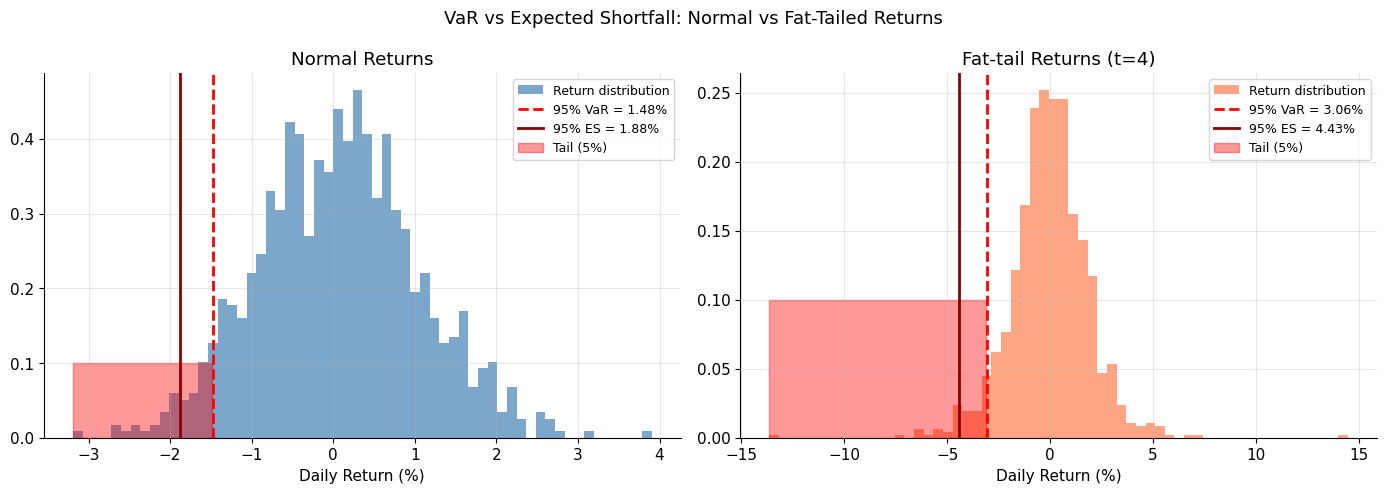

In [60]:
# VaR and Expected Shortfall
np.random.seed(42)

# Historical returns (fat-tailed)
n = 1000
normal_returns = np.random.normal(0.0005, 0.01, n)
# Add fat tails with t-distribution
t_returns = np.random.standard_t(4, n) * 0.01 * np.sqrt(2)  # rescale to same vol

def calculate_var_es(returns, confidence=0.95):
    sorted_returns = np.sort(returns)
    var_idx = int((1 - confidence) * len(sorted_returns))
    var = -sorted_returns[var_idx]
    es = -np.mean(sorted_returns[:var_idx])
    return var, es

confidence_levels = [0.90, 0.95, 0.99]

print("=== VaR and Expected Shortfall ===")
print(f"{'Confidence':>12} {'Normal VaR':>12} {'Normal ES':>12} {'Fat-tail VaR':>14} {'Fat-tail ES':>12}")
for conf in confidence_levels:
    var_n, es_n = calculate_var_es(normal_returns, conf)
    var_t, es_t = calculate_var_es(t_returns, conf)
    print(f"{conf:>12.0%} {var_n:>11.3%} {es_n:>11.3%} {var_t:>13.3%} {es_t:>11.3%}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conf = 0.95

for ax, (returns, name, color) in zip(axes, 
    [(normal_returns, 'Normal Returns', 'steelblue'), 
     (t_returns, 'Fat-tail Returns (t=4)', 'coral')]):
    
    var, es = calculate_var_es(returns, conf)
    
    ax.hist(returns*100, bins=60, density=True, alpha=0.7, color=color, label='Return distribution')
    ax.axvline(-var*100, color='red', linewidth=2, linestyle='--', label=f'95% VaR = {var:.2%}')
    ax.axvline(-es*100, color='darkred', linewidth=2, linestyle='-', label=f'95% ES = {es:.2%}')
    ax.fill_between(np.sort(returns*100), 0, 
                    [max(v, 0) for v in np.ones(n)*0.1],
                    where=np.sort(returns*100) < -var*100, 
                    alpha=0.4, color='red', label='Tail (5%)')
    ax.set_xlabel('Daily Return (%)')
    ax.set_title(f'{name}')
    ax.legend(fontsize=9)

plt.suptitle('VaR vs Expected Shortfall: Normal vs Fat-Tailed Returns', fontsize=13)
plt.tight_layout()
plt.show()


## 10.2 Portfolio Risk & Kelly Criterion

### Q3 [Hard] — Maximum Drawdown
**Interviewer asks:** *"What is maximum drawdown and how do you think about it in strategy evaluation?"*

$$MDD = \max_{t \in [0,T]} \left[\max_{s \leq t} W_s - W_t\right]$$

**Calmar Ratio:** $\frac{\text{Annual Return}}{\text{Max Drawdown}}$ — risk-adjusted return metric favored by traders

**Typical targets:** Sharpe > 1.0, Calmar > 0.5

### Q4 [Hard] — Kelly Criterion for Multiple Bets

**Multi-asset Kelly:**
$$f^* = \Sigma^{-1} \mu$$

Where $\mu$ = vector of expected returns, $\Sigma$ = covariance matrix

**Half-Kelly:** In practice, most traders use half-Kelly to account for:
1. Parameter estimation error
2. Non-stationarity
3. Fat tails
4. Psychological comfort

### Q5 — Position Sizing Under Uncertainty
**Interviewer asks:** *"If your signal has a 0.2 IC, how do you size the trade?"*

**Information Coefficient (IC):** Correlation between predicted and realized returns

**Grinold's Fundamental Law:**
$$IR = IC \times \sqrt{Breadth}$$

**Position size proportional to:** $IC \times \sigma_{asset} \times \frac{target\ IR}{\sigma_{portfolio}}$


=== Strategy Risk Metrics ===
Annual Return: 26.01%
Annual Vol:    18.64%
Sharpe Ratio:  1.29
Max Drawdown:  -19.65%
Calmar Ratio:  1.32


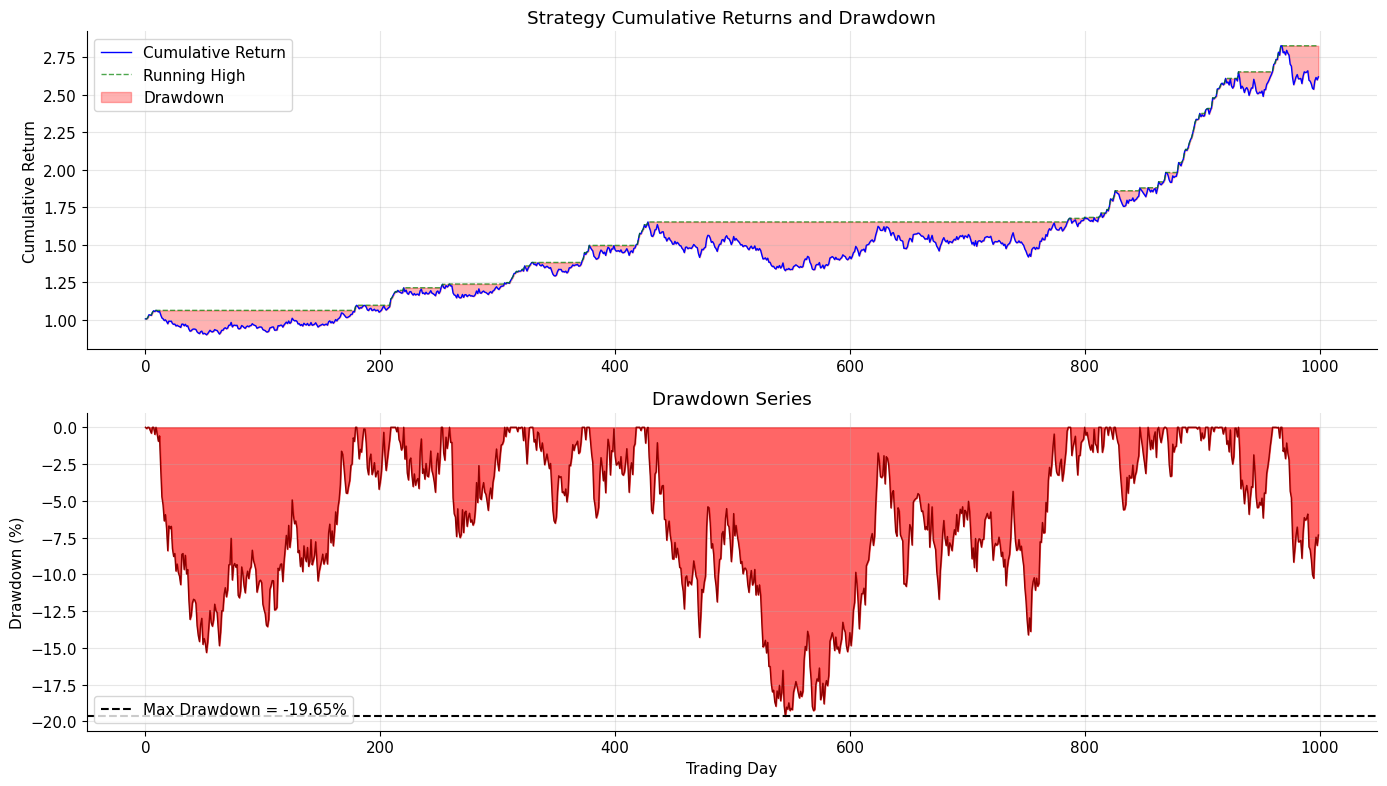

In [61]:
# Maximum Drawdown and Risk Metrics
def max_drawdown(returns):
    cumulative = (1 + np.array(returns)).cumprod()
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    return drawdown.min(), drawdown

def calmar_ratio(returns, periods_per_year=252):
    annual_ret = np.mean(returns) * periods_per_year
    mdd, _ = max_drawdown(returns)
    return annual_ret / abs(mdd)

# Simulate strategy
np.random.seed(42)
strategy_returns = np.random.normal(0.0008, 0.012, 1000)  # positive drift, 12% vol

mdd, drawdown_series = max_drawdown(strategy_returns)
cum_returns = (1 + strategy_returns).cumprod()
annual_ret = np.mean(strategy_returns) * 252
annual_vol = np.std(strategy_returns) * np.sqrt(252)
sharpe = (annual_ret - 0.02) / annual_vol
calmar = calmar_ratio(strategy_returns)

print("=== Strategy Risk Metrics ===")
print(f"Annual Return: {annual_ret:.2%}")
print(f"Annual Vol:    {annual_vol:.2%}")
print(f"Sharpe Ratio:  {sharpe:.2f}")
print(f"Max Drawdown:  {mdd:.2%}")
print(f"Calmar Ratio:  {calmar:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(cum_returns, 'b-', linewidth=1, label='Cumulative Return')
running_max = np.maximum.accumulate(cum_returns)
axes[0].plot(running_max, 'g--', linewidth=1, alpha=0.7, label='Running High')
axes[0].fill_between(range(len(cum_returns)), cum_returns, running_max, 
                     alpha=0.3, color='red', label='Drawdown')
axes[0].set_title('Strategy Cumulative Returns and Drawdown')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend()

axes[1].fill_between(range(len(drawdown_series)), drawdown_series*100, 0, 
                     alpha=0.6, color='red')
axes[1].plot(drawdown_series*100, 'darkred', linewidth=1)
axes[1].axhline(mdd*100, color='black', linestyle='--', 
                label=f'Max Drawdown = {mdd:.2%}')
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown Series')
axes[1].legend()
plt.tight_layout()
plt.show()


---
<a id='section11'></a>
# Section 11: Trading Strategy Design 📐

## Case Study 1: Mean Reversion Strategy

**Interview prompt:** *"Design and backtest a mean reversion strategy."*

### Framework
1. **Universe:** S&P 500 stocks with sufficient liquidity
2. **Signal:** Z-score of recent returns vs historical average
3. **Entry:** z < -2 (buy) or z > +2 (short)
4. **Exit:** z crosses 0 or stop at z = ±3
5. **Position sizing:** Inverse of z-score magnitude
6. **Risk controls:** Max position size, max drawdown stop


=== Mean Reversion Backtest Results ===
Total Trades: 45
Total P&L: $53.95
Annualized Sharpe: 0.69
Hit Rate: 50.9%


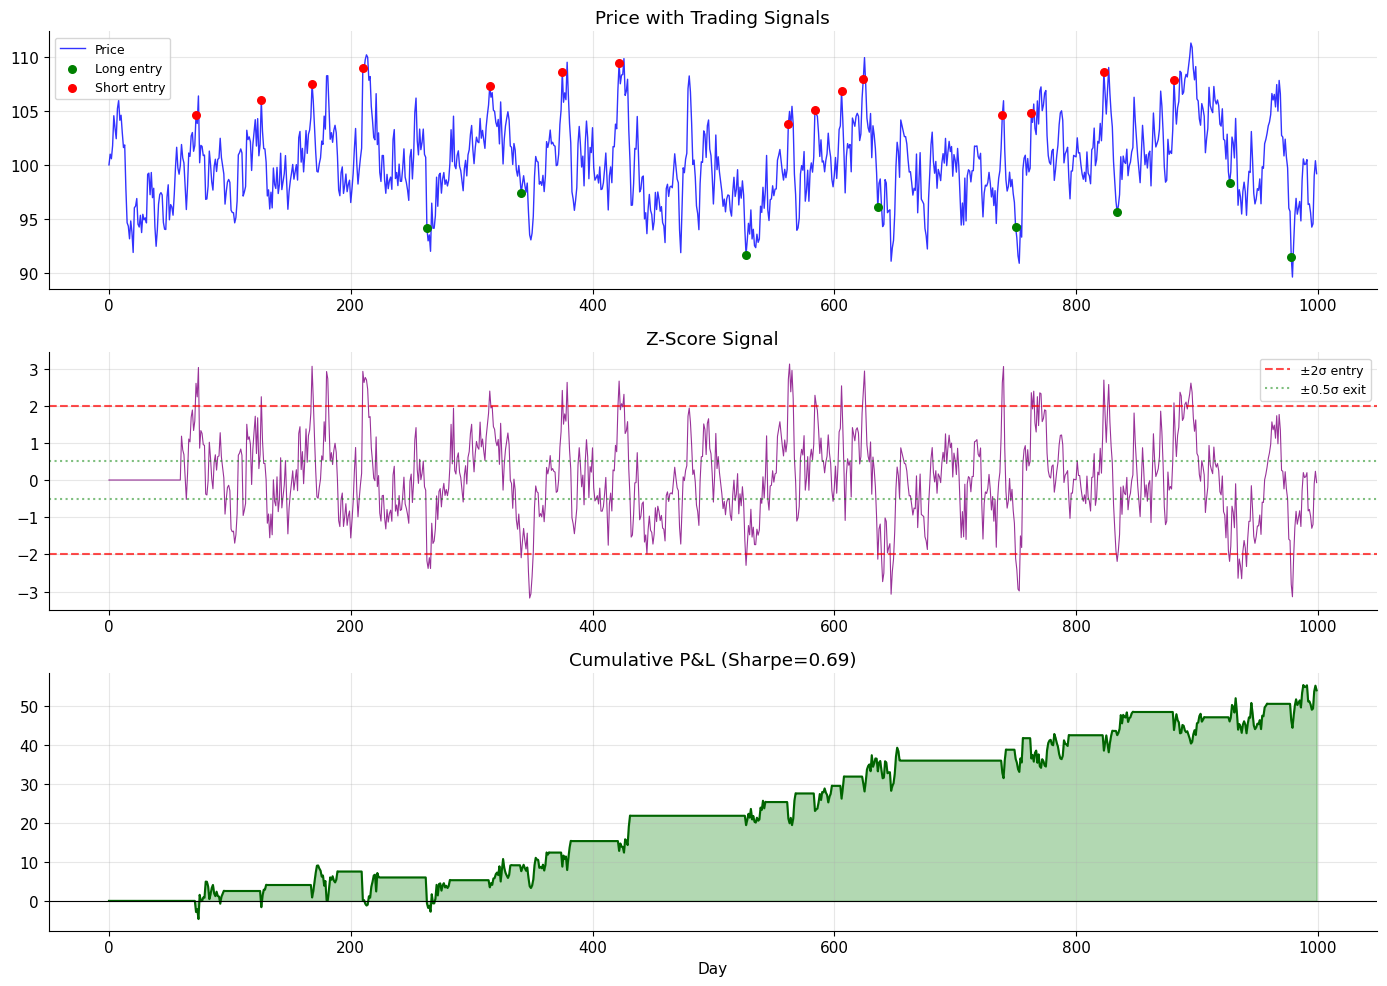

In [62]:
# Full Mean Reversion Backtest
np.random.seed(42)

# Simulate a mean-reverting price series with realistic properties
def generate_mean_reverting_asset(n=500, kappa=0.15, mu=100, sigma=2, S0=100):
    S = np.zeros(n)
    S[0] = S0
    for t in range(1, n):
        dW = np.random.randn()
        S[t] = S[t-1] + kappa*(mu - S[t-1]) + sigma*dW
    return S

# Backtest engine
class MeanReversionBacktest:
    def __init__(self, prices, entry_z=2.0, exit_z=0.5, stop_z=3.5,
                 lookback=60, cost_bps=5):
        self.prices = prices
        self.entry_z = entry_z
        self.exit_z = exit_z
        self.stop_z = stop_z
        self.lookback = lookback
        self.cost = cost_bps / 10000
        
    def run(self):
        n = len(self.prices)
        positions = np.zeros(n)
        pnl = np.zeros(n)
        z_scores = np.zeros(n)
        trades = 0
        
        for t in range(self.lookback, n):
            window = self.prices[t-self.lookback:t]
            mu = np.mean(window)
            sigma = np.std(window)
            if sigma == 0:
                continue
            z = (self.prices[t] - mu) / sigma
            z_scores[t] = z
            
            # Current position
            pos = positions[t-1]
            
            # Entry signals
            if pos == 0:
                if z < -self.entry_z:
                    pos = 1  # long
                    pnl[t] -= self.cost * self.prices[t]
                    trades += 1
                elif z > self.entry_z:
                    pos = -1  # short
                    pnl[t] -= self.cost * self.prices[t]
                    trades += 1
            elif pos == 1:
                if z > self.exit_z or z < -self.stop_z:
                    pnl[t] -= self.cost * self.prices[t]
                    trades += 1
                    pos = 0
            elif pos == -1:
                if z < -self.exit_z or z > self.stop_z:
                    pnl[t] -= self.cost * self.prices[t]
                    trades += 1
                    pos = 0
            
            # Daily P&L from holding
            pnl[t] += pos * (self.prices[t] - self.prices[t-1])
            positions[t] = pos
        
        return positions, pnl, z_scores, trades

# Generate asset and run backtest
prices = generate_mean_reverting_asset(n=1000)
bt = MeanReversionBacktest(prices, entry_z=2.0, exit_z=0.5, lookback=60)
positions, pnl, z_scores, n_trades = bt.run()

cum_pnl = np.cumsum(pnl)
total_pnl = cum_pnl[-1]
daily_ret = pnl[60:] / 100  # normalize by initial price
sharpe = np.mean(daily_ret) / np.std(daily_ret) * np.sqrt(252) if np.std(daily_ret) > 0 else 0

print("=== Mean Reversion Backtest Results ===")
print(f"Total Trades: {n_trades}")
print(f"Total P&L: ${total_pnl:.2f}")
print(f"Annualized Sharpe: {sharpe:.2f}")
print(f"Hit Rate: {(pnl[pnl!=0]>0).mean():.1%}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(prices, 'b-', linewidth=1, alpha=0.8, label='Price')
# Show buy/sell signals
longs = np.where((positions == 1) & (np.roll(positions, 1) != 1))[0]
shorts = np.where((positions == -1) & (np.roll(positions, 1) != -1))[0]
axes[0].scatter(longs, prices[longs], color='green', s=30, zorder=5, label='Long entry')
axes[0].scatter(shorts, prices[shorts], color='red', s=30, zorder=5, label='Short entry')
axes[0].set_title('Price with Trading Signals')
axes[0].legend(fontsize=9)

axes[1].plot(z_scores, color='purple', linewidth=0.8, alpha=0.8)
axes[1].axhline(2, color='red', linestyle='--', alpha=0.7, label='±2σ entry')
axes[1].axhline(-2, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5, label='±0.5σ exit')
axes[1].axhline(-0.5, color='green', linestyle=':', alpha=0.5)
axes[1].set_title('Z-Score Signal')
axes[1].legend(fontsize=9)

axes[2].plot(cum_pnl, 'darkgreen', linewidth=1.5)
axes[2].fill_between(range(len(cum_pnl)), cum_pnl, alpha=0.3, color='green')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title(f'Cumulative P&L (Sharpe={sharpe:.2f})')
axes[2].set_xlabel('Day')
plt.tight_layout()
plt.show()


## Case Study 2: Momentum Strategy

**Interview prompt:** *"Build a momentum strategy from scratch."*

**Strategy:**
1. **Universe:** Top 500 liquid stocks
2. **Signal:** 12-1 month return (skip last month to avoid short-term reversal)
3. **Position:** Long top quintile, short bottom quintile
4. **Rebalance:** Monthly
5. **Risk controls:** Dollar-neutral, sector-neutral

## Case Study 3: Pairs Trading (Full Implementation)

See Section 3 for full statistical foundation. Below is a complete backtest.


=== Momentum Strategy Results ===
Annual Return: -38.03%
Annual Vol: 7.64%
Sharpe Ratio: -4.98
Max Drawdown: -49.42%


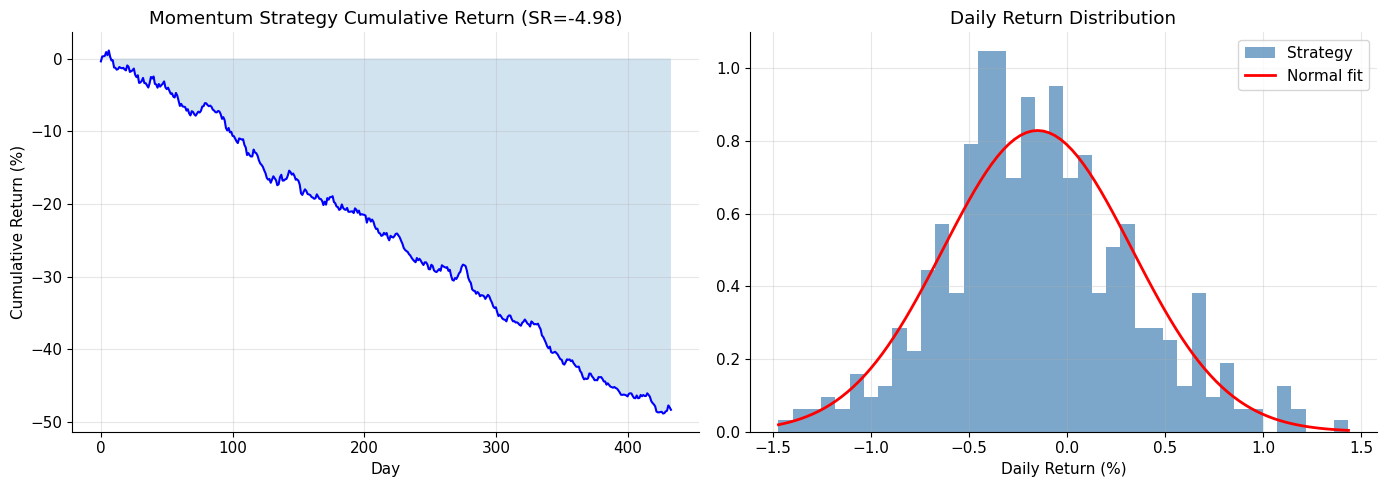

In [63]:
# Momentum Strategy Backtest
np.random.seed(42)

def generate_universe(n_stocks=20, n_days=500):
    '''Simulate stock universe with cross-sectional dispersion'''
    returns = np.random.normal(0.0005, 0.015, (n_days, n_stocks))
    # Add some persistence (momentum)
    for t in range(1, n_days):
        returns[t] = 0.05 * returns[t-1] + 0.95 * returns[t]
    prices = 100 * np.cumprod(1 + returns, axis=0)
    return prices, returns

prices, returns = generate_universe(20, 500)

def momentum_backtest(prices, lookback=60, skip=5, top_n=4, cost_bps=10):
    n_days, n_stocks = prices.shape
    pnl_daily = []
    
    for t in range(lookback + skip, n_days):
        # 12-1 month momentum (simplified to lookback-skip)
        mom_returns = (prices[t-skip] - prices[t-lookback]) / prices[t-lookback]
        
        # Rank and form long/short portfolios
        ranks = np.argsort(mom_returns)
        longs = ranks[-top_n:]
        shorts = ranks[:top_n]
        
        # Equal weight within each side
        if t < n_days - 1:
            long_ret = np.mean(returns[t+1, longs])
            short_ret = np.mean(returns[t+1, shorts])
            cost = cost_bps / 10000  # rebalancing cost
            daily_pnl = (long_ret - short_ret) / 2 - cost
            pnl_daily.append(daily_pnl)
    
    return np.array(pnl_daily)

mom_pnl = momentum_backtest(prices)
cum_mom = np.cumprod(1 + mom_pnl) - 1
sharpe_mom = np.mean(mom_pnl) / np.std(mom_pnl) * np.sqrt(252)
mdd_mom, _ = max_drawdown(mom_pnl)

print("=== Momentum Strategy Results ===")
print(f"Annual Return: {np.mean(mom_pnl)*252:.2%}")
print(f"Annual Vol: {np.std(mom_pnl)*np.sqrt(252):.2%}")
print(f"Sharpe Ratio: {sharpe_mom:.2f}")
print(f"Max Drawdown: {mdd_mom:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cum_mom*100, 'blue', linewidth=1.5)
axes[0].fill_between(range(len(cum_mom)), cum_mom*100, alpha=0.2)
axes[0].set_title(f'Momentum Strategy Cumulative Return (SR={sharpe_mom:.2f})')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Cumulative Return (%)')

# Return distribution
axes[1].hist(mom_pnl*100, bins=40, density=True, alpha=0.7, color='steelblue', label='Strategy')
x_range = np.linspace(mom_pnl.min()*100, mom_pnl.max()*100, 100)
axes[1].plot(x_range, norm.pdf(x_range, np.mean(mom_pnl)*100, np.std(mom_pnl)*100), 
             'r-', linewidth=2, label='Normal fit')
axes[1].set_title('Daily Return Distribution')
axes[1].set_xlabel('Daily Return (%)')
axes[1].legend()
plt.tight_layout()
plt.show()


---
<a id='section12'></a>
# Section 12: Quantitative Brainteasers 🧠

> **Why this matters:** Brainteasers test first-principles thinking, ability to decompose problems, and logical precision under pressure. They reveal how you think, not just what you know.

---

### Puzzle 1 [Classic] — Burning Ropes
**Question:** *"You have two ropes that each take 60 minutes to burn. How do you measure 45 minutes?"*

**Solution:** 
1. Light rope 1 at both ends AND rope 2 at one end simultaneously
2. Rope 1 burns in 30 minutes (both ends burning)
3. When rope 1 finishes, light the other end of rope 2
4. Rope 2 now has 30 minutes left but burns from both ends → takes 15 minutes
5. Total: 30 + 15 = **45 minutes** ✓

---

### Puzzle 2 [Medium] — 100 Doors
**Question:** *"100 doors all closed. 100 people. Person k toggles every kth door. How many doors are open after all 100 people pass?"*

**Key insight:** Door n is open if it's toggled an odd number of times = has odd number of factors = n is a perfect square.

**Answer: 10 doors** (1, 4, 9, 16, 25, 36, 49, 64, 81, 100)

---

### Puzzle 3 [Hard] — Expected Number of Coin Flips for HH
**Question:** *"How many coin flips on average until you get two heads in a row?"*

**Solution via linear equations:**
Let $E$ = expected flips from start, $E_H$ = expected flips after one head

$E = 1 + \frac{1}{2}E_H + \frac{1}{2}E$ (flip once: heads leads to $E_H$, tails back to $E$)

$E_H = 1 + \frac{1}{2}(0) + \frac{1}{2}E$ (heads done! tails back to $E$)

From equation 2: $E_H = 1 + \frac{E}{2}$

Substituting: $E = 1 + \frac{1}{2}(1 + \frac{E}{2}) + \frac{E}{2} = \frac{3}{2} + \frac{3E}{4}$

$\frac{E}{4} = \frac{3}{2} \Rightarrow E = 6$

**Answer: 6 flips**

---

### Puzzle 4 [Hard] — Egg Drop Problem
**Question:** *"You have 2 eggs and a 100-floor building. How do you find the highest safe floor in minimum worst-case trials?"*

**Optimal strategy:** Drop first egg at floors: 14, 27, 39, 50, 60, 69, 77, 84, 90, 95, 99, 100

**Reasoning:** Decrease interval by 1 each time. If first egg breaks at floor $n$, use at most $n-1$ trials with second egg from floor below.

**Worst case:** 14 trials total. If $k$ is first drop: $k + (k-1) + ... + 1 \geq 100 \Rightarrow k(k+1)/2 \geq 100 \Rightarrow k = 14$

---

### Puzzle 5 [Quant] — Expected Maximum of Dice Rolls
**Question:** *"Roll a fair die n times. What is the expected maximum?"*

$E[\max] = \sum_{k=1}^6 k \cdot P(\max = k) = \sum_{k=1}^6 \left[\left(\frac{k}{6}\right)^n - \left(\frac{k-1}{6}\right)^n\right] k$

Or more elegantly: $E[\max_n] = 6 - \sum_{k=1}^5 \left(\frac{k}{6}\right)^n$

---

### Puzzle 6 [Quant] — Airline Overbooking
**Question:** *"An airline sells 105 seats for a 100-seat plane. Each passenger shows up with 95% probability. What is P(overbooked)?"*

$P(X > 100)$ where $X \sim Bin(105, 0.95)$

$P(\text{overbooked}) = 1 - P(X \leq 100) = $ Binomial CDF

---

### Puzzle 7 [Trading] — Gambler's Ruin
**Question:** *"You start with \$50. Each flip: win \$1 with p=0.51, lose \$1 with p=0.49. Bankroll = \$100. What is P(reaching \$100 before going broke)?"*

$P(\text{ruin from }k) = \frac{1 - (q/p)^k}{1 - (q/p)^N}$ where $q/p = 0.49/0.51$

$P(\text{win}) = 1 - P(\text{ruin})$

---

### Puzzle 8–20: Quick Answers
| Puzzle | Answer |
|--------|--------|
| 3 light switches, 1 bulb in next room, 1 trip | Turn on 1 for 5min, off. Turn on another. Go in: if on=switch 2, warm=switch 1, off=switch 3 |
| Expected rolls to get each side of die once? | $6(1 + 1/2 + 1/3 + 1/4 + 1/5 + 1/6) = 14.7$ |
| 10 bags of coins, one bag has 9g coins (rest 10g), 1 weighing | Take 1,2,3...10 from each bag. Deficit tells you which bag |
| St. Petersburg paradox EV? | Infinite, but no one would pay much → utility theory |
| 2 cards face down, at least one is ace. P(both aces)? | 1/3 (not 1/2!) — conditional probability |
| P(3 people all different birthdays)? | $365/365 \times 364/365 \times 363/365 ≈ 99.2\%$ |
| Monty Hall: switch or stay? | **Switch: 2/3 vs 1/3** |


In [64]:
# Brainteaser Simulations
print("=== Puzzle 3: Expected Flips for HH ===")
def simulate_HH(n_sims=100000):
    counts = []
    for _ in range(n_sims):
        flips = 0
        last = None
        while True:
            flip = np.random.randint(0, 2)
            flips += 1
            if flip == 1 and last == 1:
                break
            last = flip
        counts.append(flips)
    return np.mean(counts)

sim_HH = simulate_HH()
print(f"Theoretical E[flips for HH]: 6")
print(f"Simulated: {sim_HH:.3f}")

print("\n=== Puzzle 5: Expected Max of Dice ===")
def expected_max_dice(n_rolls):
    return sum(k * ((k/6)**n_rolls - ((k-1)/6)**n_rolls) for k in range(1, 7))

for n in [1, 2, 3, 5, 10, 20]:
    print(f"E[max of {n:2d} rolls]: {expected_max_dice(n):.4f}")

print("\n=== Puzzle 6: Airline Overbooking ===")
from scipy.stats import binom as binom_dist
n_tickets, n_seats, p_show = 105, 100, 0.95
p_overbook = 1 - binom_dist.cdf(n_seats, n_tickets, p_show)
print(f"P(overbooking) = {p_overbook:.2%}")

print("\n=== Puzzle 7: Gambler's Ruin ===")
k, N, p, q = 50, 100, 0.51, 0.49
ratio = q/p
p_win = (1 - ratio**k) / (1 - ratio**N)
print(f"P(reaching ${N} from ${k}, p={p}) = {p_win:.4%}")

# Monty Hall Simulation
print("\n=== Monty Hall Simulation ===")
n = 100000
stay_wins = 0
switch_wins = 0
for _ in range(n):
    car = np.random.randint(0, 3)
    choice = np.random.randint(0, 3)
    # Monty opens a door (not car, not choice)
    remaining = [d for d in range(3) if d != choice and d != car]
    # Switching = picking the remaining unopened door
    switch_door = [d for d in range(3) if d != choice and d != remaining[0]][0]
    
    if choice == car:
        stay_wins += 1
    if switch_door == car:
        switch_wins += 1

print(f"P(win | stay):   {stay_wins/n:.2%} (theoretical: 33.3%)")
print(f"P(win | switch): {switch_wins/n:.2%} (theoretical: 66.7%)")


=== Puzzle 3: Expected Flips for HH ===
Theoretical E[flips for HH]: 6
Simulated: 5.999

=== Puzzle 5: Expected Max of Dice ===
E[max of  1 rolls]: 3.5000
E[max of  2 rolls]: 4.4722
E[max of  3 rolls]: 4.9583
E[max of  5 rolls]: 5.4309
E[max of 10 rolls]: 5.8202
E[max of 20 rolls]: 5.9736

=== Puzzle 6: Airline Overbooking ===
P(overbooking) = 39.24%

=== Puzzle 7: Gambler's Ruin ===
P(reaching $100 from $50, p=0.51) = 88.0825%

=== Monty Hall Simulation ===
P(win | stay):   33.10% (theoretical: 33.3%)
P(win | switch): 66.90% (theoretical: 66.7%)


---
<a id='section13'></a>
# Section 13: Coding for Quant/Trading Interviews 💻

> **Interview format:** Either live coding in Python or algorithmic design questions. Focus on correctness, efficiency, and clarity. Always discuss time/space complexity.

---

## 13.1 Essential Trading Algorithms


In [65]:
# ===========================
# TRADING CODING CHALLENGES
# ===========================

import pandas as pd
import numpy as np

# ----------------------------
# 1. Rolling Z-Score
# ----------------------------
def rolling_z_score(series, window=20):
    '''Calculate rolling z-score. O(n*window) naive, O(n) with incremental update.'''
    s = pd.Series(series)
    roll_mean = s.rolling(window).mean()
    roll_std = s.rolling(window).std()
    return (s - roll_mean) / roll_std

# Test
prices = np.cumsum(np.random.randn(200)) + 100
z = rolling_z_score(prices)
print(f"Rolling Z-Score (last 5): {z.iloc[-5:].round(3).values}")

# ----------------------------
# 2. Maximum Drawdown (O(n))
# ----------------------------
def max_drawdown_fast(returns):
    '''O(n) maximum drawdown calculation'''
    cum_ret = np.cumprod(1 + np.array(returns))
    peak = cum_ret[0]
    max_dd = 0
    for ret in cum_ret:
        if ret > peak:
            peak = ret
        dd = (ret - peak) / peak
        if dd < max_dd:
            max_dd = dd
    return max_dd

rets = np.random.normal(0.001, 0.02, 500)
print(f"Max Drawdown: {max_drawdown_fast(rets):.2%}")

# ----------------------------
# 3. Sharpe Ratio
# ----------------------------
def sharpe_ratio(returns, risk_free_rate=0.02, periods_per_year=252):
    '''Annualized Sharpe ratio'''
    excess = np.array(returns) - risk_free_rate/periods_per_year
    if np.std(excess) == 0:
        return 0
    return np.mean(excess) / np.std(excess) * np.sqrt(periods_per_year)

print(f"Sharpe Ratio: {sharpe_ratio(rets):.2f}")


Rolling Z-Score (last 5): [-0.082 -0.182 -0.268 -0.991 -1.211]
Max Drawdown: -28.07%
Sharpe Ratio: 1.00


In [66]:
# ----------------------------
# 4. Order Book Implementation
# ----------------------------
import heapq
from collections import defaultdict

class OrderBook:
    '''
    Efficient order book using heaps.
    - Bids: max-heap (negate for Python's min-heap)
    - Asks: min-heap
    Time: O(log n) per order
    '''
    def __init__(self):
        self.bids = []  # max-heap (negated prices)
        self.asks = []  # min-heap
        self.bid_quantities = defaultdict(int)
        self.ask_quantities = defaultdict(int)
        self.order_id = 0
    
    def add_bid(self, price, qty):
        self.bid_quantities[price] += qty
        heapq.heappush(self.bids, -price)
        return self.order_id
    
    def add_ask(self, price, qty):
        self.ask_quantities[price] += qty
        heapq.heappush(self.asks, price)
        return self.order_id
    
    def best_bid(self):
        while self.bids and self.bid_quantities[-self.bids[0]] == 0:
            heapq.heappop(self.bids)
        return -self.bids[0] if self.bids else None
    
    def best_ask(self):
        while self.asks and self.ask_quantities[self.asks[0]] == 0:
            heapq.heappop(self.asks)
        return self.asks[0] if self.asks else None
    
    def spread(self):
        bb, ba = self.best_bid(), self.best_ask()
        return (ba - bb) if bb and ba else None
    
    def execute_market_buy(self, qty):
        '''Execute a market buy order'''
        executed = []
        remaining = qty
        while remaining > 0 and self.asks:
            price = self.best_ask()
            if price is None:
                break
            available = self.ask_quantities[price]
            filled = min(remaining, available)
            executed.append((price, filled))
            self.ask_quantities[price] -= filled
            remaining -= filled
        return executed, remaining

# Test
ob = OrderBook()
for price, qty in [(99.5, 100), (99.0, 200), (98.5, 150)]:
    ob.add_bid(price, qty)
for price, qty in [(100.0, 100), (100.5, 200), (101.0, 150)]:
    ob.add_ask(price, qty)

print("=== Order Book ===")
print(f"Best Bid: {ob.best_bid()}, Best Ask: {ob.best_ask()}")
print(f"Spread: {ob.spread():.2f}")
executed, leftover = ob.execute_market_buy(250)
print(f"Market buy 250: {executed}, unfilled: {leftover}")


=== Order Book ===
Best Bid: 99.5, Best Ask: 100.0
Spread: 0.50
Market buy 250: [(100.0, 100), (100.5, 150)], unfilled: 0


In [67]:
# ----------------------------
# 5. Cointegration Tester
# ----------------------------
from statsmodels.tsa.stattools import coint

def cointegration_test(series1, series2, significance=0.05):
    '''
    Engle-Granger cointegration test.
    Returns: test stat, p-value, hedge ratio, is_cointegrated
    '''
    # Test cointegration
    score, pvalue, critical_values = coint(series1, series2)
    
    # Estimate hedge ratio via OLS
    X = np.column_stack([series2, np.ones(len(series2))])
    beta = np.linalg.lstsq(X, series1, rcond=None)[0]
    hedge_ratio = beta[0]
    
    return {
        'test_stat': score,
        'p_value': pvalue,
        'hedge_ratio': hedge_ratio,
        'is_cointegrated': pvalue < significance,
        'spread': series1 - hedge_ratio * series2
    }

# Generate cointegrated pair
n = 500
common = np.cumsum(np.random.randn(n))
s1 = common + np.random.randn(n) * 0.5
s2 = 1.5 * common + np.random.randn(n) * 0.5

result = cointegration_test(s1, s2)
print("=== Cointegration Test ===")
for k, v in result.items():
    if k != 'spread':
        print(f"{k}: {v}")

# ----------------------------
# 6. PnL Attribution Engine
# ----------------------------
def pnl_attribution(positions, prices, risk_free_rate=0.0, costs_bps=10):
    '''
    Calculate detailed PnL attribution.
    positions: dict of {date: {asset: qty}}
    prices: DataFrame
    '''
    pnl = {'gross': 0, 'transaction_costs': 0, 'net': 0}
    prev_pos = {}
    
    for date in sorted(positions.keys()):
        curr_pos = positions[date]
        
        # Transaction costs
        for asset, qty in curr_pos.items():
            prev_qty = prev_pos.get(asset, 0)
            turnover = abs(qty - prev_qty) * prices.get(asset, 100)
            pnl['transaction_costs'] += turnover * costs_bps / 10000
        
        prev_pos = curr_pos
    
    return pnl

# ----------------------------
# 7. Rolling Correlation Matrix
# ----------------------------
def rolling_correlation(returns_df, window=60):
    '''
    Rolling correlation matrix. O(n * k^2) for k assets.
    '''
    n, k = returns_df.shape
    correlations = []
    
    for i in range(window, n):
        window_data = returns_df.iloc[i-window:i]
        corr_matrix = window_data.corr()
        correlations.append(corr_matrix)
    
    return correlations

# Test with random returns
np.random.seed(42)
ret_df = pd.DataFrame(np.random.randn(200, 5), 
                       columns=[f'Asset_{i}' for i in range(5)])
corrs = rolling_correlation(ret_df)
print(f"\nRolling Correlation: {len(corrs)} matrices computed")
print(f"Last correlation matrix:")
print(corrs[-1].round(3))


=== Cointegration Test ===
test_stat: -23.342366269959665
p_value: 0.0
hedge_ratio: 0.6689491965483241
is_cointegrated: True

Rolling Correlation: 140 matrices computed
Last correlation matrix:
         Asset_0  Asset_1  Asset_2  Asset_3  Asset_4
Asset_0    1.000    0.105    0.153    0.067   -0.043
Asset_1    0.105    1.000    0.001   -0.063   -0.104
Asset_2    0.153    0.001    1.000    0.008    0.165
Asset_3    0.067   -0.063    0.008    1.000    0.018
Asset_4   -0.043   -0.104    0.165    0.018    1.000


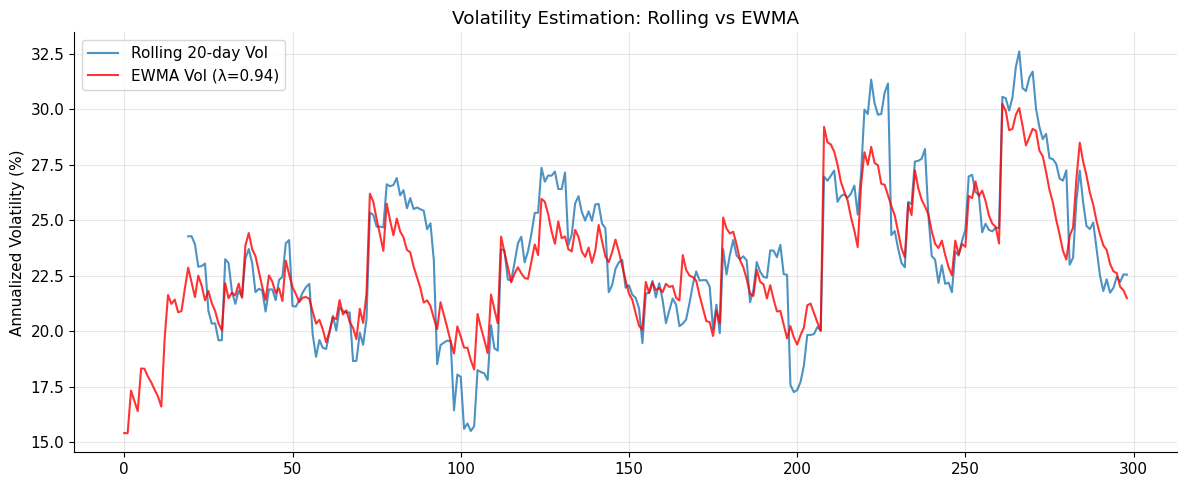

In [68]:
# ----------------------------
# 8. Volatility Calculator (Multiple Methods)
# ----------------------------
def calculate_volatility(prices, method='close_to_close', window=20, annualize=True):
    '''
    Multiple volatility estimation methods.
    '''
    prices = np.array(prices)
    
    if method == 'close_to_close':
        log_returns = np.log(prices[1:]/prices[:-1])
        vol = pd.Series(log_returns).rolling(window).std()
    
    elif method == 'parkinson':
        # Requires high/low - simulated here
        # vol = sqrt(1/(4*ln(2)) * (ln(H/L))^2)
        vol = None  # placeholder
    
    elif method == 'yang_zhang':
        # Most efficient estimator
        # Requires O, H, L, C
        vol = None
    
    if annualize and vol is not None:
        vol = vol * np.sqrt(252)
    
    return vol

# EWMA Volatility (used by RiskMetrics)
def ewma_volatility(returns, lam=0.94, initial_vol=0.01):
    '''
    Exponentially weighted moving average volatility.
    σ²_t = λ*σ²_{t-1} + (1-λ)*r²_{t-1}
    '''
    vols = [initial_vol**2]
    for r in returns:
        var = lam * vols[-1] + (1-lam) * r**2
        vols.append(var)
    return np.sqrt(np.array(vols[1:]))

np.random.seed(42)
prices_vol = 100 * np.cumprod(1 + np.random.normal(0, 0.015, 300))
returns_vol = np.diff(np.log(prices_vol))

cc_vol = calculate_volatility(prices_vol)
ewma_vol = ewma_volatility(returns_vol)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cc_vol*100, label='Rolling 20-day Vol', alpha=0.8)
ax.plot(ewma_vol*np.sqrt(252)*100, label='EWMA Vol (λ=0.94)', alpha=0.8, color='red')
ax.set_title('Volatility Estimation: Rolling vs EWMA')
ax.set_ylabel('Annualized Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()


---
<a id='section14'></a>
# Section 14: Full Mock Interview 🎯

> **How to use:** Practice delivering each answer out loud within 60-90 seconds. Record yourself. Review for clarity, confidence, and completeness.

---

## Part A: Trader Interview (50 Questions)

### Mental Math / Probability [First 15 minutes of interview]

**Q1.** What is 7% of 350?
> **Answer:** 7% of 350 = 7 × 3.5 = **24.5**. Mental math: 10% = 35, divide by 10 = 3.5, multiply by 7.

**Q2.** A stock is at $47. It rises 8%, then falls 5%. What is the final price?
> **Answer:** $47 × 1.08 × 0.95 = $47 × 1.026 = **$48.22**. Mental: $47 × 1.08 = $50.76; $50.76 × 0.95 ≈ $48.22.

**Q3.** Roll two dice. What is P(sum = 7)?
> **Answer:** 6 ways out of 36 = **1/6 ≈ 16.7%**. (1+6, 2+5, 3+4, 4+3, 5+2, 6+1)

**Q4.** You have 60% win rate on 1:1 bets. What is Kelly fraction?
> **Answer:** $f^* = p - q = 0.6 - 0.4 = **20%**

**Q5.** Stock A has 30% annual vol. What is daily vol?
> **Answer:** $30\% / \sqrt{252} \approx 30/15.87 ≈ **1.89%** (often rounded as 1.875%).

**Q6.** Expected value: roll a die, win that number in dollars, costs $4 to play. Play?
> **Answer:** EV = 3.5. Cost = $4. **Don't play** (EV < cost).

**Q7.** A fair coin: if it comes up heads 10 times in a row, what is probability next flip is heads?
> **Answer:** **50%** — coin flips are independent. Common mistake: gambler's fallacy.

**Q8.** P(drawing a face card or a heart from a standard deck)?
> $P(face) + P(heart) - P(face ∩ heart) = 12/52 + 13/52 - 3/52 = 22/52 = **11/26 ≈ 42.3%**

**Q9.** Your strategy has daily Sharpe of 0.05. Annualized Sharpe?
> **Answer:** $0.05 \times \sqrt{252} = 0.05 \times 15.87 ≈ **0.79**

**Q10.** Compound $10,000 at 6% for 12 years. Final value?
> **Answer:** Rule of 72: doubles every 12 years. $10,000 × 2 = **$20,000** (exact: $20,122).

**Q11.** What is 15% of $840?
> **Answer:** 10% of 840 = 84, 5% = 42 → **$126**.

**Q12.** A position loses 25%. How much does it need to gain to break even?
> **Answer:** $100 / $75 = **33.33%** gain needed.

**Q13.** Calculate 22 × 38 mentally.
> **Answer:** 20×38 = 760, 2×38 = 76 → **836**.

**Q14.** You win $300 with 55% probability, lose $200 with 45%. What is EV?
> **Answer:** (0.55 × 300) + (0.45 × -200) = 165 - 90 = **+$75**.

**Q15.** Annual return 24%. What is the approximate monthly return?
> **Answer:** (1.24)^(1/12) ≈ **1.82%** per month.

**Q16.** What is 17.5% of 640?
> **Answer:** 10% = 64, 5% = 32, 2.5% = 16 → **112**.

**Q17.** A stock drops 20% then rises 25%. What is the net return?
> **Answer:** 0.8 × 1.25 = **1.00** → **0%** net return.

**Q18.** Probability of getting heads three times in a row with a fair coin?
> **Answer:** (1/2)³ = **1/8 = 12.5%**.

**Q19.** $250,000 account, risk 1.5% per trade. What is the max dollar risk?
> **Answer:** 1.5% of 250k = **$3,750**.

**Q20.** Daily vol is 1.2%. Approximate annual vol?
> **Answer:** 1.2% × √252 ≈ 1.2 × 15.87 ≈ **19.04%**.

**Q21.** What is 4.5 × 280?
> **Answer:** 4 × 280 = 1,120, 0.5 × 280 = 140 → **1,260**.

**Q22.** You have a 65% win rate on 1:2 risk-reward bets. Is the strategy +EV?
> **Answer:** Expectancy = (0.65 × 2) - (0.35 × 1) = 1.3 - 0.35 = **+0.95R** (Yes, strongly +EV).

**Q23.** 35% of 720?
> **Answer:** 30% = 216, 5% = 36 → **252**.

**Q24.** A portfolio grows 15% in year 1 and falls 10% in year 2. Net return?
> **Answer:** 1.15 × 0.9 = **1.035 → +3.5%**.

**Q25.** Approximate √252 (used for annualizing volatility).
> **Answer:** √256 = 16, so √252 ≈ **15.87**.

**Q26.** EV of a game: 40% chance win $500, 60% chance lose $300.
> **Answer:** (0.4 × 500) + (0.6 × -300) = 200 - 180 = **+$20**.

**Q27.** What is 2.25% of $180,000?
> **Answer:** 2% = 3,600, 0.25% = 450 → **$4,050**.

**Q28.** If a coin lands heads 5 times, what is the probability of tails on 6th flip?
> **Answer:** Still **50%** (independence).

**Q29.** 48 × 52 mentally.
> **Answer:** 50×52 = 2,600 minus 2×52 = 104 → **2,496**.

**Q30.** Annual Sharpe 1.2. What is approximate daily Sharpe?
> **Answer:** 1.2 / √252 ≈ 1.2 / 15.87 ≈ **0.076**.

**Q31.** $1,200 grows at 8% compounded annually for 5 years. Rough final value?
> **Answer:** Rule of 72 (doubles ~every 9 years). Approx **$1,760**.

**Q32.** Probability of drawing an ace or a spade from a deck?
> **Answer:** (4 + 13 - 1)/52 = 16/52 = **4/13 ≈ 30.77%**.

**Q33.** A trade risks $1 to make $1.80 with 48% win rate. Is it +EV?
> **Answer:** (0.48 × 1.8) - (0.52 × 1) = 0.864 - 0.52 = **+0.344R** (Yes).

**Q34.** What is 9.5% of 1,600?
> **Answer:** 10% = 160, minus 0.5% (8) → **152**.

**Q35.** Daily return 0.3%. Approximate annualized return (252 days)?
> **Answer:** 0.3 × 252 = **75.6%**.

**Q36.** Two dice sum to 8. How many ways?
> **Answer:** 5 ways (2+6, 3+5, 4+4, 5+3, 6+2) → **5/36**.

**Q37.** Convert 18% annual vol to weekly vol.
> **Answer:** 18% / √52 ≈ 18 / 7.21 ≈ **2.5%**.

**Q38.** 125 × 96 mentally.
> **Answer:** 125 × 100 = 12,500 minus 125 × 4 = 500 → **12,000**.

**Q39.** 65% win rate, 1:1 payoff. Kelly fraction?
> **Answer:** 0.65 - 0.35 = **30%**.

**Q40.** A stock at $80 rises 12.5%. New price?
> **Answer:** 12.5% of 80 = 10 → **$90**.

**Q41.** What is the expected number of coin flips to get first heads?
> **Answer:** Geometric distribution → **2**.

**Q42.** $450,000 at 2% risk with 1.5% stop distance. Max position size?
> **Answer:** Risk $9,000 / 0.015 = **$600,000**.

**Q43.** 7.5 × 44?
> **Answer:** 7×44=308, 0.5×44=22 → **330**.

**Q44.** P(at least one 6 in two dice rolls)?
> **Answer:** 1 - (5/6)² = 1 - 25/36 = **11/36 ≈ 30.6%**.

**Q45.** Approximate 1.08^10 (compound growth).
> **Answer:** Rule of 72: 8% doubles in 9 years → roughly **2.16** (actual ~2.16).

**Q46.** Win $150 (60%), lose $100 (40%). EV?
> **Answer:** 90 - 40 = **+$50**.

**Q47.** What is 22.5% of 1,200?
> **Answer:** 20%=240, 2.5%=30 → **270**.

**Q48.** Annual vol 25%. 10-day vol?
> **Answer:** 25% × √10 / √252 ≈ 25 × 0.199 ≈ **4.98%**.

**Q49.** 19 × 85 mentally.
> **Answer:** 20×85=1,700 minus 85 = **1,615**.

**Q50.** You have a strategy with 52% win rate and 1:1.2 reward-risk. Expectancy per trade?
> **Answer:** (0.52×1.2) - (0.48×1) = 0.624 - 0.48 = **+0.144R** (positive).


### Trading Judgment Questions [Core interview block]

**Q11.** *"Walk me through a trade you would put on right now."*
> **Framework:** (1) Macro thesis, (2) Specific instrument, (3) Entry trigger, (4) Position size, (5) Exit criteria, (6) Risk controls. Be specific — pick a real trade you've researched.

**Q12.** *"Two stocks, 80% correlated. One drops 20%, the other hasn't moved. What do you do?"*
> **Answer:** First: determine if correlation is causal or coincidental. Is the move stock-specific or sector-wide? If the drop is fundamental (earnings miss), the other stock may not follow. If it's a sector catalyst, the other stock is likely to reprice. **Never just assume mean reversion without checking fundamentals.**

**Q13.** *"How would you value a company with negative earnings?"*
> **Answer:** Use forward multiples (EV/Revenue, EV/Gross Profit), DCF on path to profitability, comparable transactions, or option-value frameworks for early-stage companies.

**Q14.** *"What is the VIX and what does a spike in VIX tell you?"*
> **Answer:** VIX is the 30-day implied volatility of S&P 500 options, derived from a strip of options. A spike signals market fear, increased uncertainty, demand for protection. **Trading implication:** Vol spikes mean-revert — selling volatility after spikes (on a 30+ day horizon) is historically profitable, but be aware of gamma risk during the spike itself.

**Q15.** *"Rate hikes are coming. How does this affect different asset classes?"*
> **Framework:** Bonds (prices fall, duration risk), Equities (valuation compression, especially growth stocks), Currencies (dollar typically strengthens), Commodities (mixed — inflation fighters vs growth impact), Real Estate (cap rate expansion → price pressure).

---

## Part B: Quant Interview (50 Questions)

**Q1.** *"Derive the Black-Scholes formula from the replicating portfolio argument."*
> **Key steps:** Set up delta-hedged portfolio → apply Ito's lemma → eliminate stochastic term → get risk-free PDE → boundary conditions → solve to get the formula.

**Q2.** *"What is the difference between physical and risk-neutral measure?"*
> **Answer:** Physical measure $\mathbb{P}$: actual probability; risk-neutral measure $\mathbb{Q}$: adjusted probabilities where all assets earn the risk-free rate. Under $\mathbb{Q}$: $dS = rS\,dt + \sigma S\,dW^Q$. Used because it simplifies option pricing to discounted expectations.

**Q3.** *"Explain Jensen's Inequality and give a trading example."*
> **Answer:** For convex $f$: $E[f(X)] \geq f(E[X])$. **Options example:** $E[\max(S_T-K, 0)] \geq \max(E[S_T]-K, 0)$ — this is why options have time value beyond intrinsic value. Also: $E[e^X] \geq e^{E[X]}$ explains why geometric mean < arithmetic mean.

**Q4.** *"What is Ito's Lemma?"*
> **Answer:** For $f(S,t)$ where $dS = \mu\,dt + \sigma\,dW$:
> $$df = rac{\partial f}{\partial t}dt + rac{\partial f}{\partial S}dS + rac{1}{2}rac{\partial^2 f}{\partial S^2}(dS)^2$$
> The extra term $rac{1}{2}\sigma^2rac{\partial^2 f}{\partial S^2}dt$ comes from $(dW)^2 = dt$ — the correction that generates the Black-Scholes PDE.

**Q5.** *"A stock has μ=10%, σ=20%. What is E[S_T] and the median?"*
> $E[S_T] = S_0 e^{\mu T}$ (arithmetic expectation)
> Median $= S_0 e^{(\mu - \sigma^2/2)T}$ (geometric mean)
> **Difference:** $e^{\mu T}$ vs $e^{(\mu-0.02)T}$ — **median < mean** due to positive skewness of lognormal.


## Part C: Prop Trader Questions (50 Questions)

**Q1.** *"What is your edge? How do you size a trade?"*
> **Framework:** Edge = statistical advantage + informational advantage + structural advantage. Size = f(edge / variance) × risk_budget. Kelly gives optimal but use half-Kelly in practice.

**Q2.** *"How do you respond to a losing streak?"*
> **Answer:** (1) First determine if losses are within expected statistical range or if the strategy has broken down. (2) Reduce position size proportionally to drawdown — protect capital. (3) Don't "revenge trade." (4) Review if market regime has changed. (5) Have a pre-defined drawdown limit (e.g., cut positions 50% at 10% drawdown, stop at 15%).

**Q3.** *"Describe your ideal trading day."*
> **Answer:** Pre-market: review overnight developments, update priors. At open: scan for mispricings vs model. During day: manage existing book, look for new setups. Close: review PnL, document what worked and why, update model. Key: **disciplined process, not chasing performance**.

**Q4.** *"If you had $1M to invest for 1 year with no constraints, what would you do?"*
> **Framework:** Demonstrate (1) asset allocation thinking, (2) risk management, (3) market view, (4) sizing rationale. Never put it all in one thing — show diversification and correlation awareness.

**Q5.** *"What's the difference between a risk arbitrage trade and a stat arb trade?"*
> **Risk arb (merger arb):** Exploit merger spread, binary outcome dependent on deal closing. Known catalyst and timeline. **Stat arb:** Exploit statistical mispricing with no specific catalyst, relies on mean reversion. Risk arb has specific catalyst risk; stat arb has regime change risk.


---
<a id='section15'></a>
# Section 15: Master Formula Sheet 📋

---

## Probability

| Formula | Description |
|---------|-------------|
| $P(A \cap B) = P(A)P(B)$ | Independence |
| $P(A \| B) = P(A \cap B)/P(B)$ | Conditional probability |
| $P(B \| A) = P(A\|B)P(B)/P(A)$ | Bayes' theorem |
| $E[X] = \sum x_i p_i$ | Expectation |
| $Var(X) = E[X^2] - (E[X])^2$ | Variance |
| $f^* = (bp-q)/b$ | Kelly criterion |
| $n(n+1)/2 \geq N$ | Egg drop: first drop |

---

## Statistics

| Formula | Description |
|---------|-------------|
| $\sigma_{annual} = \sigma_{daily} \sqrt{252}$ | Vol scaling |
| $SR = (R_p - R_f)/\sigma_p$ | Sharpe ratio |
| $IR = IC \sqrt{N}$ | Information ratio |
| $t = SR_{monthly} \sqrt{T}$ | SR t-stat |
| $Cov(X,Y) = E[(X-\mu_X)(Y-\mu_Y)]$ | Covariance |
| $\rho = Cov/\sigma_X\sigma_Y$ | Correlation |
| $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i-\bar{x})^2$ | MLE variance |
| VPIN $= |V_B - V_S|/V$ | Toxicity measure |

---

## Fixed Income

| Formula | Description |
|---------|-------------|
| $P = \sum \frac{C}{(1+y)^t} + \frac{F}{(1+y)^n}$ | Bond price |
| $D_{mac} = \sum t \cdot PV(CF_t)/P$ | Macaulay duration |
| $D_{mod} = D_{mac}/(1+y/m)$ | Modified duration |
| $\Delta P/P \approx -D_{mod} \Delta y$ | Price sensitivity |
| $C = \frac{1}{P}\sum \frac{t(t+1)CF_t}{(1+y)^{t+2}}$ | Convexity |
| $DV01 = P \cdot D_{mod} \cdot 0.0001$ | Dollar value of bp |
| $f_{T_1,T_2} = [(1+s_2)^{T_2}/(1+s_1)^{T_1}]^{1/(T_2-T_1)} - 1$ | Forward rate |

---

## Forwards & Futures

| Formula | Description |
|---------|-------------|
| $F_0 = S_0 e^{rT}$ | Forward price (no div) |
| $F_0 = S_0 e^{(r-q)T}$ | Forward with dividend yield |
| $F_0 = S_0 e^{(r+u-y)T}$ | Commodity forward |
| Basis $= F - S$ | Futures basis |

---

## Options & Greeks

| Formula | Description |
|---------|-------------|
| $C = S\Phi(d_1) - Ke^{-rT}\Phi(d_2)$ | BS call price |
| $d_1 = \frac{\ln(S/K) + (r+\sigma^2/2)T}{\sigma\sqrt{T}}$ | d1 |
| $d_2 = d_1 - \sigma\sqrt{T}$ | d2 |
| $C - P = S - Ke^{-rT}$ | Put-call parity |
| $\Delta_{call} = \Phi(d_1)$ | Call delta |
| $\Gamma = \phi(d_1)/(S\sigma\sqrt{T})$ | Gamma |
| $\mathcal{V} = S\phi(d_1)\sqrt{T}$ | Vega |
| $\Theta \approx -\frac{1}{2}\sigma^2 S^2 \Gamma$ | Theta-Gamma |

---

## Risk Management

| Formula | Description |
|---------|-------------|
| $VaR_{\alpha} = \mu + z_{\alpha}\sigma$ | Parametric VaR |
| $ES = \mu + \sigma \frac{\phi(z_{\alpha})}{1-\alpha}$ | Expected Shortfall (normal) |
| $MDD = \max(W_{max} - W_t)/W_{max}$ | Max drawdown |
| Calmar $= R_{annual}/MDD$ | Risk-adjusted return |
| $f^* = \Sigma^{-1}\mu$ | Multi-asset Kelly |
| $\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$ | Portfolio variance |
| $SR_p \leq \sqrt{\sum SR_i^2}$ | Sharpe bound (uncorrelated) |

---

## Statistical Arbitrage

| Formula | Description |
|---------|-------------|
| $z_t = (S_t - \mu_S)/\sigma_S$ | Z-score |
| $t_{1/2} = \ln(2)/\kappa$ | Mean reversion half-life |
| $dS = \kappa(\mu-S)dt + \sigma dW$ | OU process |
| $H < 0.5$ | Mean reverting (Hurst) |
| $H = 0.5$ | Random walk (Hurst) |
| $H > 0.5$ | Trending (Hurst) |

---

## Market Microstructure

| Formula | Description |
|---------|-------------|
| Spread $= 2 \times (\text{adv sel} + \text{inventory} + \text{ops})$ | Spread components |
| $\Delta P \approx \sigma \sqrt{Q/V_{daily}}$ | Square root market impact |
| VPIN $= |V_B - V_S|/V_{total}$ | Order flow toxicity |
| Kyle's $\lambda$: $\Delta P = \lambda Q$ | Price impact (linear) |

---

## Useful Approximations

| Approximation | When to use |
|--------------|-------------|
| $\ln(1+x) \approx x$ | Small $x$ |
| $\sqrt{252} \approx 16$ | Vol annualization |
| $\sqrt{12} \approx 3.46$ | Monthly to annual |
| Rule of 72: years $\approx 72/r\%$ | Doubling time |
| $(1+x)^n \approx 1 + nx$ | Small $x$, any $n$ |
| ATM straddle $\approx 0.8 S \sigma \sqrt{T}$ | Quick option pricing |
| $N(1.645) = 95\%$, $N(2.326) = 99\%$ | Normal quantiles |


In [70]:
# Final Summary: Performance Metrics Calculator
def strategy_scorecard(returns, risk_free=0.02, periods=252, name="Strategy"):
    '''
    Comprehensive strategy performance scorecard.
    '''
    r = np.array(returns)
    ann_ret = np.mean(r) * periods
    ann_vol = np.std(r) * np.sqrt(periods)
    sharpe = (ann_ret - risk_free) / ann_vol if ann_vol > 0 else 0
    
    mdd, dd = max_drawdown(r)
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.inf
    
    sorted_r = np.sort(r)
    var_95 = -sorted_r[int(0.05*len(r))]
    es_95 = -np.mean(sorted_r[:int(0.05*len(r))])
    
    skewness = float(pd.Series(r).skew())
    kurtosis = float(pd.Series(r).kurtosis())
    win_rate = float(np.mean(r > 0))
    avg_win = float(np.mean(r[r > 0])) if any(r > 0) else 0
    avg_loss = float(np.mean(r[r < 0])) if any(r < 0) else 0
    profit_factor = float(-avg_win / avg_loss) if avg_loss != 0 else np.inf
    
    print(f"{'='*50}")
    print(f"  {name} — Performance Scorecard")
    print(f"{'='*50}")
    print(f"  Annual Return:     {ann_ret:>8.2%}")
    print(f"  Annual Volatility: {ann_vol:>8.2%}")
    print(f"  Sharpe Ratio:      {sharpe:>8.2f}")
    print(f"  Max Drawdown:      {mdd:>8.2%}")
    print(f"  Calmar Ratio:      {calmar:>8.2f}")
    print(f"  VaR (95%):         {var_95:>8.2%}")
    print(f"  ES (95%):          {es_95:>8.2%}")
    print(f"  Skewness:          {skewness:>8.2f}")
    print(f"  Excess Kurtosis:   {kurtosis:>8.2f}")
    print(f"  Win Rate:          {win_rate:>8.1%}")
    print(f"  Profit Factor:     {profit_factor:>8.2f}")
    print(f"{'='*50}")
    
    return {
        'annual_return': ann_ret, 'annual_vol': ann_vol,
        'sharpe': sharpe, 'max_drawdown': mdd, 'calmar': calmar,
        'var_95': var_95, 'es_95': es_95
    }

# Run on our strategies
np.random.seed(42)
strategy_a = np.random.normal(0.001, 0.01, 500)
strategy_b = np.concatenate([np.random.normal(0.002, 0.015, 400),
                               np.random.normal(-0.001, 0.025, 100)])

scorecard_a = strategy_scorecard(strategy_a, name="Mean Reversion Strategy")
scorecard_b = strategy_scorecard(strategy_b, name="Momentum Strategy")

print("\n✅ NOTEBOOK COMPLETE — Good luck with your interviews!")
print("\nKey reminders:")
print("  1. Show your thinking process, not just the answer")
print("  2. Always check: does this make intuitive sense?") 
print("  3. Acknowledge uncertainty and estimation error")
print("  4. Know your formulas cold — practice mental math daily")
print("  5. Have 2-3 real trade ideas ready with full analysis")


  Mean Reversion Strategy — Performance Scorecard
  Annual Return:       26.92%
  Annual Volatility:   15.56%
  Sharpe Ratio:          1.60
  Max Drawdown:       -11.64%
  Calmar Ratio:          2.31
  VaR (95%):            1.42%
  ES (95%):             1.81%
  Skewness:              0.18
  Excess Kurtosis:       0.27
  Win Rate:             54.4%
  Profit Factor:         1.10
  Momentum Strategy — Performance Scorecard
  Annual Return:       48.71%
  Annual Volatility:   27.05%
  Sharpe Ratio:          1.73
  Max Drawdown:       -26.27%
  Calmar Ratio:          1.85
  VaR (95%):            2.56%
  ES (95%):             3.61%
  Skewness:             -0.14
  Excess Kurtosis:       0.64
  Win Rate:             54.6%
  Profit Factor:         1.11

✅ NOTEBOOK COMPLETE — Good luck with your interviews!

Key reminders:
  1. Show your thinking process, not just the answer
  2. Always check: does this make intuitive sense?
  3. Acknowledge uncertainty and estimation error
  4. Know your formul